---
# Section 1: Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_ind, ttest_rel, ttest_1samp
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

df = pd.read_csv('experiment_results_v3_export.csv')

print(f"Original N: {len(df)}")
print(f"Total missing values: {df.isnull().sum().sum()}")

df_clean = df.dropna()

print(f"N after removing missing: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} subjects")

df_clean.to_csv('experiment_results_v3_clean.csv', index=False)

Original N: 151
Total missing values: 0
N after removing missing: 151
Removed: 0 subjects


---
# Section 2: Subject Filtering (Quality Control)

ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)

Original Subject Count: 151

--------------------------------------------------------------------------------
FILTER 1: Zig-Zag Inconsistency
--------------------------------------------------------------------------------

Zig-Zag Threshold: 2.0
Subjects with zig-zag score >= 2.0: 4
Subject IDs: ['576311d7151e5d000889e2e7', '5d542c3a5af5900019bc80c4', '667987c18f34110073ae20b7', '69306d791138d98b65f1ba40']
  576311d7151e5d000889e2e7: Zig-Zag Score = 2.000
  5d542c3a5af5900019bc80c4: Zig-Zag Score = 2.000
  667987c18f34110073ae20b7: Zig-Zag Score = 2.000
  69306d791138d98b65f1ba40: Zig-Zag Score = 2.000

--------------------------------------------------------------------------------
FILTER 2: Always Chose Feather Gamble
--------------------------------------------------------------------------------
  69136dffc23976053d4a4166: ALWAYS chose Feather gamble (8/8 trials)
  59d141f5e241c700013a9bb0: ALWAYS chose Feather gamble (8/8 trials)


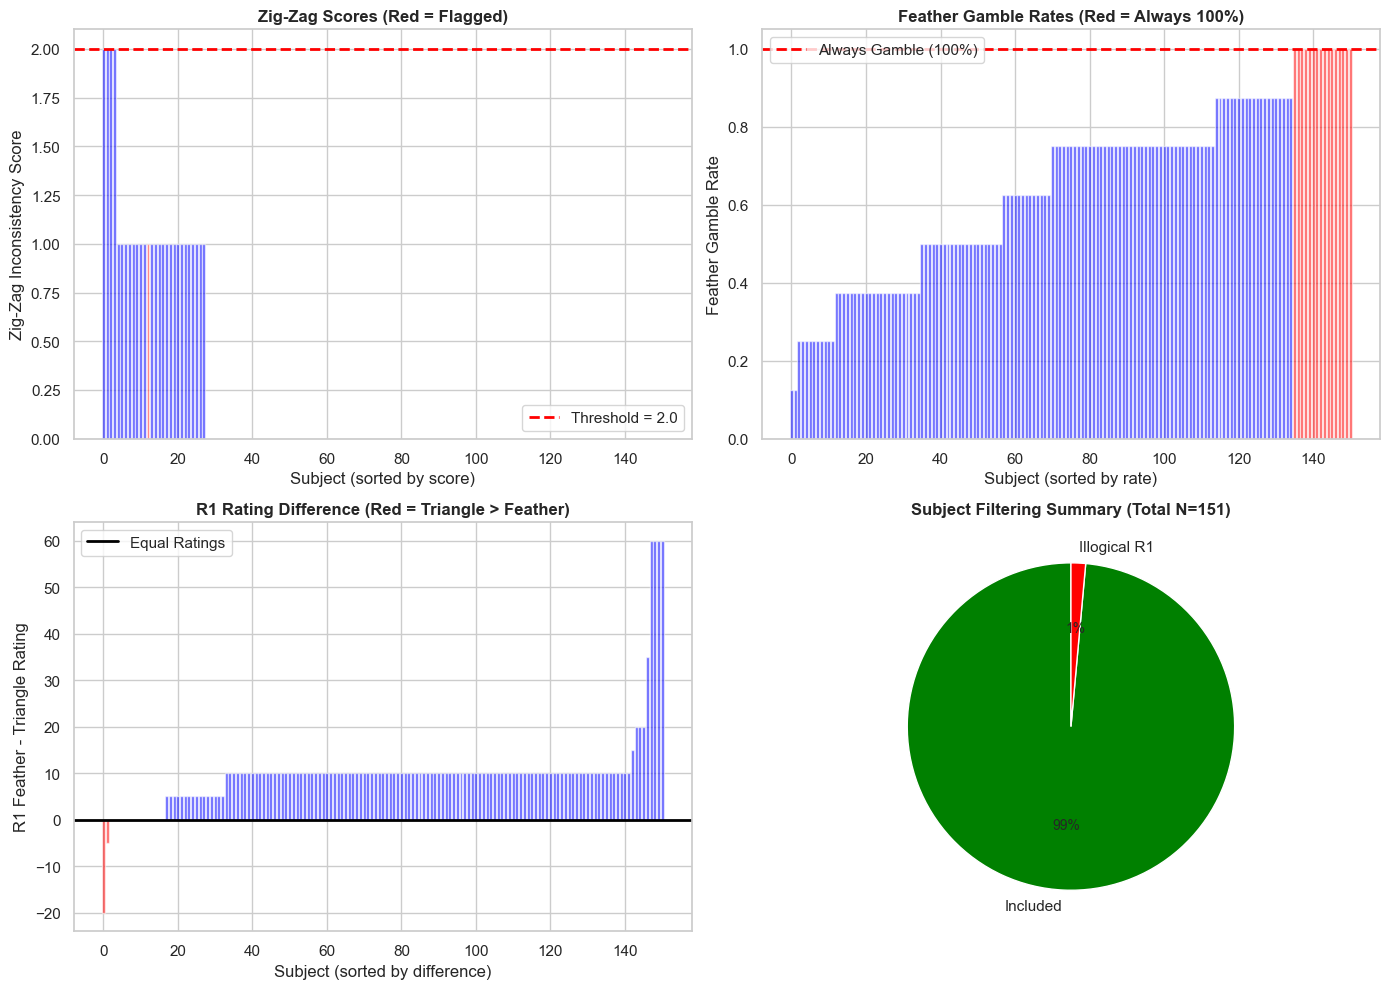


FILTERING COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)")
print("="*80)

df = pd.read_csv('experiment_results_v3_clean.csv')
df['subject_id'] = df['prolific_id']

print(f"\nOriginal Subject Count: {len(df)}")

# ============================================================================
# FILTER 1: ZIG-ZAG INCONSISTENCY
# ============================================================================
print("\n" + "-"*80)
print("FILTER 1: Zig-Zag Inconsistency")
print("-"*80)

long_data = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    for q_num in [1, 2]:
        for t in range(1, 21):
            prefix = f"Query_{q_num}_T{t}"
            state_col = f"{prefix}_State"
            offer_col = f"{prefix}_FixedOffer"
            choice_col = f"{prefix}_Choice"
            
            if state_col not in row or pd.isna(row[state_col]): 
                continue
            
            chose_fixed = 1 if row[choice_col] == 0 else 0
            
            long_data.append({
                'subject_id': subj_id,
                'Query': f"Query {q_num}",
                'State': row[state_col],
                'FixedOffer': row[offer_col],
                'Choice': row[choice_col],
                'ChoseFixed': chose_fixed
            })

df_long = pd.DataFrame(long_data)

def calculate_inconsistency(subject_df):
    total_violation = 0
    for _, group in subject_df.groupby(['Query', 'State']):
        curve = group.groupby('FixedOffer')['ChoseFixed'].mean().sort_index()
        probs = curve.values
        for i in range(len(probs) - 1):
            if probs[i] > probs[i+1]:
                total_violation += (probs[i] - probs[i+1])
    return total_violation

zigzag_scores = df_long.groupby('subject_id', group_keys=False).apply(calculate_inconsistency)

zigzag_threshold = 2.0
zigzag_bad_subjects = zigzag_scores[zigzag_scores >= zigzag_threshold].index.tolist()

print(f"\nZig-Zag Threshold: {zigzag_threshold}")
print(f"Subjects with zig-zag score >= {zigzag_threshold}: {len(zigzag_bad_subjects)}")
if len(zigzag_bad_subjects) > 0:
    print(f"Subject IDs: {zigzag_bad_subjects}")
    for subj in zigzag_bad_subjects:
        print(f"  {subj}: Zig-Zag Score = {zigzag_scores[subj]:.3f}")

# ============================================================================
# FILTER 2: ALWAYS CHOSE FEATHER (GAMBLE)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 2: Always Chose Feather Gamble")
print("-"*80)

always_feather_subjects = []
for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    feather_trials = subj_data[subj_data['State'] == 'Feather']
    
    if len(feather_trials) > 0:
        all_chose_gamble = (feather_trials['Choice'] == 1).all()
        if all_chose_gamble:
            always_feather_subjects.append(subj_id)
            n_feather = len(feather_trials)
            print(f"  {subj_id}: ALWAYS chose Feather gamble ({n_feather}/{n_feather} trials)")

print(f"\nSubjects who always chose Feather gamble: {len(always_feather_subjects)}")

# ============================================================================
# FILTER 3: ALWAYS AVOIDED TRIANGLE (GAMBLE)
# ============================================================================
always_avoid_triangle_subjects = []
for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    triangle_trials = subj_data[subj_data['State'] == 'Triangle']
    
    if len(triangle_trials) > 0:
        never_chose_gamble = (triangle_trials['Choice'] == 0).all()
        if never_chose_gamble:
            always_avoid_triangle_subjects.append(subj_id)
            n_triangle = len(triangle_trials)
            print(f"  {subj_id}: ALWAYS avoided Triangle gamble ({n_triangle}/{n_triangle} trials took offer)")

# ============================================================================
# FILTER 4: ILLOGICAL R1 RATINGS (TRIANGLE > FEATHER POST-MF)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 4: Illogical R1 Ratings (Triangle > Feather)")
print("-"*80)

print("\nLogic: After MF learning, Feather should be valued HIGHER than Triangle")
print("  - Feather → positive outcomes (should be rated high)")
print("  - Triangle → negative outcomes (should be rated low)")
print("  - Expected: Rating_1_Feather > Rating_1_Triangle")
print("  - Illogical: Rating_1_Triangle > Rating_1_Feather")

illogical_r1_subjects = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    r1_feather = row['Rating_1_Feather_Val']
    r1_triangle = row['Rating_1_Triangle_Val']
    
    if r1_triangle > r1_feather:
        illogical_r1_subjects.append(subj_id)
        print(f"  {subj_id}: R1 Triangle ({r1_triangle}) > R1 Feather ({r1_feather}) - ILLOGICAL")

print(f"\nSubjects with illogical R1 ratings: {len(illogical_r1_subjects)}")

# ============================================================================
# COMBINED FILTERING
# ============================================================================
print("\n" + "="*80)
print("COMBINED FILTERING RESULTS")
print("="*80)

all_bad_subjects = list(set(
    zigzag_bad_subjects +  
    illogical_r1_subjects
))

print(f"\nTotal subjects to remove: {len(all_bad_subjects)}")
print("\nBreakdown:")
print(f"  Zig-zag inconsistent: {len(zigzag_bad_subjects)}")
print(f"  Always chose Feather: {len(always_feather_subjects)}")
print(f"  Always avoided Triangle: {len(always_avoid_triangle_subjects)}")
print(f"  Illogical R1 ratings: {len(illogical_r1_subjects)}")

zigzag_set = set(zigzag_bad_subjects)
feather_set = set(always_feather_subjects)
triangle_set = set(always_avoid_triangle_subjects)
illogical_set = set(illogical_r1_subjects)

df_filtered = df[~df['subject_id'].isin(all_bad_subjects)].copy()

# Knowledge check filter
if 'Knowledge_Check_Accuracy' in df_filtered.columns:
    n_before = len(df_filtered)
    df_filtered = df_filtered[df_filtered['Knowledge_Check_Accuracy'] > 0.25]
    print(f"\nKnowledge check filter: removed {n_before - len(df_filtered)} additional subjects")

print(f"\n" + "="*80)
print(f"FINAL RESULTS:")
print(f"  Original N: {len(df)}")
print(f"  Removed: {len(df) - len(df_filtered)}")
print(f"  Final N: {len(df_filtered)}")
print(f"  Retention rate: {len(df_filtered)/len(df)*100:.1f}%")
print("="*80)

# Save
df_filtered.to_csv('filtered_data.csv', index=False)

# ============================================================================
# VISUALIZATION
# ============================================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Zig-zag scores
ax = axes[0, 0]
zigzag_df = pd.DataFrame({
    'subject_id': zigzag_scores.index,
    'zigzag_score': zigzag_scores.values,
    'excluded': [s in zigzag_bad_subjects for s in zigzag_scores.index]
})
colors = ['red' if exc else 'blue' for exc in zigzag_df['excluded']]
ax.bar(range(len(zigzag_df)), zigzag_df['zigzag_score'].sort_values(ascending=False), color=colors, alpha=0.6)
ax.axhline(zigzag_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {zigzag_threshold}')
ax.set_xlabel('Subject (sorted by score)')
ax.set_ylabel('Zig-Zag Inconsistency Score')
ax.set_title('Zig-Zag Scores (Red = Flagged)', fontweight='bold')
ax.legend()

# Panel B: Feather gamble rates
ax = axes[0, 1]
feather_rates = []
for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    feather_data = subj_data[subj_data['State'] == 'Feather']
    if len(feather_data) > 0:
        feather_rates.append({'subject_id': subj_id, 'rate': feather_data['Choice'].mean()})

feather_rates_df = pd.DataFrame(feather_rates).sort_values('rate')
colors = ['red' if s in always_feather_subjects else 'blue' for s in feather_rates_df['subject_id']]
ax.bar(range(len(feather_rates_df)), feather_rates_df['rate'], color=colors, alpha=0.6)
ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Always Gamble (100%)')
ax.set_xlabel('Subject (sorted by rate)')
ax.set_ylabel('Feather Gamble Rate')
ax.set_title('Feather Gamble Rates (Red = Always 100%)', fontweight='bold')
ax.set_ylim([0, 1.05])
ax.legend()

# Panel C: R1 rating difference
ax = axes[1, 0]
r1_diff = df['Rating_1_Feather_Val'] - df['Rating_1_Triangle_Val']
r1_diff_sorted = r1_diff.sort_values()
colors = ['red' if diff < 0 else 'blue' for diff in r1_diff_sorted]
ax.bar(range(len(r1_diff_sorted)), r1_diff_sorted, color=colors, alpha=0.6)
ax.axhline(0.0, color='black', linestyle='-', linewidth=2, label='Equal Ratings')
ax.set_xlabel('Subject (sorted by difference)')
ax.set_ylabel('R1 Feather - Triangle Rating')
ax.set_title('R1 Rating Difference (Red = Triangle > Feather)', fontweight='bold')
ax.legend()

# Panel D: Summary
ax = axes[1, 1]
exclusion_counts = {
    'Included': len(df_filtered),
    'Illogical R1': len(illogical_r1_subjects)
}
colors_pie = ['green', 'red']
ax.pie(exclusion_counts.values(), labels=exclusion_counts.keys(), autopct='%1.0f%%',
       colors=colors_pie, startangle=90)
ax.set_title(f'Subject Filtering Summary (Total N={len(df)})', fontweight='bold')

plt.tight_layout()
plt.savefig('subject_filtering_visualization.png', dpi=150)
print("\nSaved: subject_filtering_visualization.png")
plt.show()

print("\nFILTERING COMPLETE!")

---
# Section 3: Calculate Survey Scores (Anxiety/Worry & ERQ)

In [3]:
df = pd.read_csv('filtered_data.csv')
print(f"Sample size: {len(df)}")

df['subject_id'] = df['prolific_id']
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']

cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)

df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Worry' if x >= df['Anxiety_Total'].median() else 'Low Worry')
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High ERQ-R' if x >= df['ERQ_Reappraisal'].median() else 'Low ERQ-R')

print("\n" + "="*80)
print("INDIVIDUAL DIFFERENCES SUMMARY")
print("="*80)

print(f"\nAnxiety/Worry:")
print(f"  M = {df['Anxiety_Total'].mean():.2f}, SD = {df['Anxiety_Total'].std():.2f}")
print(f"  Median: {df['Anxiety_Total'].median():.0f}")
print(f"  Low Worry: n = {sum(df['Anxiety_Group']=='Low Worry')}")
print(f"  High Worry: n = {sum(df['Anxiety_Group']=='High Worry')}")

print(f"\nERQ Cognitive Reappraisal:")
print(f"  M = {df['ERQ_Reappraisal'].mean():.2f}, SD = {df['ERQ_Reappraisal'].std():.2f}")
print(f"  Median: {df['ERQ_Reappraisal'].median():.0f}")
print(f"  Low ERQ-R: n = {sum(df['ERQ_Reappraisal_Group']=='Low ERQ-R')}")
print(f"  High ERQ-R: n = {sum(df['ERQ_Reappraisal_Group']=='High ERQ-R')}")

print("\n" + "="*80)
print("HYPOTHESIS: ERQ-Reappraisal ~ Worry Correlation")
print("="*80)
r_erq_worry, p_erq_worry = pearsonr(df['ERQ_Reappraisal'], df['Anxiety_Total'])
sig = '***' if p_erq_worry < 0.001 else '**' if p_erq_worry < 0.01 else '*' if p_erq_worry < 0.05 else ''
print(f"\nERQ-Reappraisal × Worry: r = {r_erq_worry:.3f}, p = {p_erq_worry:.4f} {sig}")

df.to_csv('filtered_data.csv', index=False)

Sample size: 137

INDIVIDUAL DIFFERENCES SUMMARY

Anxiety/Worry:
  M = 16.71, SD = 7.62
  Median: 14
  Low Worry: n = 62
  High Worry: n = 75

ERQ Cognitive Reappraisal:
  M = 30.53, SD = 6.30
  Median: 31
  Low ERQ-R: n = 67
  High ERQ-R: n = 70

HYPOTHESIS: ERQ-Reappraisal ~ Worry Correlation

ERQ-Reappraisal × Worry: r = -0.172, p = 0.0449 *


---
# Section 4: General Accuracy Analysis

GENERAL ACCURACY ANALYSIS

Expected Values:
  Query 1: Feather EV = -15, Triangle EV = 15
  Query 2: Feather EV = 0, Triangle EV = 10

DESCRIPTIVE STATISTICS

Condition                      EV           N      Mean       SD         SEM        Min      Max     
----------------------------------------------------------------------------------------------------
Q1 Feather (pos→neg)           EV=-15       137    62.41      28.94      2.47       25.00    100.00  
Q1 Triangle (neg→pos)          EV=15        137    68.61      25.73      2.20       25.00    100.00  
Q2 Feather                     EV=0         137    84.85      18.78      1.60       25.00    100.00  
Q2 Triangle                    EV=10        137    76.64      22.27      1.90       33.33    100.00  
Query 1 Overall                Combined     137    65.51      24.47      2.09       25.00    100.00  
Query 2 Overall                Combined     137    80.75      13.11      1.12       41.67    100.00  
Feather Overall (Q1+Q2)   

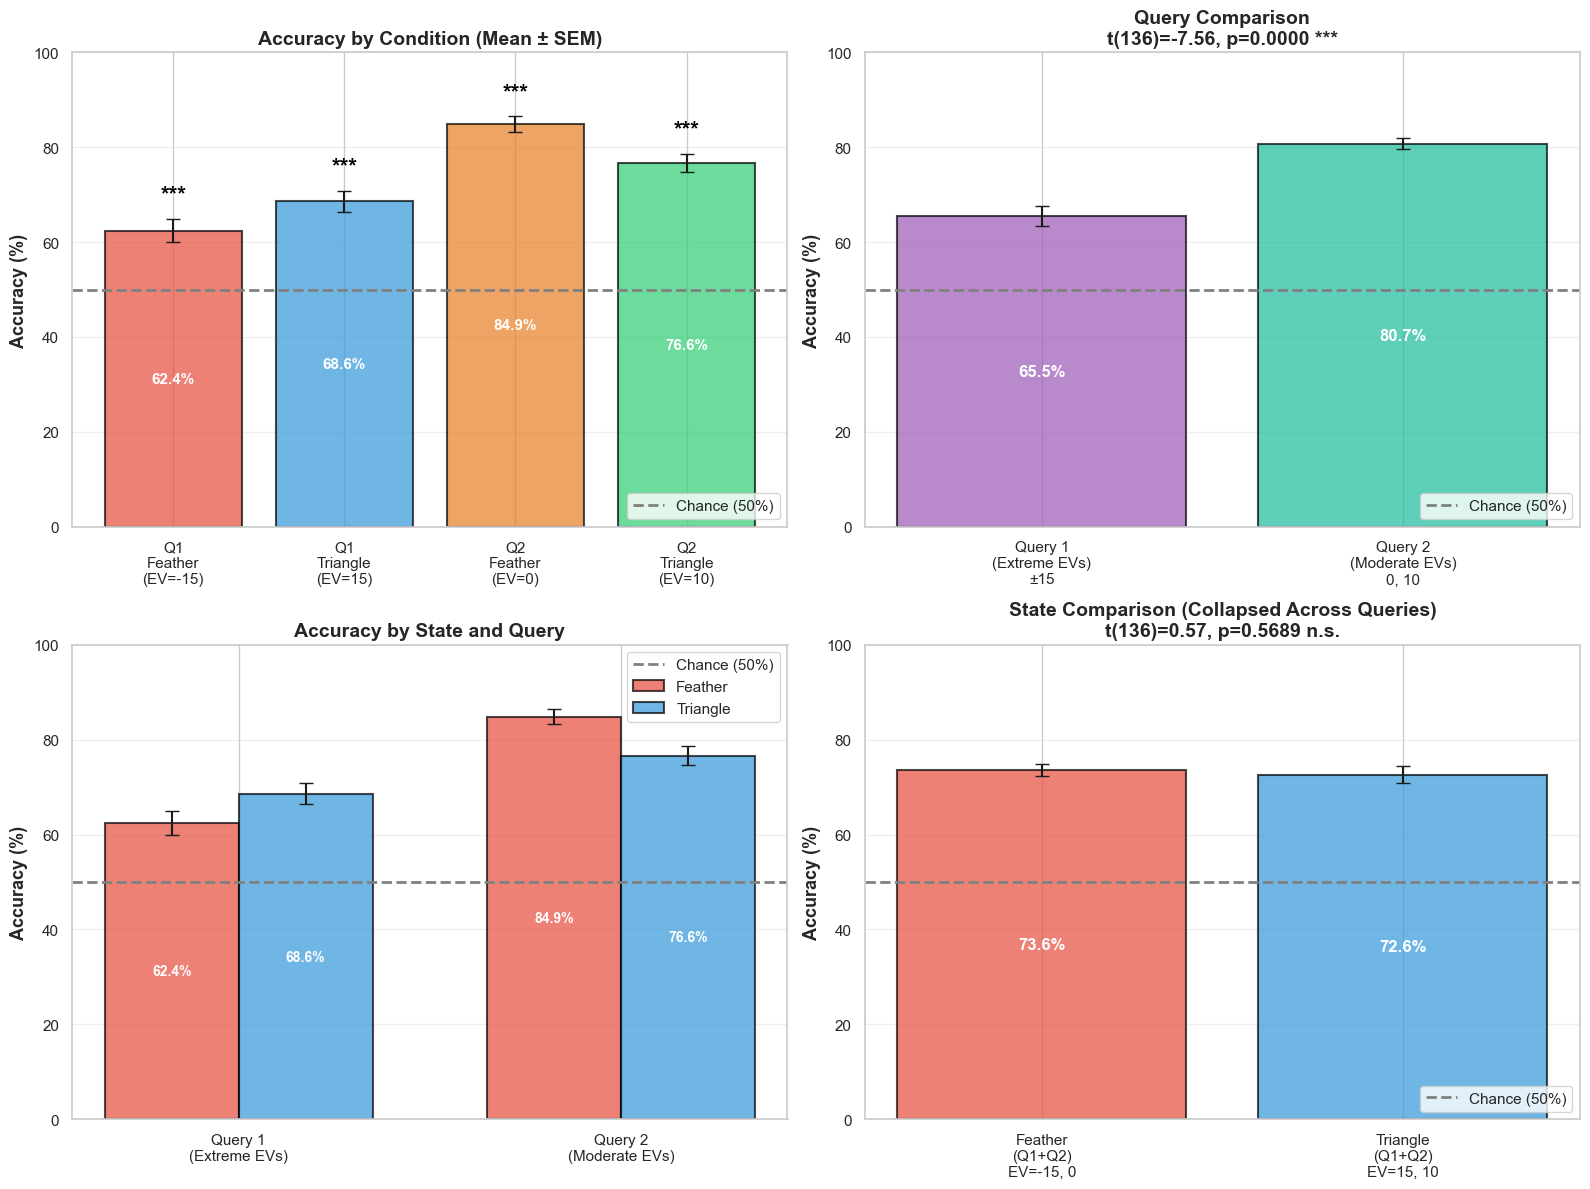

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp, ttest_rel
from scipy import stats

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

print("="*80)
print("GENERAL ACCURACY ANALYSIS")
print("="*80)

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

print("\nExpected Values:")
print(f"  Query 1: Feather EV = {q1_ev_map['Feather']}, Triangle EV = {q1_ev_map['Triangle']}")
print(f"  Query 2: Feather EV = {q2_ev_map['Feather']}, Triangle EV = {q2_ev_map['Triangle']}")

def calculate_state_accuracy(row, query_num, state_name, ev_map):
    optimal_choices = 0
    total_trials = 0
    for trial in range(1, 21):
        state_col = f'Query_{query_num}_T{trial}_State'
        offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
        choice_col = f'Query_{query_num}_T{trial}_Choice'

        if state_col not in row.index or pd.isna(row[state_col]):
            break
        if row[state_col] != state_name:
            continue
        offer = row[offer_col]
        choice = row[choice_col]
        if pd.isna(choice):
            continue
        state_ev = ev_map.get(state_name, 0)

        # ★★★ ADD THESE 4 LINES ★★★
        # CRITICAL: Skip ties where gamble EV = fixed offer
        # No optimal choice when EVs are equal
        if state_ev == offer:
            continue  # Don't count this trial
        # ★★★ END ★★★

        optimal_choice = 1 if state_ev > offer else 0
        if choice == optimal_choice:
            optimal_choices += 1
        total_trials += 1
    return (optimal_choices / total_trials * 100) if total_trials > 0 else np.nan

# Calculate accuracies
for idx, row in df.iterrows():
    df.loc[idx, 'Q1_Feather_Acc'] = calculate_state_accuracy(row, 1, 'Feather', q1_ev_map)
    df.loc[idx, 'Q1_Triangle_Acc'] = calculate_state_accuracy(row, 1, 'Triangle', q1_ev_map)
    df.loc[idx, 'Q2_Feather_Acc'] = calculate_state_accuracy(row, 2, 'Feather', q2_ev_map)
    df.loc[idx, 'Q2_Triangle_Acc'] = calculate_state_accuracy(row, 2, 'Triangle', q2_ev_map)
    df.loc[idx, 'Q1_Accuracy'] = (df.loc[idx, 'Q1_Feather_Acc'] + df.loc[idx, 'Q1_Triangle_Acc']) / 2
    df.loc[idx, 'Q2_Accuracy'] = (df.loc[idx, 'Q2_Feather_Acc'] + df.loc[idx, 'Q2_Triangle_Acc']) / 2
    # Combined state accuracy across queries
    df.loc[idx, 'Feather_Overall_Acc'] = (df.loc[idx, 'Q1_Feather_Acc'] + df.loc[idx, 'Q2_Feather_Acc']) / 2
    df.loc[idx, 'Triangle_Overall_Acc'] = (df.loc[idx, 'Q1_Triangle_Acc'] + df.loc[idx, 'Q2_Triangle_Acc']) / 2

# ============================================================================
# DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

accuracy_vars = [
    ('Q1_Feather_Acc', 'Q1 Feather (pos→neg)', 'EV=-15'),
    ('Q1_Triangle_Acc', 'Q1 Triangle (neg→pos)', 'EV=15'),
    ('Q2_Feather_Acc', 'Q2 Feather', 'EV=0'),
    ('Q2_Triangle_Acc', 'Q2 Triangle', 'EV=10'),
    ('Q1_Accuracy', 'Query 1 Overall', 'Combined'),
    ('Q2_Accuracy', 'Query 2 Overall', 'Combined'),
    ('Feather_Overall_Acc', 'Feather Overall (Q1+Q2)', 'EV=-15,0'),
    ('Triangle_Overall_Acc', 'Triangle Overall (Q1+Q2)', 'EV=15,10')
]

print(f"\n{'Condition':<30} {'EV':<12} {'N':<6} {'Mean':<10} {'SD':<10} {'SEM':<10} {'Min':<8} {'Max':<8}")
print("-"*100)

for var, label, ev_info in accuracy_vars:
    data = df[var].dropna()
    print(f"{label:<30} {ev_info:<12} {len(data):<6} {data.mean():<10.2f} {data.std():<10.2f} {stats.sem(data):<10.2f} {data.min():<8.2f} {data.max():<8.2f}")

# ============================================================================
# ONE-SAMPLE T-TESTS (vs Chance = 50%)
# ============================================================================
print("\n" + "="*80)
print("ONE-SAMPLE T-TESTS (Test Value = 50% Chance)")
print("="*80)

test_results = {}
print(f"\n{'Condition':<30} {'Mean ± SEM':<20} {'t':<10} {'df':<6} {'p-value':<12} {'Sig':<5} {'Cohen\'s d':<10}")
print("-"*100)

for var, label, ev_info in accuracy_vars[:4]:  # Just the 4 main conditions
    data = df[var].dropna()
    t, p = ttest_1samp(data, 50)
    sem = stats.sem(data)
    cohens_d = (data.mean() - 50) / data.std()
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    test_results[var] = {
        'mean': data.mean(), 
        'sem': sem, 
        't': t, 
        'p': p, 
        'sig': sig, 
        'label': label,
        'cohens_d': cohens_d,
        'n': len(data)
    }
    print(f"{label:<30} {data.mean():.2f} ± {sem:.2f}%{'':<8} {t:<10.3f} {len(data)-1:<6} {p:<12.6f} {sig:<5} {cohens_d:<10.3f}")

# Test overall Feather and Triangle
print("\n--- Overall State Performance (Collapsed Across Queries) ---")
for var, label, ev_info in [('Feather_Overall_Acc', 'Feather Overall (Q1+Q2)', 'EV=-15,0'),
                             ('Triangle_Overall_Acc', 'Triangle Overall (Q1+Q2)', 'EV=15,10')]:
    data = df[var].dropna()
    t, p = ttest_1samp(data, 50)
    sem = stats.sem(data)
    cohens_d = (data.mean() - 50) / data.std()
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    test_results[var] = {
        'mean': data.mean(), 
        'sem': sem, 
        't': t, 
        'p': p, 
        'sig': sig, 
        'label': label,
        'cohens_d': cohens_d,
        'n': len(data)
    }
    print(f"{label:<30} {data.mean():.2f} ± {sem:.2f}%{'':<8} {t:<10.3f} {len(data)-1:<6} {p:<12.6f} {sig:<5} {cohens_d:<10.3f}")

# ============================================================================
# PAIRED T-TESTS (Comparisons)
# ============================================================================
print("\n" + "="*80)
print("PAIRED T-TESTS (Within-Subject Comparisons)")
print("="*80)

comparisons = [
    ('Q1_Accuracy', 'Q2_Accuracy', 'Query 1 vs Query 2'),
    ('Q1_Feather_Acc', 'Q1_Triangle_Acc', 'Q1: Feather vs Triangle'),
    ('Q2_Feather_Acc', 'Q2_Triangle_Acc', 'Q2: Feather vs Triangle'),
    ('Q1_Feather_Acc', 'Q2_Feather_Acc', 'Feather: Q1 vs Q2'),
    ('Q1_Triangle_Acc', 'Q2_Triangle_Acc', 'Triangle: Q1 vs Q2'),
    ('Feather_Overall_Acc', 'Triangle_Overall_Acc', 'OVERALL: Feather vs Triangle')
]

print(f"\n{'Comparison':<35} {'Mean Diff':<12} {'t':<10} {'df':<6} {'p-value':<12} {'Sig':<5} {'Cohen\'s d':<10}")
print("-"*100)

for var1, var2, label in comparisons:
    data1 = df[var1].dropna()
    data2 = df[var2].dropna()

    # Match subjects
    valid_idx = df[[var1, var2]].dropna().index
    data1_matched = df.loc[valid_idx, var1]
    data2_matched = df.loc[valid_idx, var2]

    t, p = ttest_rel(data1_matched, data2_matched)
    mean_diff = data1_matched.mean() - data2_matched.mean()
    diff = data1_matched - data2_matched
    cohens_d = diff.mean() / diff.std()
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

    print(f"{label:<35} {mean_diff:<12.3f} {t:<10.3f} {len(data1_matched)-1:<6} {p:<12.6f} {sig:<5} {cohens_d:<10.3f}")

# ============================================================================
# SUMMARY INSIGHTS
# ============================================================================
print("\n" + "="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

print("\n1. PERFORMANCE ABOVE CHANCE:")
above_chance = [label for var, label, _ in accuracy_vars[:4] if test_results[var]['p'] < 0.05 and test_results[var]['mean'] > 50]
print(f"   - {len(above_chance)}/4 conditions significantly above 50% chance")
for var, label, _ in accuracy_vars[:4]:
    if test_results[var]['p'] < 0.05 and test_results[var]['mean'] > 50:
        print(f"     ✓ {label}: {test_results[var]['mean']:.2f}% (p={test_results[var]['p']:.4f})")

print("\n2. BEST vs WORST PERFORMANCE:")
best_var = max([(var, label, test_results[var]['mean']) for var, label, _ in accuracy_vars[:4]], key=lambda x: x[2])
worst_var = min([(var, label, test_results[var]['mean']) for var, label, _ in accuracy_vars[:4]], key=lambda x: x[2])
print(f"   - Best:  {best_var[1]} = {best_var[2]:.2f}%")
print(f"   - Worst: {worst_var[1]} = {worst_var[2]:.2f}%")

print("\n3. QUERY COMPARISON:")
q1_mean = df['Q1_Accuracy'].mean()
q2_mean = df['Q2_Accuracy'].mean()
if q1_mean > q2_mean:
    print(f"   - Query 1 (extreme EVs) showed higher accuracy ({q1_mean:.2f}% vs {q2_mean:.2f}%)")
else:
    print(f"   - Query 2 (moderate EVs) showed higher accuracy ({q2_mean:.2f}% vs {q1_mean:.2f}%)")

print("\n4. STATE COMPARISON (OVERALL):")
feather_mean = df['Feather_Overall_Acc'].mean()
triangle_mean = df['Triangle_Overall_Acc'].mean()
if feather_mean > triangle_mean:
    print(f"   - Feather showed higher accuracy overall ({feather_mean:.2f}% vs {triangle_mean:.2f}%)")
else:
    print(f"   - Triangle showed higher accuracy overall ({triangle_mean:.2f}% vs {feather_mean:.2f}%)")

# ============================================================================
# VISUALIZATIONS (4 panels)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel A: Accuracy by state and query
ax = axes[0, 0]
conditions = ['Q1_Feather_Acc', 'Q1_Triangle_Acc', 'Q2_Feather_Acc', 'Q2_Triangle_Acc']
labels = ['Q1\nFeather\n(EV=-15)', 'Q1\nTriangle\n(EV=15)', 'Q2\nFeather\n(EV=0)', 'Q2\nTriangle\n(EV=10)']
means = [df[c].mean() for c in conditions]
sems = [stats.sem(df[c].dropna()) for c in conditions]
colors = ['#e74c3c', '#3498db', '#e67e22', '#2ecc71']

bars = ax.bar(labels, means, yerr=sems, capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(50, color='gray', linestyle='--', linewidth=2, label='Chance (50%)')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Accuracy by Condition (Mean ± SEM)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])

# Add significance markers
for i, (bar, var) in enumerate(zip(bars, conditions)):
    sig = test_results[var]['sig']
    if sig and sig != 'n.s.':
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sems[i] + 3, 
                sig, ha='center', va='bottom', fontsize=16, fontweight='bold', color='black')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{means[i]:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Panel B: Query comparison
ax = axes[0, 1]
q1_mean, q1_sem = df['Q1_Accuracy'].mean(), stats.sem(df['Q1_Accuracy'].dropna())
q2_mean, q2_sem = df['Q2_Accuracy'].mean(), stats.sem(df['Q2_Accuracy'].dropna())

t_q, p_q = stats.ttest_rel(df['Q1_Accuracy'].dropna(), df['Q2_Accuracy'].dropna())
sig_q = '***' if p_q < 0.001 else '**' if p_q < 0.01 else '*' if p_q < 0.05 else 'n.s.'

bars = ax.bar(['Query 1\n(Extreme EVs)\n±15', 'Query 2\n(Moderate EVs)\n0, 10'], [q1_mean, q2_mean], 
              yerr=[q1_sem, q2_sem], capsize=5, color=['#9b59b6', '#1abc9c'], alpha=0.7, 
              edgecolor='black', linewidth=1.5)
ax.axhline(50, color='gray', linestyle='--', linewidth=2, label='Chance (50%)')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title(f'Query Comparison\nt({len(df["Q1_Accuracy"].dropna())-1})={t_q:.2f}, p={p_q:.4f} {sig_q}', 
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])

for bar, mean in zip(bars, [q1_mean, q2_mean]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{mean:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Panel C: State comparison within each query
ax = axes[1, 0]
x = np.arange(2)
width = 0.35

feather_means = [df['Q1_Feather_Acc'].mean(), df['Q2_Feather_Acc'].mean()]
feather_sems = [stats.sem(df['Q1_Feather_Acc'].dropna()), stats.sem(df['Q2_Feather_Acc'].dropna())]
triangle_means = [df['Q1_Triangle_Acc'].mean(), df['Q2_Triangle_Acc'].mean()]
triangle_sems = [stats.sem(df['Q1_Triangle_Acc'].dropna()), stats.sem(df['Q2_Triangle_Acc'].dropna())]

bars1 = ax.bar(x - width/2, feather_means, width, yerr=feather_sems, capsize=5, 
               label='Feather', color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, triangle_means, width, yerr=triangle_sems, capsize=5,
               label='Triangle', color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.axhline(50, color='gray', linestyle='--', linewidth=2, label='Chance (50%)')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Query 1\n(Extreme EVs)', 'Query 2\n(Moderate EVs)'], fontsize=11)
ax.set_title('Accuracy by State and Query', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars, means in [(bars1, feather_means), (bars2, triangle_means)]:
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'{mean:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Panel D: FEATHER vs TRIANGLE OVERALL (NEW!)
ax = axes[1, 1]
feather_overall = df['Feather_Overall_Acc'].mean()
feather_overall_sem = stats.sem(df['Feather_Overall_Acc'].dropna())
triangle_overall = df['Triangle_Overall_Acc'].mean()
triangle_overall_sem = stats.sem(df['Triangle_Overall_Acc'].dropna())

valid_idx = df[['Feather_Overall_Acc', 'Triangle_Overall_Acc']].dropna().index
t_state, p_state = ttest_rel(df.loc[valid_idx, 'Feather_Overall_Acc'], 
                              df.loc[valid_idx, 'Triangle_Overall_Acc'])
sig_state = '***' if p_state < 0.001 else '**' if p_state < 0.01 else '*' if p_state < 0.05 else 'n.s.'

bars = ax.bar(['Feather\n(Q1+Q2)\nEV=-15, 0', 'Triangle\n(Q1+Q2)\nEV=15, 10'], 
              [feather_overall, triangle_overall],
              yerr=[feather_overall_sem, triangle_overall_sem], 
              capsize=5, color=['#e74c3c', '#3498db'], alpha=0.7, 
              edgecolor='black', linewidth=1.5)
ax.axhline(50, color='gray', linestyle='--', linewidth=2, label='Chance (50%)')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title(f'State Comparison (Collapsed Across Queries)\nt({len(valid_idx)-1})={t_state:.2f}, p={p_state:.4f} {sig_state}', 
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])

# Add significance marker if significant
if sig_state != 'n.s.':
    y_max = max(feather_overall + feather_overall_sem, triangle_overall + triangle_overall_sem)
    ax.plot([0, 1], [y_max + 5, y_max + 5], 'k-', linewidth=1.5)
    ax.text(0.5, y_max + 7, sig_state, ha='center', va='bottom', fontsize=16, fontweight='bold')

for bar, mean in zip(bars, [feather_overall, triangle_overall]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{mean:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_analysis.png', dpi=300, bbox_inches='tight')
print("\n" + "="*80)
print("✓ Saved: accuracy_analysis.png")
print("="*80)

df.to_csv('filtered_data.csv', index=False)


---
# INDIVIDUAL DIFFERENCES ANALYSIS

INDIVIDUAL DIFFERENCES ANALYSIS

FEATHER - TRIANGLE DIFFERENCE SCORES

Positive = Better on Feather | Negative = Better on Triangle

Q1 (Feather - Triangle): M= -6.29, SD= 24.47
Q2 (Feather - Triangle): M=  8.15, SD= 31.56

One-sample t-tests vs 0:
  Q1: t(138)=-3.033, p=0.0029 **
  Q2: t(138)= 3.046, p=0.0028 **

Revaluation Magnitude:
  Feather (pos→neg): M=-4.03, SD=11.18
  Triangle (neg→pos): M=6.40, SD=14.04

CONTINUOUS CORRELATIONS

--- WORRY Correlations ---
  Q1_Accuracy              : r=-0.044, p=0.6047     (n=139)
  Q2_Accuracy              : r= 0.020, p=0.8125     (n=139)
  Q1_Feather_Acc           : r=-0.116, p=0.1747     (n=139)
  Q1_Triangle_Acc          : r= 0.046, p=0.5887     (n=139)
  Q2_Feather_Acc           : r=-0.073, p=0.3916     (n=139)
  Q2_Triangle_Acc          : r= 0.110, p=0.1982     (n=139)
  Q1_Diff_Feather_Triangle : r=-0.186, p=0.0281 *   (n=139)
  Q2_Diff_Feather_Triangle : r=-0.121, p=0.1570     (n=139)
  Feather_Revaluation      : r=-0.063, p=0.4635   

C:\Users\adip1\AppData\Local\Temp\ipykernel_61772\3457313070.py:186: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=plot_data, x='Query', y='Accuracy', hue='Anxiety_Group', ax=ax,
C:\Users\adip1\AppData\Local\Temp\ipykernel_61772\3457313070.py:197: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=plot_data, x='Query', y='Accuracy', hue='ERQ_Reappraisal_Group', ax=ax,



Saved: individual_differences_analysis_with_diffs.png


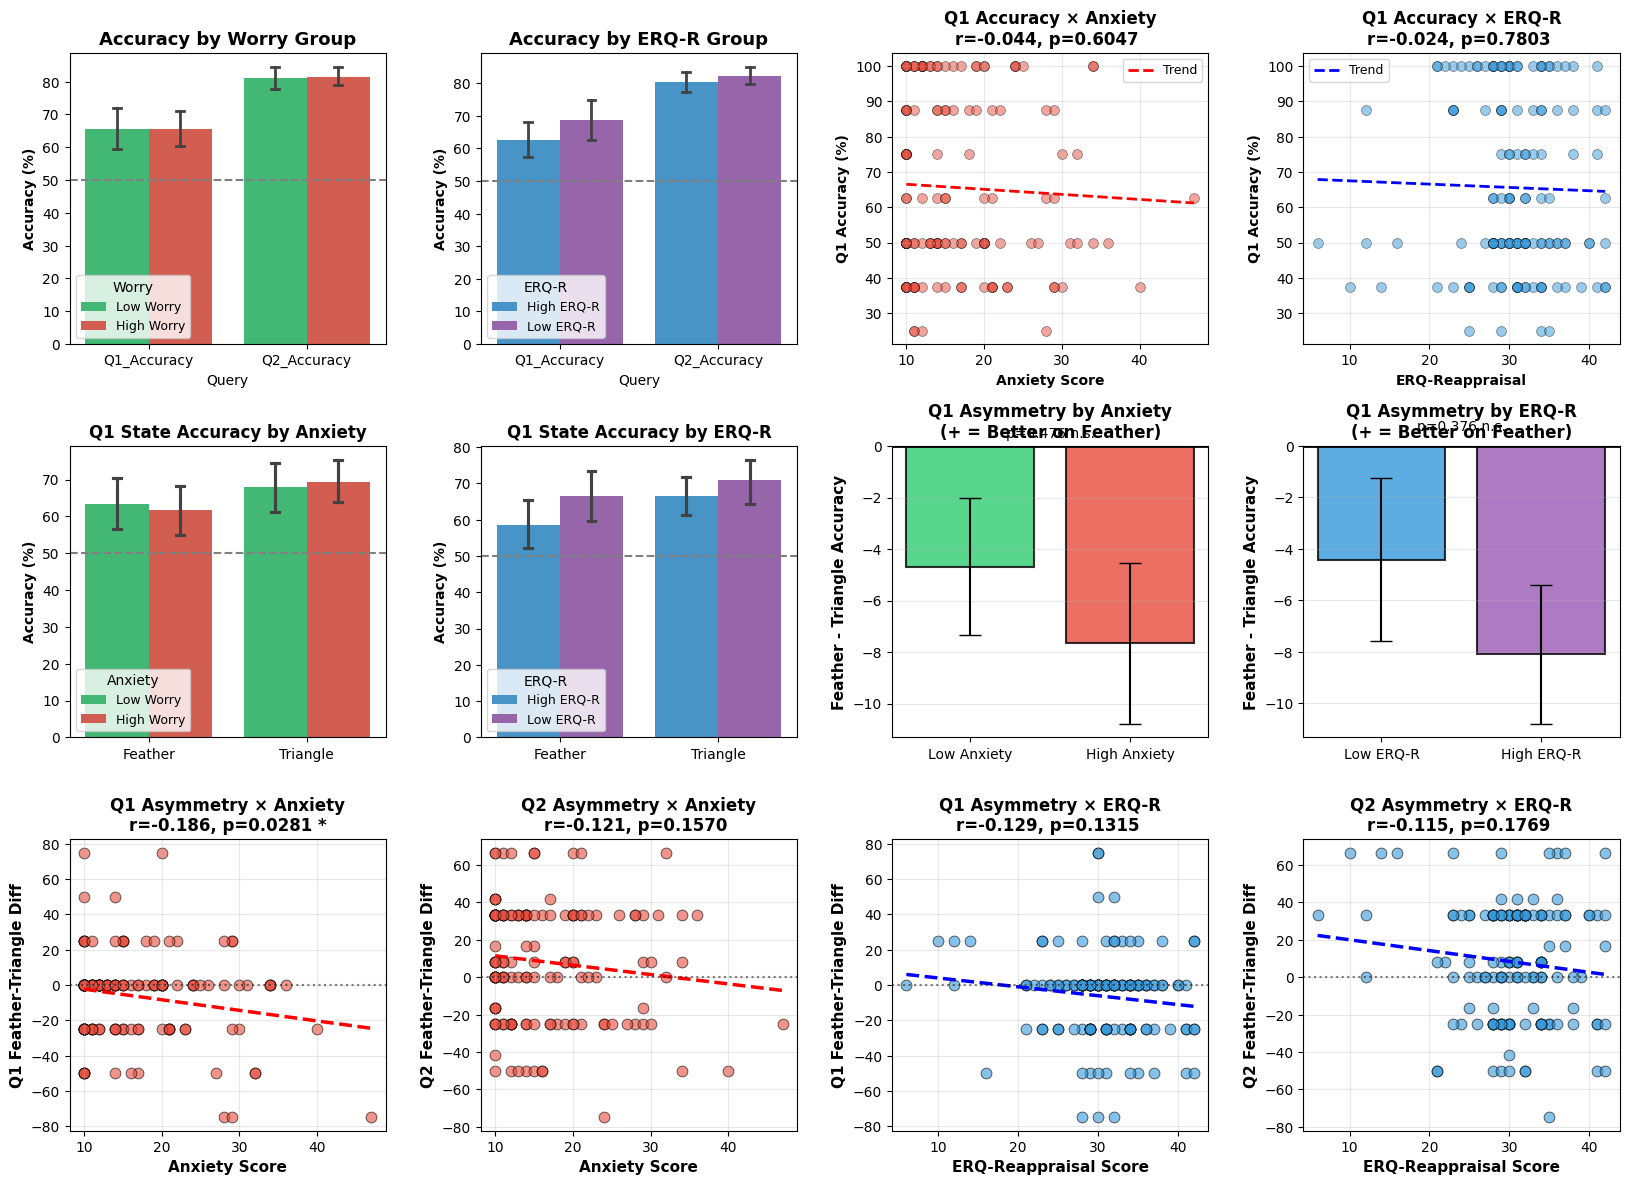

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, ttest_rel, ttest_1samp

# Load data
df = pd.read_csv('processed_data_with_metrics.csv')

# Only create columns if they don't exist
if 'subject_id' not in df.columns:
    df['subject_id'] = df['prolific_id']

if 'Anxiety_Total' not in df.columns:
    df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']

if 'ERQ_Reappraisal' not in df.columns:
    cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                    'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']
    df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)

# Median splits (calculate once)
median_worry = df['Anxiety_Total'].median()
median_erq = df['ERQ_Reappraisal'].median()

df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High Worry' if x >= median_worry else 'Low Worry'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High ERQ-R' if x >= median_erq else 'Low ERQ-R'
)

print("="*80)
print("INDIVIDUAL DIFFERENCES ANALYSIS")
print("="*80)

# Revaluation (only if not already computed)
if 'Feather_Revaluation' not in df.columns:
    df['Feather_Rating_1'] = df['Rating_1_Feather_Val']
    df['Triangle_Rating_1'] = df['Rating_1_Triangle_Val']
    df['Feather_Rating_2'] = df['Rating_2_Feather_Val']
    df['Triangle_Rating_2'] = df['Rating_2_Triangle_Val']
    df['Feather_Revaluation'] = df['Feather_Rating_2'] - df['Feather_Rating_1']
    df['Triangle_Revaluation'] = df['Triangle_Rating_2'] - df['Triangle_Rating_1']

# ============================================================================
# NEW: CALCULATE FEATHER - TRIANGLE DIFFERENCE SCORES
# ============================================================================

df['Q1_Diff_Feather_Triangle'] = df['Q1_Feather_Acc'] - df['Q1_Triangle_Acc']
df['Q2_Diff_Feather_Triangle'] = df['Q2_Feather_Acc'] - df['Q2_Triangle_Acc']

print("\n" + "="*80)
print("FEATHER - TRIANGLE DIFFERENCE SCORES")
print("="*80)
print("\nPositive = Better on Feather | Negative = Better on Triangle")
print(f"\nQ1 (Feather - Triangle): M={df['Q1_Diff_Feather_Triangle'].mean():>6.2f}, SD={df['Q1_Diff_Feather_Triangle'].std():>6.2f}")
print(f"Q2 (Feather - Triangle): M={df['Q2_Diff_Feather_Triangle'].mean():>6.2f}, SD={df['Q2_Diff_Feather_Triangle'].std():>6.2f}")

# Test if difference is significantly different from zero
t_q1, p_q1 = ttest_1samp(df['Q1_Diff_Feather_Triangle'].dropna(), 0)
t_q2, p_q2 = ttest_1samp(df['Q2_Diff_Feather_Triangle'].dropna(), 0)
sig_q1 = '***' if p_q1 < 0.001 else '**' if p_q1 < 0.01 else '*' if p_q1 < 0.05 else ''
sig_q2 = '***' if p_q2 < 0.001 else '**' if p_q2 < 0.01 else '*' if p_q2 < 0.05 else ''

print(f"\nOne-sample t-tests vs 0:")
print(f"  Q1: t({len(df)-1})={t_q1:6.3f}, p={p_q1:.4f} {sig_q1}")
print(f"  Q2: t({len(df)-1})={t_q2:6.3f}, p={p_q2:.4f} {sig_q2}")

print("\nRevaluation Magnitude:")
print(f"  Feather (pos→neg): M={df['Feather_Revaluation'].mean():.2f}, SD={df['Feather_Revaluation'].std():.2f}")
print(f"  Triangle (neg→pos): M={df['Triangle_Revaluation'].mean():.2f}, SD={df['Triangle_Revaluation'].std():.2f}")

# Correlations - ADD DIFFERENCE SCORES
measures = ['Q1_Accuracy', 'Q2_Accuracy', 'Q1_Feather_Acc', 'Q1_Triangle_Acc', 
            'Q2_Feather_Acc', 'Q2_Triangle_Acc', 'Q1_Diff_Feather_Triangle', 'Q2_Diff_Feather_Triangle',
            'Feather_Revaluation', 'Triangle_Revaluation']

print("\n" + "="*80)
print("CONTINUOUS CORRELATIONS")
print("="*80)

corr_results = {'worry': {}, 'erq': {}}

print("\n--- WORRY Correlations ---")
for measure in measures:
    if measure in df.columns:
        valid = df[[measure, 'Anxiety_Total']].dropna()
        r, p = pearsonr(valid[measure], valid['Anxiety_Total'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        corr_results['worry'][measure] = {'r': r, 'p': p, 'sig': sig, 'n': len(valid)}
        print(f"  {measure:25s}: r={r:6.3f}, p={p:.4f} {sig:3s} (n={len(valid)})")

print("\n--- ERQ-REAPPRAISAL Correlations ---")
for measure in measures:
    if measure in df.columns:
        valid = df[[measure, 'ERQ_Reappraisal']].dropna()
        r, p = pearsonr(valid[measure], valid['ERQ_Reappraisal'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        corr_results['erq'][measure] = {'r': r, 'p': p, 'sig': sig, 'n': len(valid)}
        print(f"  {measure:25s}: r={r:6.3f}, p={p:.4f} {sig:3s} (n={len(valid)})")

# Median split comparisons - ADD DIFFERENCE SCORES
print("\n" + "="*80)
print("MEDIAN SPLIT COMPARISONS")
print("="*80)

accuracy_measures = ['Q1_Accuracy', 'Q2_Accuracy', 'Q1_Feather_Acc', 'Q1_Triangle_Acc', 
                     'Q2_Feather_Acc', 'Q2_Triangle_Acc', 'Q1_Diff_Feather_Triangle', 'Q2_Diff_Feather_Triangle']

print("\n--- WORRY GROUPS ---")
for measure in accuracy_measures:
    low = df[df['Anxiety_Group']=='Low Worry'][measure].dropna()
    high = df[df['Anxiety_Group']=='High Worry'][measure].dropna()
    t, p = ttest_ind(low, high)
    pooled_std = np.sqrt((low.std()**2 + high.std()**2) / 2)
    d = (high.mean() - low.mean()) / pooled_std
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {measure:25s}: Low={low.mean():>6.2f}±{stats.sem(low):5.2f} (n={len(low):2d}), "
          f"High={high.mean():>6.2f}±{stats.sem(high):5.2f} (n={len(high):2d}), "
          f"t={t:7.3f}, p={p:.4f} {sig:3s}, d={d:6.3f}")

print("\n--- ERQ-REAPPRAISAL GROUPS ---")
for measure in accuracy_measures:
    low = df[df['ERQ_Reappraisal_Group']=='Low ERQ-R'][measure].dropna()
    high = df[df['ERQ_Reappraisal_Group']=='High ERQ-R'][measure].dropna()
    t, p = ttest_ind(low, high)
    pooled_std = np.sqrt((low.std()**2 + high.std()**2) / 2)
    d = (high.mean() - low.mean()) / pooled_std
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {measure:25s}: Low={low.mean():>6.2f}±{stats.sem(low):5.2f} (n={len(low):2d}), "
          f"High={high.mean():>6.2f}±{stats.sem(high):5.2f} (n={len(high):2d}), "
          f"t={t:7.3f}, p={p:.4f} {sig:3s}, d={d:6.3f}")

# FIXED: Within-subject revaluation asymmetry
print("\n" + "="*80)
print("HYPOTHESIS: Revaluation Asymmetry (Within-Subjects)")
print("="*80)

for group_label in ['Low Worry', 'High Worry']:
    group_df = df[df['Anxiety_Group'] == group_label]
    
    # Get subjects with BOTH revaluation scores
    valid_idx = group_df[['Feather_Revaluation', 'Triangle_Revaluation']].dropna().index
    feather_rev = abs(group_df.loc[valid_idx, 'Feather_Revaluation'])
    triangle_rev = abs(group_df.loc[valid_idx, 'Triangle_Revaluation'])
    
    # Paired t-test (now correctly paired)
    t, p = ttest_rel(feather_rev, triangle_rev)
    d = (feather_rev.mean() - triangle_rev.mean()) / np.std(feather_rev - triangle_rev)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    
    print(f"\n{group_label} (n={len(valid_idx)}):")
    print(f"  |Feather Change| (pos→neg): M={feather_rev.mean():.2f}, SD={feather_rev.std():.2f}")
    print(f"  |Triangle Change| (neg→pos): M={triangle_rev.mean():.2f}, SD={triangle_rev.std():.2f}")
    print(f"  Paired t-test: t={t:.3f}, p={p:.4f} {sig}, Cohen's d={d:.3f}")

# NEW: Test interaction (Does worry moderate the state difference?)
print("\n--- INTERACTION: Worry × State on Revaluation ---")
low_worry_df = df[df['Anxiety_Group']=='Low Worry'][['Feather_Revaluation', 'Triangle_Revaluation']].dropna()
high_worry_df = df[df['Anxiety_Group']=='High Worry'][['Feather_Revaluation', 'Triangle_Revaluation']].dropna()

low_diff = abs(low_worry_df['Feather_Revaluation']) - abs(low_worry_df['Triangle_Revaluation'])
high_diff = abs(high_worry_df['Feather_Revaluation']) - abs(high_worry_df['Triangle_Revaluation'])

t_int, p_int = ttest_ind(low_diff, high_diff)
sig_int = '***' if p_int < 0.001 else '**' if p_int < 0.01 else '*' if p_int < 0.05 else ''
print(f"  Low Worry: Diff = {low_diff.mean():.2f}")
print(f"  High Worry: Diff = {high_diff.mean():.2f}")
print(f"  Between-group t-test: t={t_int:.3f}, p={p_int:.4f} {sig_int}")

# ============================================================================
# ENHANCED VISUALIZATIONS WITH DIFFERENCE SCORES
# ============================================================================

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# =============== ROW 1: ORIGINAL PANELS ===============

# Panel 1: Accuracy by Worry Group
ax = plt.subplot(gs[0, 0])
plot_data = pd.melt(df, id_vars=['Anxiety_Group'], value_vars=['Q1_Accuracy', 'Q2_Accuracy'], 
                    var_name='Query', value_name='Accuracy')
sns.barplot(data=plot_data, x='Query', y='Accuracy', hue='Anxiety_Group', ax=ax, 
            palette=['#2ecc71', '#e74c3c'], capsize=0.1, errwidth=2)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.5)
ax.set_title('Accuracy by Worry Group', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.legend(title='Worry', fontsize=9)

# Panel 2: Accuracy by ERQ Group
ax = plt.subplot(gs[0, 1])
plot_data = pd.melt(df, id_vars=['ERQ_Reappraisal_Group'], value_vars=['Q1_Accuracy', 'Q2_Accuracy'], 
                    var_name='Query', value_name='Accuracy')
sns.barplot(data=plot_data, x='Query', y='Accuracy', hue='ERQ_Reappraisal_Group', ax=ax, 
            palette=['#3498db', '#9b59b6'], capsize=0.1, errwidth=2)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.5)
ax.set_title('Accuracy by ERQ-R Group', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.legend(title='ERQ-R', fontsize=9)

# Panel 3: Q1 Accuracy vs Worry
ax = plt.subplot(gs[0, 2])
valid = df[['Anxiety_Total', 'Q1_Accuracy']].dropna()
x, y = valid['Anxiety_Total'], valid['Q1_Accuracy']
ax.scatter(x, y, alpha=0.5, c='#e74c3c', s=50, edgecolors='black', linewidth=0.5)
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'r--', linewidth=2, label='Trend')
r = corr_results['worry']['Q1_Accuracy']['r']
pval = corr_results['worry']['Q1_Accuracy']['p']
sig = corr_results['worry']['Q1_Accuracy']['sig']
ax.set_xlabel('Anxiety Score', fontweight='bold')
ax.set_ylabel('Q1 Accuracy (%)', fontweight='bold')
ax.set_title(f'Q1 Accuracy × Anxiety\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 4: Q1 Accuracy vs ERQ-R
ax = plt.subplot(gs[0, 3])
valid = df[['ERQ_Reappraisal', 'Q1_Accuracy']].dropna()
x, y = valid['ERQ_Reappraisal'], valid['Q1_Accuracy']
ax.scatter(x, y, alpha=0.5, c='#3498db', s=50, edgecolors='black', linewidth=0.5)
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'b--', linewidth=2, label='Trend')
r = corr_results['erq']['Q1_Accuracy']['r']
pval = corr_results['erq']['Q1_Accuracy']['p']
sig = corr_results['erq']['Q1_Accuracy']['sig']
ax.set_xlabel('ERQ-Reappraisal', fontweight='bold')
ax.set_ylabel('Q1 Accuracy (%)', fontweight='bold')
ax.set_title(f'Q1 Accuracy × ERQ-R\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# =============== ROW 2: STATE-SPECIFIC ===============

# Panel 5: State accuracy by Worry
ax = plt.subplot(gs[1, 0])
state_data = pd.melt(df, id_vars=['Anxiety_Group'], 
                     value_vars=['Q1_Feather_Acc', 'Q1_Triangle_Acc'], 
                     var_name='State', value_name='Accuracy')
state_data['State'] = state_data['State'].map({
    'Q1_Feather_Acc': 'Feather', 
    'Q1_Triangle_Acc': 'Triangle'
})
sns.barplot(data=state_data, x='State', y='Accuracy', hue='Anxiety_Group', ax=ax, 
            palette=['#2ecc71', '#e74c3c'], capsize=0.1)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.5)
ax.set_title('Q1 State Accuracy by Anxiety', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_xlabel('')
ax.legend(title='Anxiety', fontsize=9)

# Panel 6: State accuracy by ERQ-R
ax = plt.subplot(gs[1, 1])
state_data = pd.melt(df, id_vars=['ERQ_Reappraisal_Group'], 
                     value_vars=['Q1_Feather_Acc', 'Q1_Triangle_Acc'], 
                     var_name='State', value_name='Accuracy')
state_data['State'] = state_data['State'].map({
    'Q1_Feather_Acc': 'Feather', 
    'Q1_Triangle_Acc': 'Triangle'
})
sns.barplot(data=state_data, x='State', y='Accuracy', hue='ERQ_Reappraisal_Group', ax=ax, 
            palette=['#3498db', '#9b59b6'], capsize=0.1)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.5)
ax.set_title('Q1 State Accuracy by ERQ-R', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_xlabel('')
ax.legend(title='ERQ-R', fontsize=9)

# =============== NEW: DIFFERENCE SCORE PANELS ===============

# Panel 7: Q1 Diff by Anxiety Groups
ax = plt.subplot(gs[1, 2])
low_q1_diff = df[df['Anxiety_Group']=='Low Worry']['Q1_Diff_Feather_Triangle'].dropna()
high_q1_diff = df[df['Anxiety_Group']=='High Worry']['Q1_Diff_Feather_Triangle'].dropna()
bars = ax.bar(['Low Anxiety', 'High Anxiety'], 
              [low_q1_diff.mean(), high_q1_diff.mean()],
              yerr=[stats.sem(low_q1_diff), stats.sem(high_q1_diff)],
              capsize=8, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='black', linestyle='-', linewidth=2)
ax.set_ylabel('Feather - Triangle Accuracy', fontweight='bold', fontsize=11)
ax.set_title('Q1 Asymmetry by Anxiety\n(+ = Better on Feather)', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
# Add significance
t_test, p_test = ttest_ind(low_q1_diff, high_q1_diff)
sig_test = '***' if p_test < 0.001 else '**' if p_test < 0.01 else '*' if p_test < 0.05 else 'n.s.'
ax.text(0.5, max(low_q1_diff.mean(), high_q1_diff.mean()) + 5, 
       f'p={p_test:.3f} {sig_test}', ha='center', fontsize=10)

# Panel 8: Q1 Diff by ERQ-R Groups
ax = plt.subplot(gs[1, 3])
low_q1_diff = df[df['ERQ_Reappraisal_Group']=='Low ERQ-R']['Q1_Diff_Feather_Triangle'].dropna()
high_q1_diff = df[df['ERQ_Reappraisal_Group']=='High ERQ-R']['Q1_Diff_Feather_Triangle'].dropna()
bars = ax.bar(['Low ERQ-R', 'High ERQ-R'], 
              [low_q1_diff.mean(), high_q1_diff.mean()],
              yerr=[stats.sem(low_q1_diff), stats.sem(high_q1_diff)],
              capsize=8, color=['#3498db', '#9b59b6'], edgecolor='black', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='black', linestyle='-', linewidth=2)
ax.set_ylabel('Feather - Triangle Accuracy', fontweight='bold', fontsize=11)
ax.set_title('Q1 Asymmetry by ERQ-R\n(+ = Better on Feather)', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
# Add significance
t_test, p_test = ttest_ind(low_q1_diff, high_q1_diff)
sig_test = '***' if p_test < 0.001 else '**' if p_test < 0.01 else '*' if p_test < 0.05 else 'n.s.'
ax.text(0.5, max(low_q1_diff.mean(), high_q1_diff.mean()) + 5, 
       f'p={p_test:.3f} {sig_test}', ha='center', fontsize=10)

# =============== ROW 3: Q1 vs Q2 DIFFERENCE CORRELATIONS ===============

# Panel 9: Q1 Diff vs Anxiety (scatter)
ax = plt.subplot(gs[2, 0])
valid = df[['Anxiety_Total', 'Q1_Diff_Feather_Triangle']].dropna()
x, y = valid['Anxiety_Total'], valid['Q1_Diff_Feather_Triangle']
ax.scatter(x, y, alpha=0.6, s=60, edgecolors='black', linewidth=0.7, color='#e74c3c')
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'r--', linewidth=2.5)
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
r = corr_results['worry']['Q1_Diff_Feather_Triangle']['r']
pval = corr_results['worry']['Q1_Diff_Feather_Triangle']['p']
sig = corr_results['worry']['Q1_Diff_Feather_Triangle']['sig']
ax.set_xlabel('Anxiety Score', fontweight='bold', fontsize=11)
ax.set_ylabel('Q1 Feather-Triangle Diff', fontweight='bold', fontsize=11)
ax.set_title(f'Q1 Asymmetry × Anxiety\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Panel 10: Q2 Diff vs Anxiety (scatter)
ax = plt.subplot(gs[2, 1])
valid = df[['Anxiety_Total', 'Q2_Diff_Feather_Triangle']].dropna()
x, y = valid['Anxiety_Total'], valid['Q2_Diff_Feather_Triangle']
ax.scatter(x, y, alpha=0.6, s=60, edgecolors='black', linewidth=0.7, color='#e74c3c')
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'r--', linewidth=2.5)
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
r = corr_results['worry']['Q2_Diff_Feather_Triangle']['r']
pval = corr_results['worry']['Q2_Diff_Feather_Triangle']['p']
sig = corr_results['worry']['Q2_Diff_Feather_Triangle']['sig']
ax.set_xlabel('Anxiety Score', fontweight='bold', fontsize=11)
ax.set_ylabel('Q2 Feather-Triangle Diff', fontweight='bold', fontsize=11)
ax.set_title(f'Q2 Asymmetry × Anxiety\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Panel 11: Q1 Diff vs ERQ-R (scatter)
ax = plt.subplot(gs[2, 2])
valid = df[['ERQ_Reappraisal', 'Q1_Diff_Feather_Triangle']].dropna()
x, y = valid['ERQ_Reappraisal'], valid['Q1_Diff_Feather_Triangle']
ax.scatter(x, y, alpha=0.6, s=60, edgecolors='black', linewidth=0.7, color='#3498db')
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'b--', linewidth=2.5)
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
r = corr_results['erq']['Q1_Diff_Feather_Triangle']['r']
pval = corr_results['erq']['Q1_Diff_Feather_Triangle']['p']
sig = corr_results['erq']['Q1_Diff_Feather_Triangle']['sig']
ax.set_xlabel('ERQ-Reappraisal Score', fontweight='bold', fontsize=11)
ax.set_ylabel('Q1 Feather-Triangle Diff', fontweight='bold', fontsize=11)
ax.set_title(f'Q1 Asymmetry × ERQ-R\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Panel 12: Q2 Diff vs ERQ-R (scatter)
ax = plt.subplot(gs[2, 3])
valid = df[['ERQ_Reappraisal', 'Q2_Diff_Feather_Triangle']].dropna()
x, y = valid['ERQ_Reappraisal'], valid['Q2_Diff_Feather_Triangle']
ax.scatter(x, y, alpha=0.6, s=60, edgecolors='black', linewidth=0.7, color='#3498db')
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_line(x_line), 'b--', linewidth=2.5)
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
r = corr_results['erq']['Q2_Diff_Feather_Triangle']['r']
pval = corr_results['erq']['Q2_Diff_Feather_Triangle']['p']
sig = corr_results['erq']['Q2_Diff_Feather_Triangle']['sig']
ax.set_xlabel('ERQ-Reappraisal Score', fontweight='bold', fontsize=11)
ax.set_ylabel('Q2 Feather-Triangle Diff', fontweight='bold', fontsize=11)
ax.set_title(f'Q2 Asymmetry × ERQ-R\nr={r:.3f}, p={pval:.4f} {sig}', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

plt.savefig('individual_differences_analysis_with_diffs.png', dpi=300, bbox_inches='tight')
print("\n" + "="*80)
print("Saved: individual_differences_analysis_with_diffs.png")
print("="*80)
plt.show()

# Save
df.to_csv('filtered_data.csv', index=False)


---
# P(gamble analysis)

Loaded 139 subjects
Median Anxiety: 14.0
Median ERQ: 31.0

PREPARING DATA - EXCLUDING TIES WHERE GAMBLE EV = FIXED OFFER

Total trials INCLUDED: 2085
Total trials EXCLUDED (EV_diff = 0): 139

Breakdown by condition:
  Q2_Triangle: 139 trials excluded

✓ Saved: p_gamble_evdiff_detailed.png
✓ Saved: p_gamble_evdiff_combined.png
✓ Saved: p_gamble_offer_detailed.png
✓ Saved: p_gamble_offer_combined.png

STATISTICAL ANALYSIS: FIXED OFFER vs P(GAMBLE)
Pearson Correlation between Fixed Offer Value and Gambling Probability
NOTE: Ties (EV = Offer) excluded from analysis
Query Type      | EV    | Pearson r  | p-value    | N Offers
----------------------------------------------------------------------
Q1_Feather      | -15   | -0.985     | 0.0155     | 4       
Q1_Triangle     | 15    | -0.998     | 0.0022     | 4       
Q2_Feather      | 0     | -0.931     | 0.0689     | 4       
Q2_Triangle     | 10    | -0.995     | 0.0667     | 3       

STATISTICAL ANALYSIS: TRAIT INTERACTIONS
Model: Logit(P

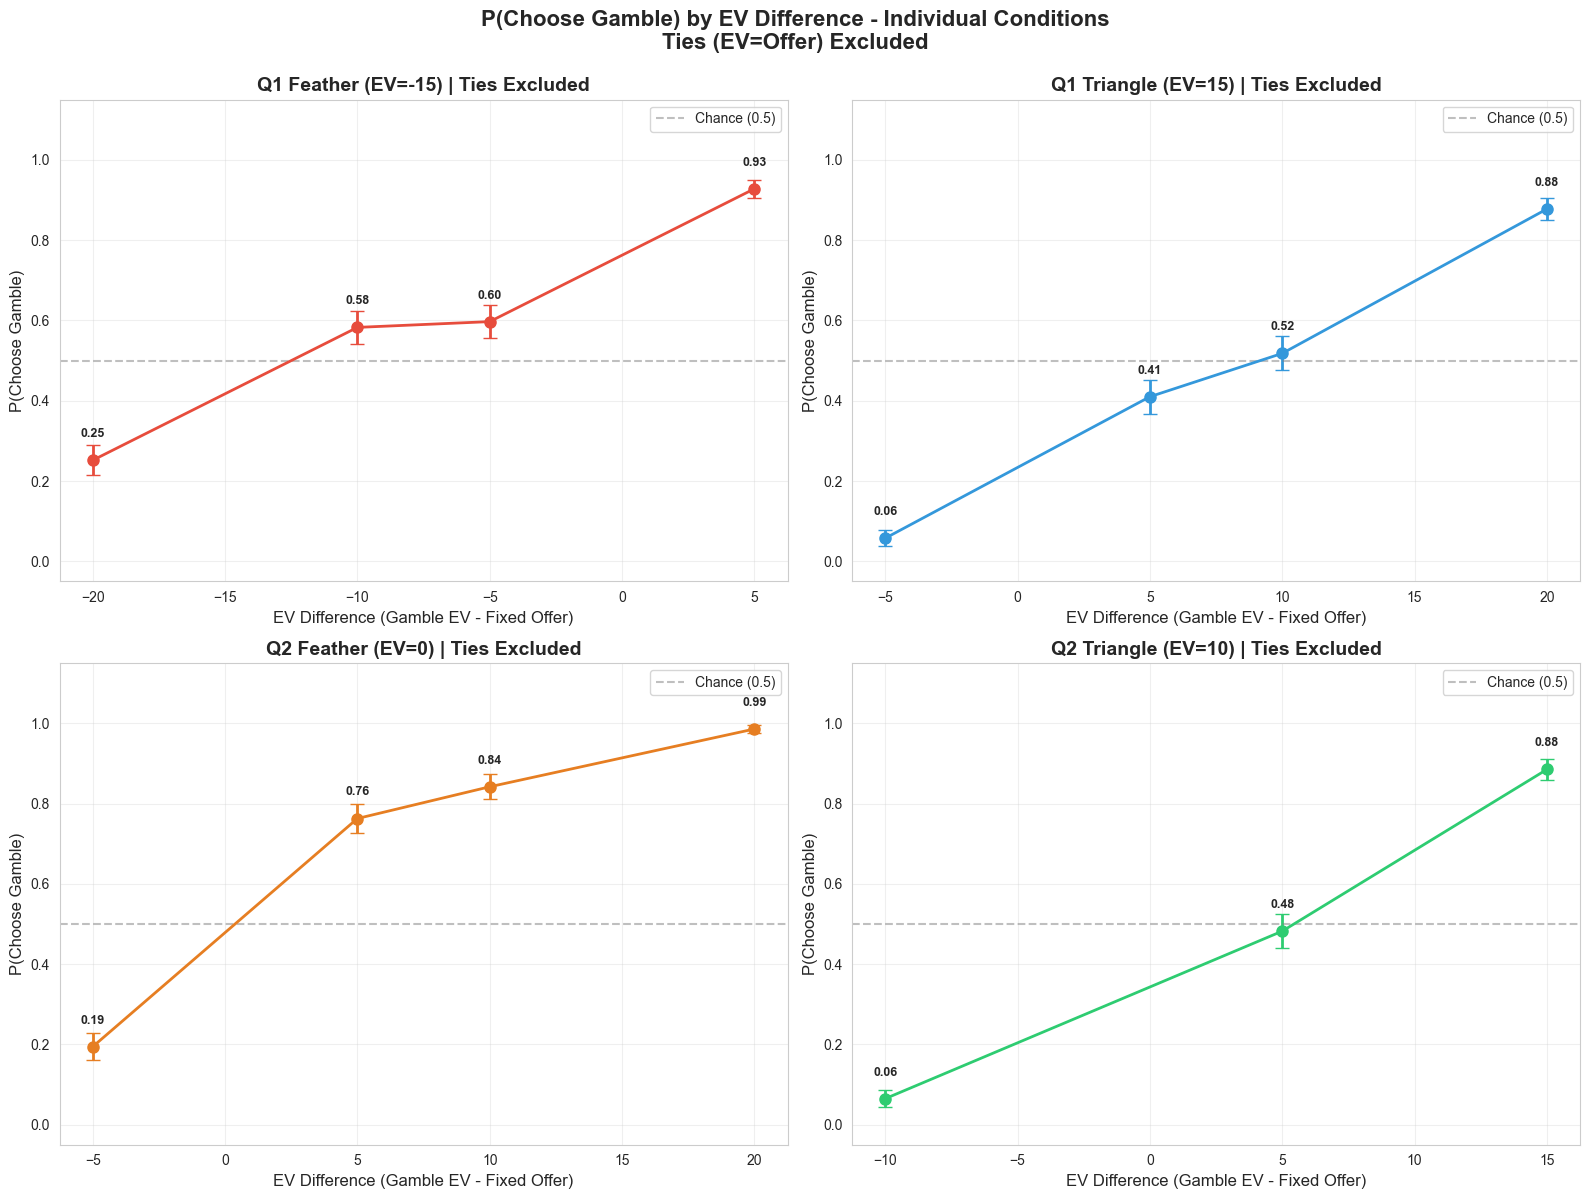

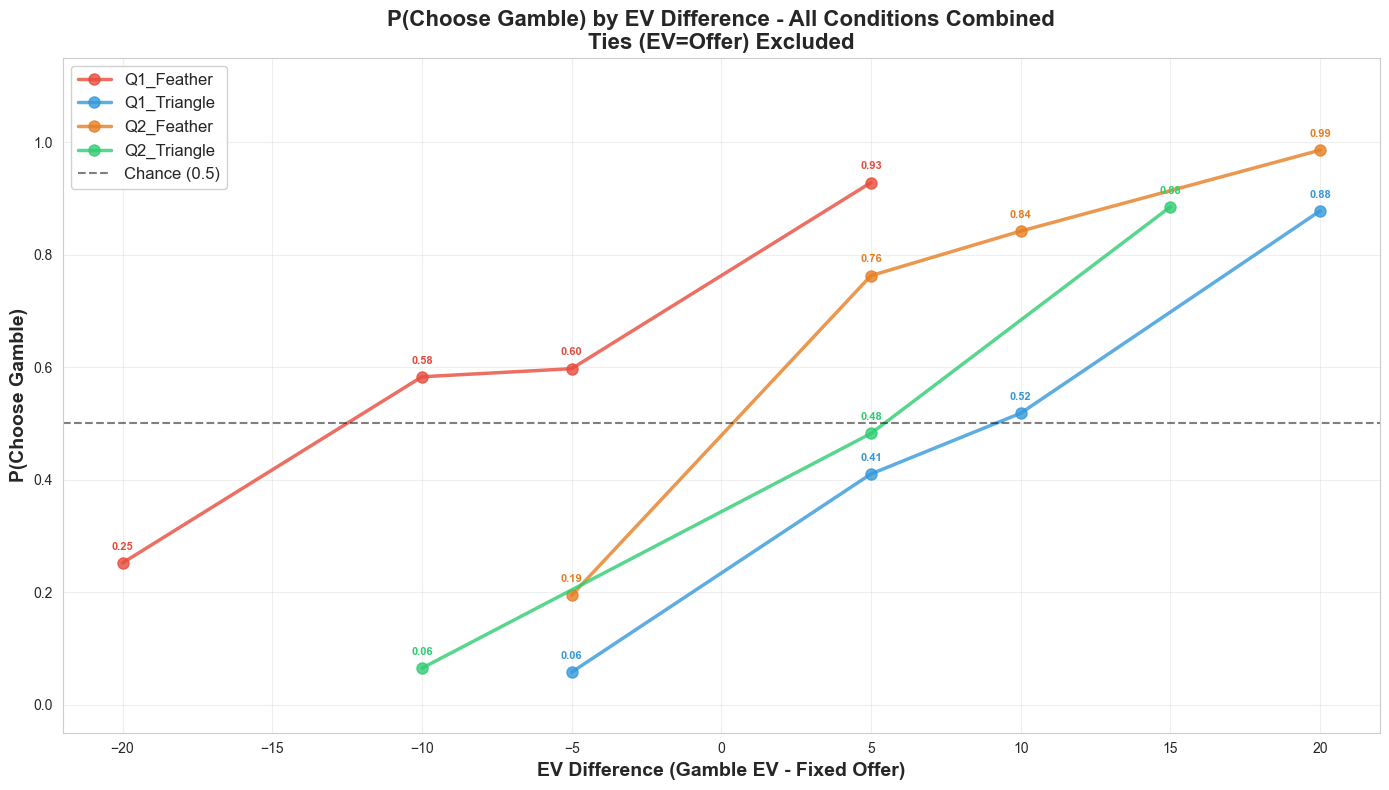

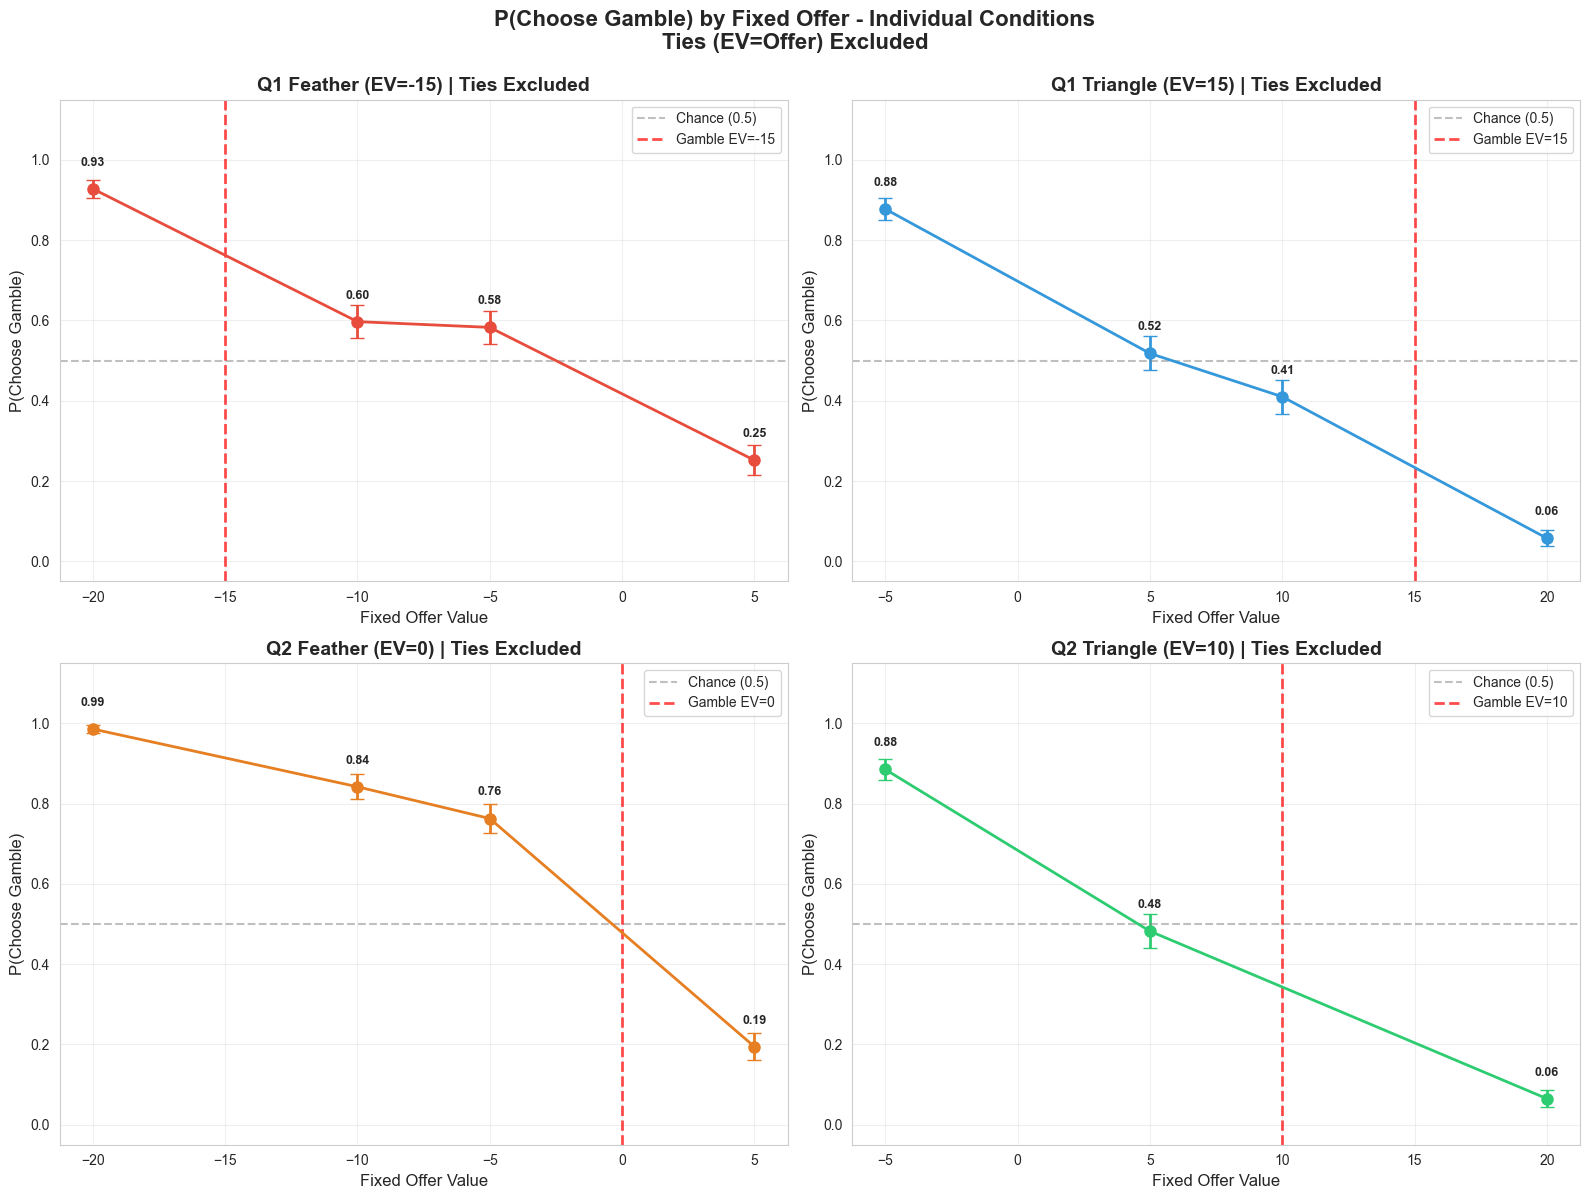

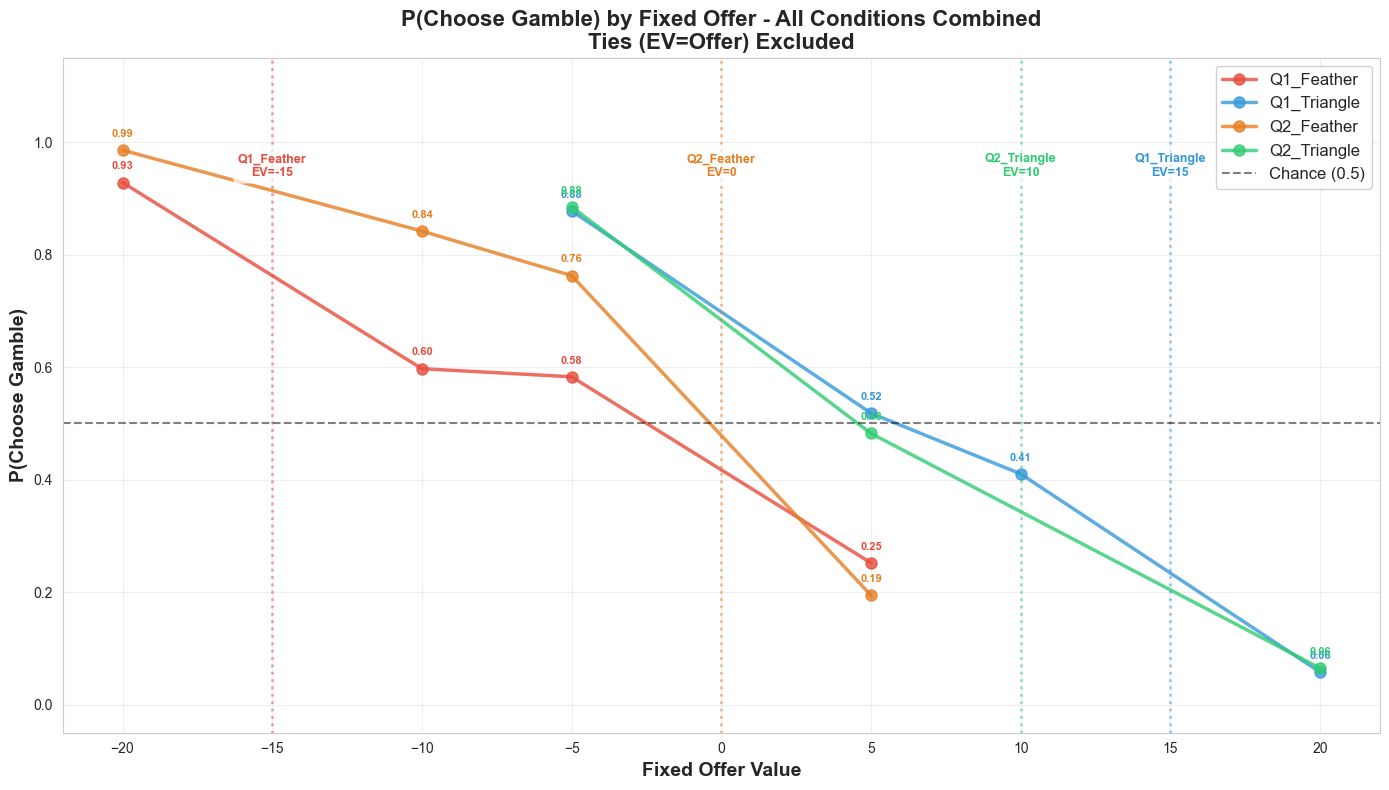

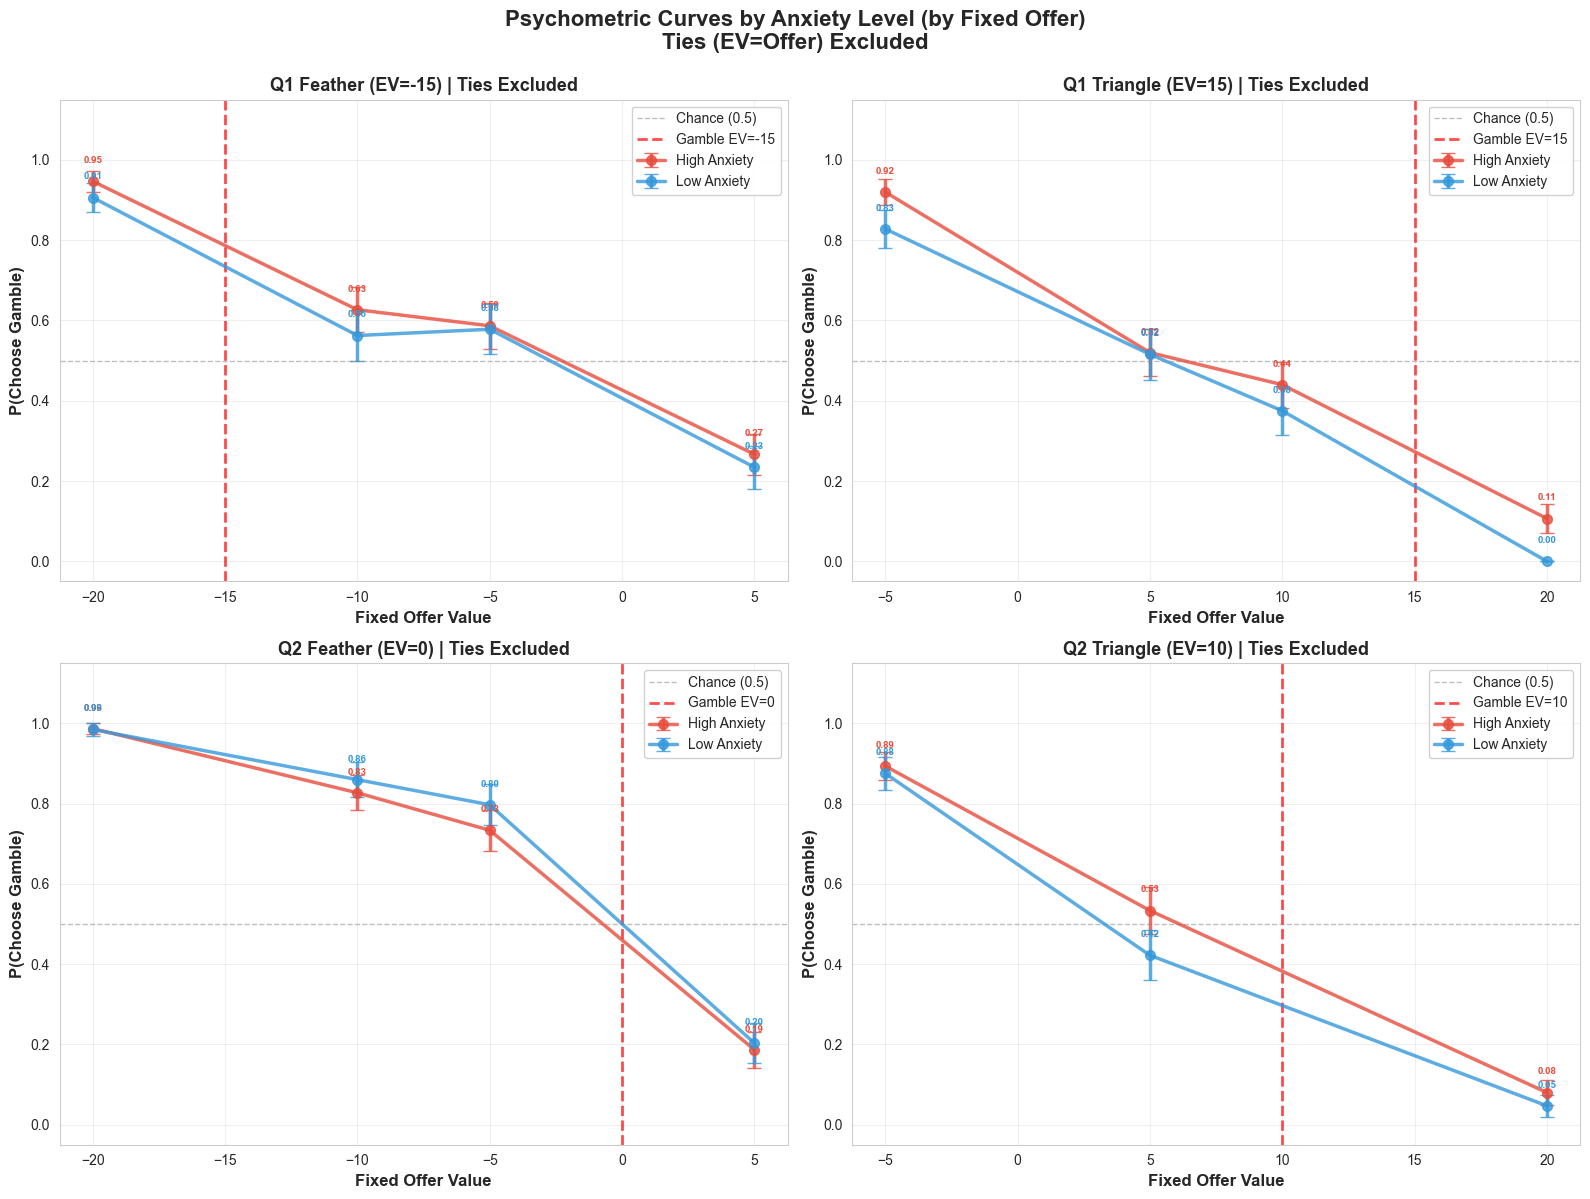

✓ Saved: curves_erq_by_offer.png


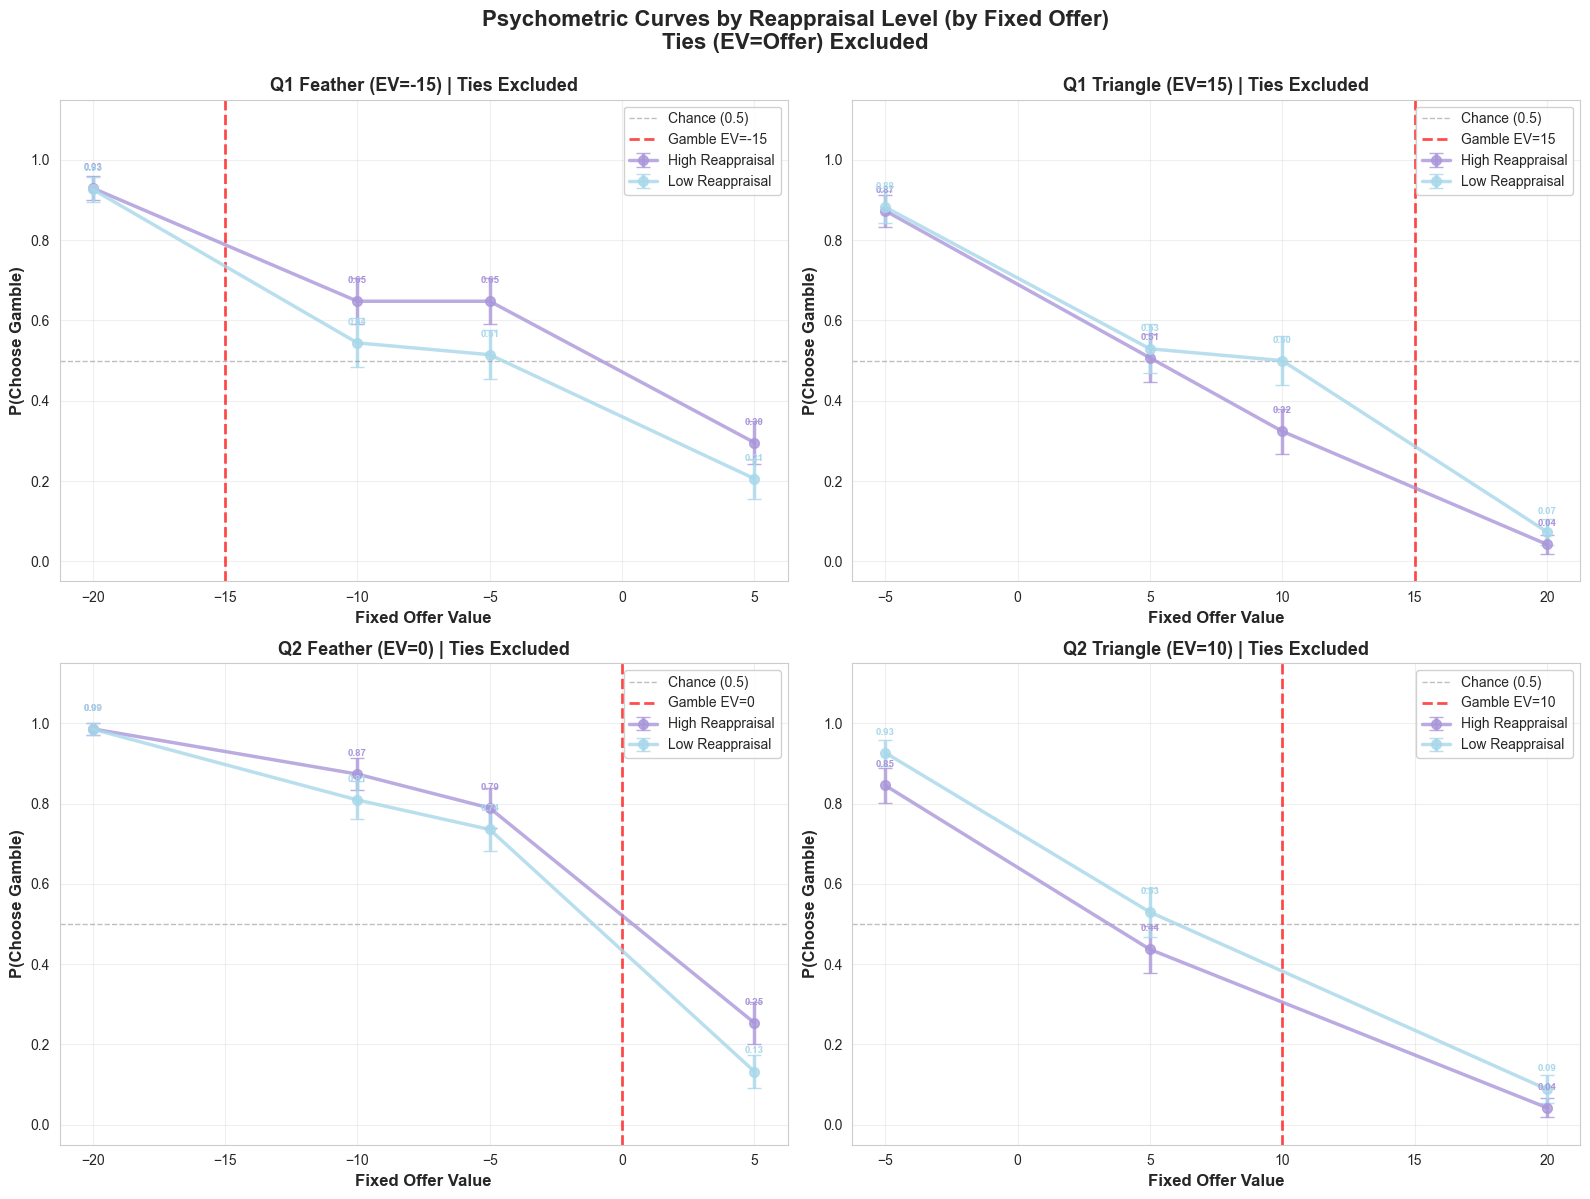


ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!
Total trials analyzed: 2085
Trials excluded (ties): 139


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_csv('filtered_data.csv')
print(f"Loaded {len(df)} subjects")

# ----------------------------------------------------------------------------
# 1. CALCULATE SCORES (Anxiety & ERQ)
# ----------------------------------------------------------------------------
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
median_anx = df['Anxiety_Total'].median()
df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Anxiety' if x >= median_anx else 'Low Anxiety')

erq_cols = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
            'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

if all(col in df.columns for col in erq_cols):
    df['ERQ_Reappraisal'] = df[erq_cols].sum(axis=1)
else:
    df['ERQ_Reappraisal'] = df.get('Survey_ERQ_Reappraisal_Score', np.nan)

median_erq = df['ERQ_Reappraisal'].median()
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High Reappraisal' if x >= median_erq else 'Low Reappraisal')

print(f"Median Anxiety: {median_anx}")
print(f"Median ERQ: {median_erq}")

# ----------------------------------------------------------------------------
# 2. PREPARE LONG FORMAT DATA (WITH TIE EXCLUSION)
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("PREPARING DATA - EXCLUDING TIES WHERE GAMBLE EV = FIXED OFFER")
print("="*80)

long_data = []
ties_excluded = 0

for idx, row in df.iterrows():
    subj_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anx_group = row['Anxiety_Group']
    erq = row['ERQ_Reappraisal']
    erq_group = row['ERQ_Group']

    for query_num in [1, 2]:
        for trial_num in range(1, 9):
            trial_col_prefix = f'Query_{query_num}_T{trial_num}'
            choice = row.get(f'{trial_col_prefix}_Choice', np.nan)
            state = row.get(f'{trial_col_prefix}_State', np.nan)
            fixed_offer = row.get(f'{trial_col_prefix}_FixedOffer', np.nan)

            if pd.isna(choice) or pd.isna(state) or pd.isna(fixed_offer):
                continue

            query_type = f"Q{query_num}_{state}"

            ev_dict = {
                (1, 'Feather'): -15, (2, 'Feather'): 0,
                (1, 'Triangle'): 15, (2, 'Triangle'): 10
            }
            ev = ev_dict.get((query_num, state), np.nan)

            ev_difference = ev - fixed_offer

            # CRITICAL: Skip ties where Gamble EV = Fixed Offer (EV_diff = 0)
            if ev_difference == 0:
                ties_excluded += 1
                continue  # Don't include this trial

            chose_gamble = int(choice)

            long_data.append({
                'subject_id': subj_id,
                'Anxiety_Total': anxiety,
                'Anxiety_Group': anx_group,
                'ERQ_Reappraisal': erq,
                'ERQ_Group': erq_group,
                'query_num': query_num,
                'state': state,
                'ev': ev,
                'query_type': query_type,
                'ev_difference': ev_difference,
                'chose_gamble': chose_gamble,
                'fixed_offer': fixed_offer
            })

long_df = pd.DataFrame(long_data)
print(f"\nTotal trials INCLUDED: {len(long_df)}")
print(f"Total trials EXCLUDED (EV_diff = 0): {ties_excluded}")

# Show breakdown by condition
excluded_breakdown = {}
for query_num in [1, 2]:
    for state in ['Feather', 'Triangle']:
        ev = ev_dict.get((query_num, state))
        # Count how many times this EV matches the fixed offers in original data
        count = 0
        for idx, row in df.iterrows():
            for trial_num in range(1, 9):
                trial_col_prefix = f'Query_{query_num}_T{trial_num}'
                s = row.get(f'{trial_col_prefix}_State', np.nan)
                fo = row.get(f'{trial_col_prefix}_FixedOffer', np.nan)
                if s == state and fo == ev:
                    count += 1
        excluded_breakdown[f'Q{query_num}_{state}'] = count

print("\nBreakdown by condition:")
for key, val in excluded_breakdown.items():
    if val > 0:
        print(f"  {key}: {val} trials excluded")

# ----------------------------------------------------------------------------
# 3. AGGREGATE DATA FOR PLOTTING
# ----------------------------------------------------------------------------
# By EV Difference
choice_by_evdiff = long_df.groupby(['query_type', 'ev_difference']).agg(
    p_gamble=('chose_gamble', 'mean'),
    n_trials=('chose_gamble', 'count'),
    se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

# By Fixed Offer
choice_by_offer = long_df.groupby(['query_type', 'fixed_offer']).agg(
    p_gamble=('chose_gamble', 'mean'),
    n_trials=('chose_gamble', 'count'),
    se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

query_types = ['Q1_Feather', 'Q1_Triangle', 'Q2_Feather', 'Q2_Triangle']
colors = {
    'Q1_Feather': '#e74c3c',    # Red
    'Q1_Triangle': '#3498db',   # Blue
    'Q2_Feather': '#e67e22',    # Orange
    'Q2_Triangle': '#2ecc71'    # Green
}

# ----------------------------------------------------------------------------
# 4. FIGURE 1: INDIVIDUAL PLOTS WITH EXACT VALUES (BY EV DIFFERENCE)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, qt in enumerate(query_types):
    ax = axes[i]
    subset = choice_by_evdiff[choice_by_evdiff['query_type'] == qt].sort_values('ev_difference')

    if len(subset) > 0:
        # Plot line with error bars
        ax.errorbar(subset['ev_difference'], subset['p_gamble'], yerr=subset['se'], 
                   fmt='o-', color=colors[qt], linewidth=2, markersize=8, capsize=5)

        # Add exact values as text labels
        for _, row in subset.iterrows():
            ax.text(row['ev_difference'], row['p_gamble'] + 0.05, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Extract query details
    query_num = qt.split('_')[0]
    state = qt.split('_')[1]
    ev_val = long_df[long_df['query_type'] == qt]['ev'].iloc[0]

    # Add reference lines
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
    # NOTE: Don't plot vertical line at 0 since we excluded those trials

    # Styling
    ax.set_title(f'{query_num} {state} (EV={ev_val}) | Ties Excluded', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('EV Difference (Gamble EV - Fixed Offer)', fontsize=12)
    ax.set_ylabel('P(Choose Gamble)', fontsize=12)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('P(Choose Gamble) by EV Difference - Individual Conditions\nTies (EV=Offer) Excluded', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('p_gamble_evdiff_detailed.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: p_gamble_evdiff_detailed.png")

# ----------------------------------------------------------------------------
# 5. FIGURE 2: COMBINED PLOT - ALL CONDITIONS (BY EV DIFFERENCE)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for qt in query_types:
    subset = choice_by_evdiff[choice_by_evdiff['query_type'] == qt].sort_values('ev_difference')

    if len(subset) > 0:
        # Plot line
        ax.plot(subset['ev_difference'], subset['p_gamble'], 
               'o-', color=colors[qt], linewidth=2.5, markersize=8, 
               label=qt, alpha=0.8)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['ev_difference'], row['p_gamble'] + 0.02, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=8, 
                   color=colors[qt], fontweight='bold')

# Reference lines
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')

# Styling
ax.set_xlabel('EV Difference (Gamble EV - Fixed Offer)', fontsize=14, fontweight='bold')
ax.set_ylabel('P(Choose Gamble)', fontsize=14, fontweight='bold')
ax.set_title('P(Choose Gamble) by EV Difference - All Conditions Combined\nTies (EV=Offer) Excluded', 
            fontsize=16, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('p_gamble_evdiff_combined.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_evdiff_combined.png")

# ----------------------------------------------------------------------------
# 6. FIGURE 3: INDIVIDUAL PLOTS WITH EXACT VALUES (BY FIXED OFFER)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, qt in enumerate(query_types):
    ax = axes[i]
    subset = choice_by_offer[choice_by_offer['query_type'] == qt].sort_values('fixed_offer')

    if len(subset) > 0:
        # Plot line with error bars
        ax.errorbar(subset['fixed_offer'], subset['p_gamble'], yerr=subset['se'], 
                   fmt='o-', color=colors[qt], linewidth=2, markersize=8, capsize=5)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['fixed_offer'], row['p_gamble'] + 0.05, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Extract query details
    query_num = qt.split('_')[0]
    state = qt.split('_')[1]
    ev_val = long_df[long_df['query_type'] == qt]['ev'].iloc[0]

    # Add reference lines
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
    ax.axvline(ev_val, color='red', linestyle='--', alpha=0.7, linewidth=2, 
              label=f'Gamble EV={ev_val}')

    # Styling
    ax.set_title(f'{query_num} {state} (EV={ev_val}) | Ties Excluded', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Fixed Offer Value', fontsize=12)
    ax.set_ylabel('P(Choose Gamble)', fontsize=12)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('P(Choose Gamble) by Fixed Offer - Individual Conditions\nTies (EV=Offer) Excluded', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('p_gamble_offer_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_offer_detailed.png")

# ----------------------------------------------------------------------------
# 7. FIGURE 4: COMBINED PLOT - ALL CONDITIONS (BY FIXED OFFER)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for qt in query_types:
    subset = choice_by_offer[choice_by_offer['query_type'] == qt].sort_values('fixed_offer')

    if len(subset) > 0:
        # Plot line
        ax.plot(subset['fixed_offer'], subset['p_gamble'], 
               'o-', color=colors[qt], linewidth=2.5, markersize=8, 
               label=qt, alpha=0.8)

        # Add exact values
        for _, row in subset.iterrows():
            ax.text(row['fixed_offer'], row['p_gamble'] + 0.02, 
                   f"{row['p_gamble']:.2f}", 
                   ha='center', va='bottom', fontsize=8, 
                   color=colors[qt], fontweight='bold')

# Add vertical lines for each EV
ev_lines = {
    'Q1_Feather': -15,
    'Q1_Triangle': 15,
    'Q2_Feather': 0,
    'Q2_Triangle': 10
}
for qt, ev in ev_lines.items():
    ax.axvline(ev, color=colors[qt], linestyle=':', alpha=0.5, linewidth=2)
    ax.text(ev, 0.98, f'{qt}\nEV={ev}', ha='center', va='top', 
           fontsize=9, color=colors[qt], fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Reference line
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')

# Styling
ax.set_xlabel('Fixed Offer Value', fontsize=14, fontweight='bold')
ax.set_ylabel('P(Choose Gamble)', fontsize=14, fontweight='bold')
ax.set_title('P(Choose Gamble) by Fixed Offer - All Conditions Combined\nTies (EV=Offer) Excluded', 
            fontsize=16, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('p_gamble_offer_combined.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_offer_combined.png")

# ----------------------------------------------------------------------------
# 8. STATISTICAL ANALYSIS: CORRELATIONS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL ANALYSIS: FIXED OFFER vs P(GAMBLE)")
print("Pearson Correlation between Fixed Offer Value and Gambling Probability")
print("NOTE: Ties (EV = Offer) excluded from analysis")
print("="*80)

conditions = long_df[['query_num', 'state', 'ev', 'query_type']].drop_duplicates().sort_values('query_type')
print(f"{'Query Type':<15} | {'EV':<5} | {'Pearson r':<10} | {'p-value':<10} | {'N Offers':<8}")
print("-" * 70)

for _, cond in conditions.iterrows():
    qt = cond['query_type']
    ev_val = cond['ev']

    subset = long_df[long_df['query_type'] == qt]
    offer_stats = subset.groupby('fixed_offer')['chose_gamble'].agg(['mean', 'count']).reset_index()
    offer_stats.rename(columns={'mean': 'p_gamble'}, inplace=True)

    if len(offer_stats) > 1:
        r, p = stats.pearsonr(offer_stats['fixed_offer'], offer_stats['p_gamble'])
        print(f"{qt:<15} | {ev_val:<5} | {r:<10.3f} | {p:<10.4f} | {len(offer_stats):<8}")
    else:
        print(f"{qt:<15} | {ev_val:<5} | {'NaN':<10} | {'NaN':<10} | {len(offer_stats):<8}")

# ----------------------------------------------------------------------------
# 9. LOGISTIC REGRESSION WITH INTERACTIONS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL ANALYSIS: TRAIT INTERACTIONS")
print("Model: Logit(P_Gamble) ~ EV_Diff * Trait")
print("NOTE: Ties (EV_diff = 0) excluded from analysis")
print("="*80)

def analyze_interaction(data, trait_col, trait_name, label):
    print(f"\n>>> {label} : {trait_name} <<<")

    if trait_col not in data.columns:
        print(f"  Error: Column '{trait_col}' not found.")
        return

    data['trait_z'] = (data[trait_col] - data[trait_col].mean()) / data[trait_col].std()
    formula = "chose_gamble ~ ev_difference * trait_z"

    try:
        model = smf.logit(formula, data=data).fit(disp=0)
        print(model.summary2().tables[1])

        params = model.params
        pvals = model.pvalues
        sig_threshold = 0.05

        if pvals['trait_z'] < sig_threshold:
            direction = "INCREASES" if params['trait_z'] > 0 else "DECREASES"
            print(f"  * SIGNIFICANT MAIN EFFECT: Higher {trait_name} {direction} overall gambling rate.")

        if pvals['ev_difference:trait_z'] < sig_threshold:
            direction = "STEEPER" if params['ev_difference:trait_z'] > 0 else "FLATTER"
            print(f"  * SIGNIFICANT INTERACTION: Higher {trait_name} makes curve {direction}.")

    except Exception as e:
        print(f"  Error: {e}")

for qt in query_types:
    subset = long_df[long_df['query_type'] == qt].copy()
    analyze_interaction(subset, 'Anxiety_Total', 'Anxiety', f"{qt}")
    analyze_interaction(subset, 'ERQ_Reappraisal', 'ERQ', f"{qt}")



# ----------------------------------------------------------------------------
# 11. NEW: PSYCHOMETRIC CURVES BY GROUP (BY FIXED OFFER)
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("GENERATING PSYCHOMETRIC CURVES BY FIXED OFFER")
print("="*80)

def plot_psychometric_group_by_offer(data, group_col, title_suffix, filename):
    """
    Plot psychometric curves with P(Gamble) on Y-axis and Fixed Offer on X-axis
    Grouped by Anxiety or ERQ levels
    """
    if group_col not in data.columns:
        print(f"Error: Column '{group_col}' not found.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    groups = sorted(data[group_col].unique())
    
    # Color palettes
    if 'Anxiety' in group_col:
        palette = {'Low Anxiety': '#3498DB', 'High Anxiety': '#E74C3C'}
    else:
        palette = {'Low Reappraisal': '#A8D8EA', 'High Reappraisal': '#AA96DA'}

    for i, qt in enumerate(query_types):
        ax = axes[i]
        qt_data = data[data['query_type'] == qt]

        # Group statistics by fixed offer
        group_stats = qt_data.groupby([group_col, 'fixed_offer']).agg(
            p_gamble=('chose_gamble', 'mean'),
            se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x))),
            n=('chose_gamble', 'count')
        ).reset_index()

        # Get EV for this condition
        ev_val = qt_data['ev'].iloc[0]

        # Plot for each group
        for grp in groups:
            grp_stats = group_stats[group_stats[group_col] == grp].sort_values('fixed_offer')
            
            if len(grp_stats) > 0:
                # Plot line with error bars
                ax.errorbar(grp_stats['fixed_offer'], grp_stats['p_gamble'], 
                           yerr=grp_stats['se'], fmt='o-', color=palette[grp],
                           label=grp, linewidth=2.5, markersize=7, capsize=5,
                           alpha=0.8)

                # Add exact values as text
                for _, row in grp_stats.iterrows():
                    ax.text(row['fixed_offer'], row['p_gamble'] + 0.04, 
                           f"{row['p_gamble']:.2f}", 
                           ha='center', va='bottom', fontsize=7, 
                           color=palette[grp], fontweight='bold')

        # Extract query details
        query_num = qt.split('_')[0]
        state = qt.split('_')[1]

        # Add reference lines
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, 
                  label='Chance (0.5)')
        ax.axvline(ev_val, color='red', linestyle='--', alpha=0.7, linewidth=2, 
                  label=f'Gamble EV={ev_val}')

        # Styling
        ax.set_title(f'{query_num} {state} (EV={ev_val}) | Ties Excluded', 
                    fontsize=13, fontweight='bold')
        ax.set_xlabel('Fixed Offer Value', fontsize=12, fontweight='bold')
        ax.set_ylabel('P(Choose Gamble)', fontsize=12, fontweight='bold')
        ax.set_ylim(-0.05, 1.15)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=10, framealpha=0.9)

    plt.suptitle(f'Psychometric Curves by {title_suffix} (by Fixed Offer)\nTies (EV=Offer) Excluded', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {filename}")
    plt.show()


# Generate plots by fixed offer
plot_psychometric_group_by_offer(long_df, 'Anxiety_Group', 'Anxiety Level', 
                                  'curves_anxiety_by_offer.png')
plot_psychometric_group_by_offer(long_df, 'ERQ_Group', 'Reappraisal Level', 
                                  'curves_erq_by_offer.png')


# ----------------------------------------------------------------------------
# 12. FINAL SUMMARY (EXISTING)
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"Total trials analyzed: {len(long_df)}")
print(f"Trials excluded (ties): {ties_excluded}")
print("="*80)

---
# P(gamble analysis) - measuring difference in specific offers


Loaded 139 subjects
Median Anxiety: 14.00
Median ERQ: 31.00
Low Worry: n=64, High Worry: n=75
Low Reappraisal: n=68, High Reappraisal: n=71

PREPARING DATA - EXCLUDING TIES WHERE GAMBLE EV = FIXED OFFER

Total trials INCLUDED (after excluding ties): 2085

Trials EXCLUDED due to ties (Gamble EV = Fixed Offer):
  Q1_Feather: 0 trials excluded
  Q1_Triangle: 0 trials excluded
  Q2_Feather: 0 trials excluded
  Q2_Triangle: 139 trials excluded

SECTION 1: TOTAL SAMPLE - P(GAMBLE) WITH OPTIMALITY ANALYSIS

STATE: Feather | GROUP: Total Sample
Q1 EV = -15, Q2 EV = 0 (EV Change = +15)
NOTE: Ties (EV = Offer) excluded from analysis
Offer    Opt-Q1     P(Q1)      Opt-Q2     P(Q2)      Diff       t          p-value      Sig   N      Acc-Q1%   Acc-Q2%  
--------------------------------------------------------------------------------------------------------------
-20      GAMBLE     0.928      GAMBLE     0.986      0.058      -2.347     0.020372     *     139    92.8      98.6     
-10      FIXED  

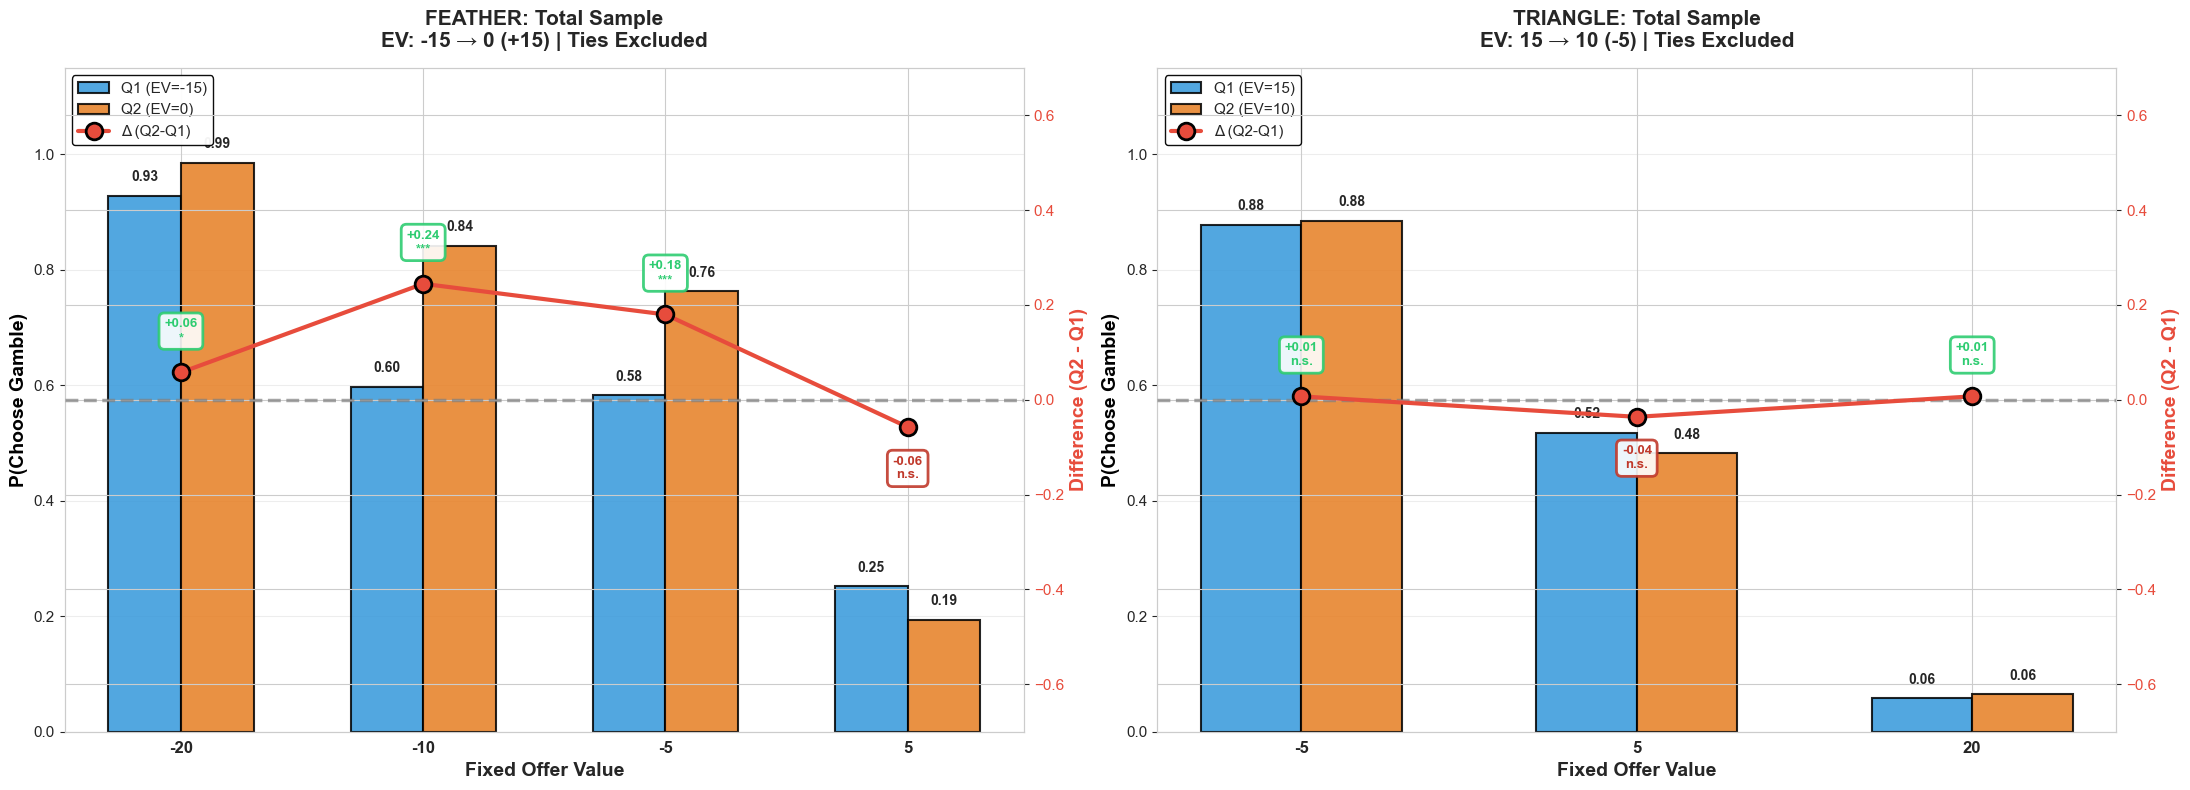

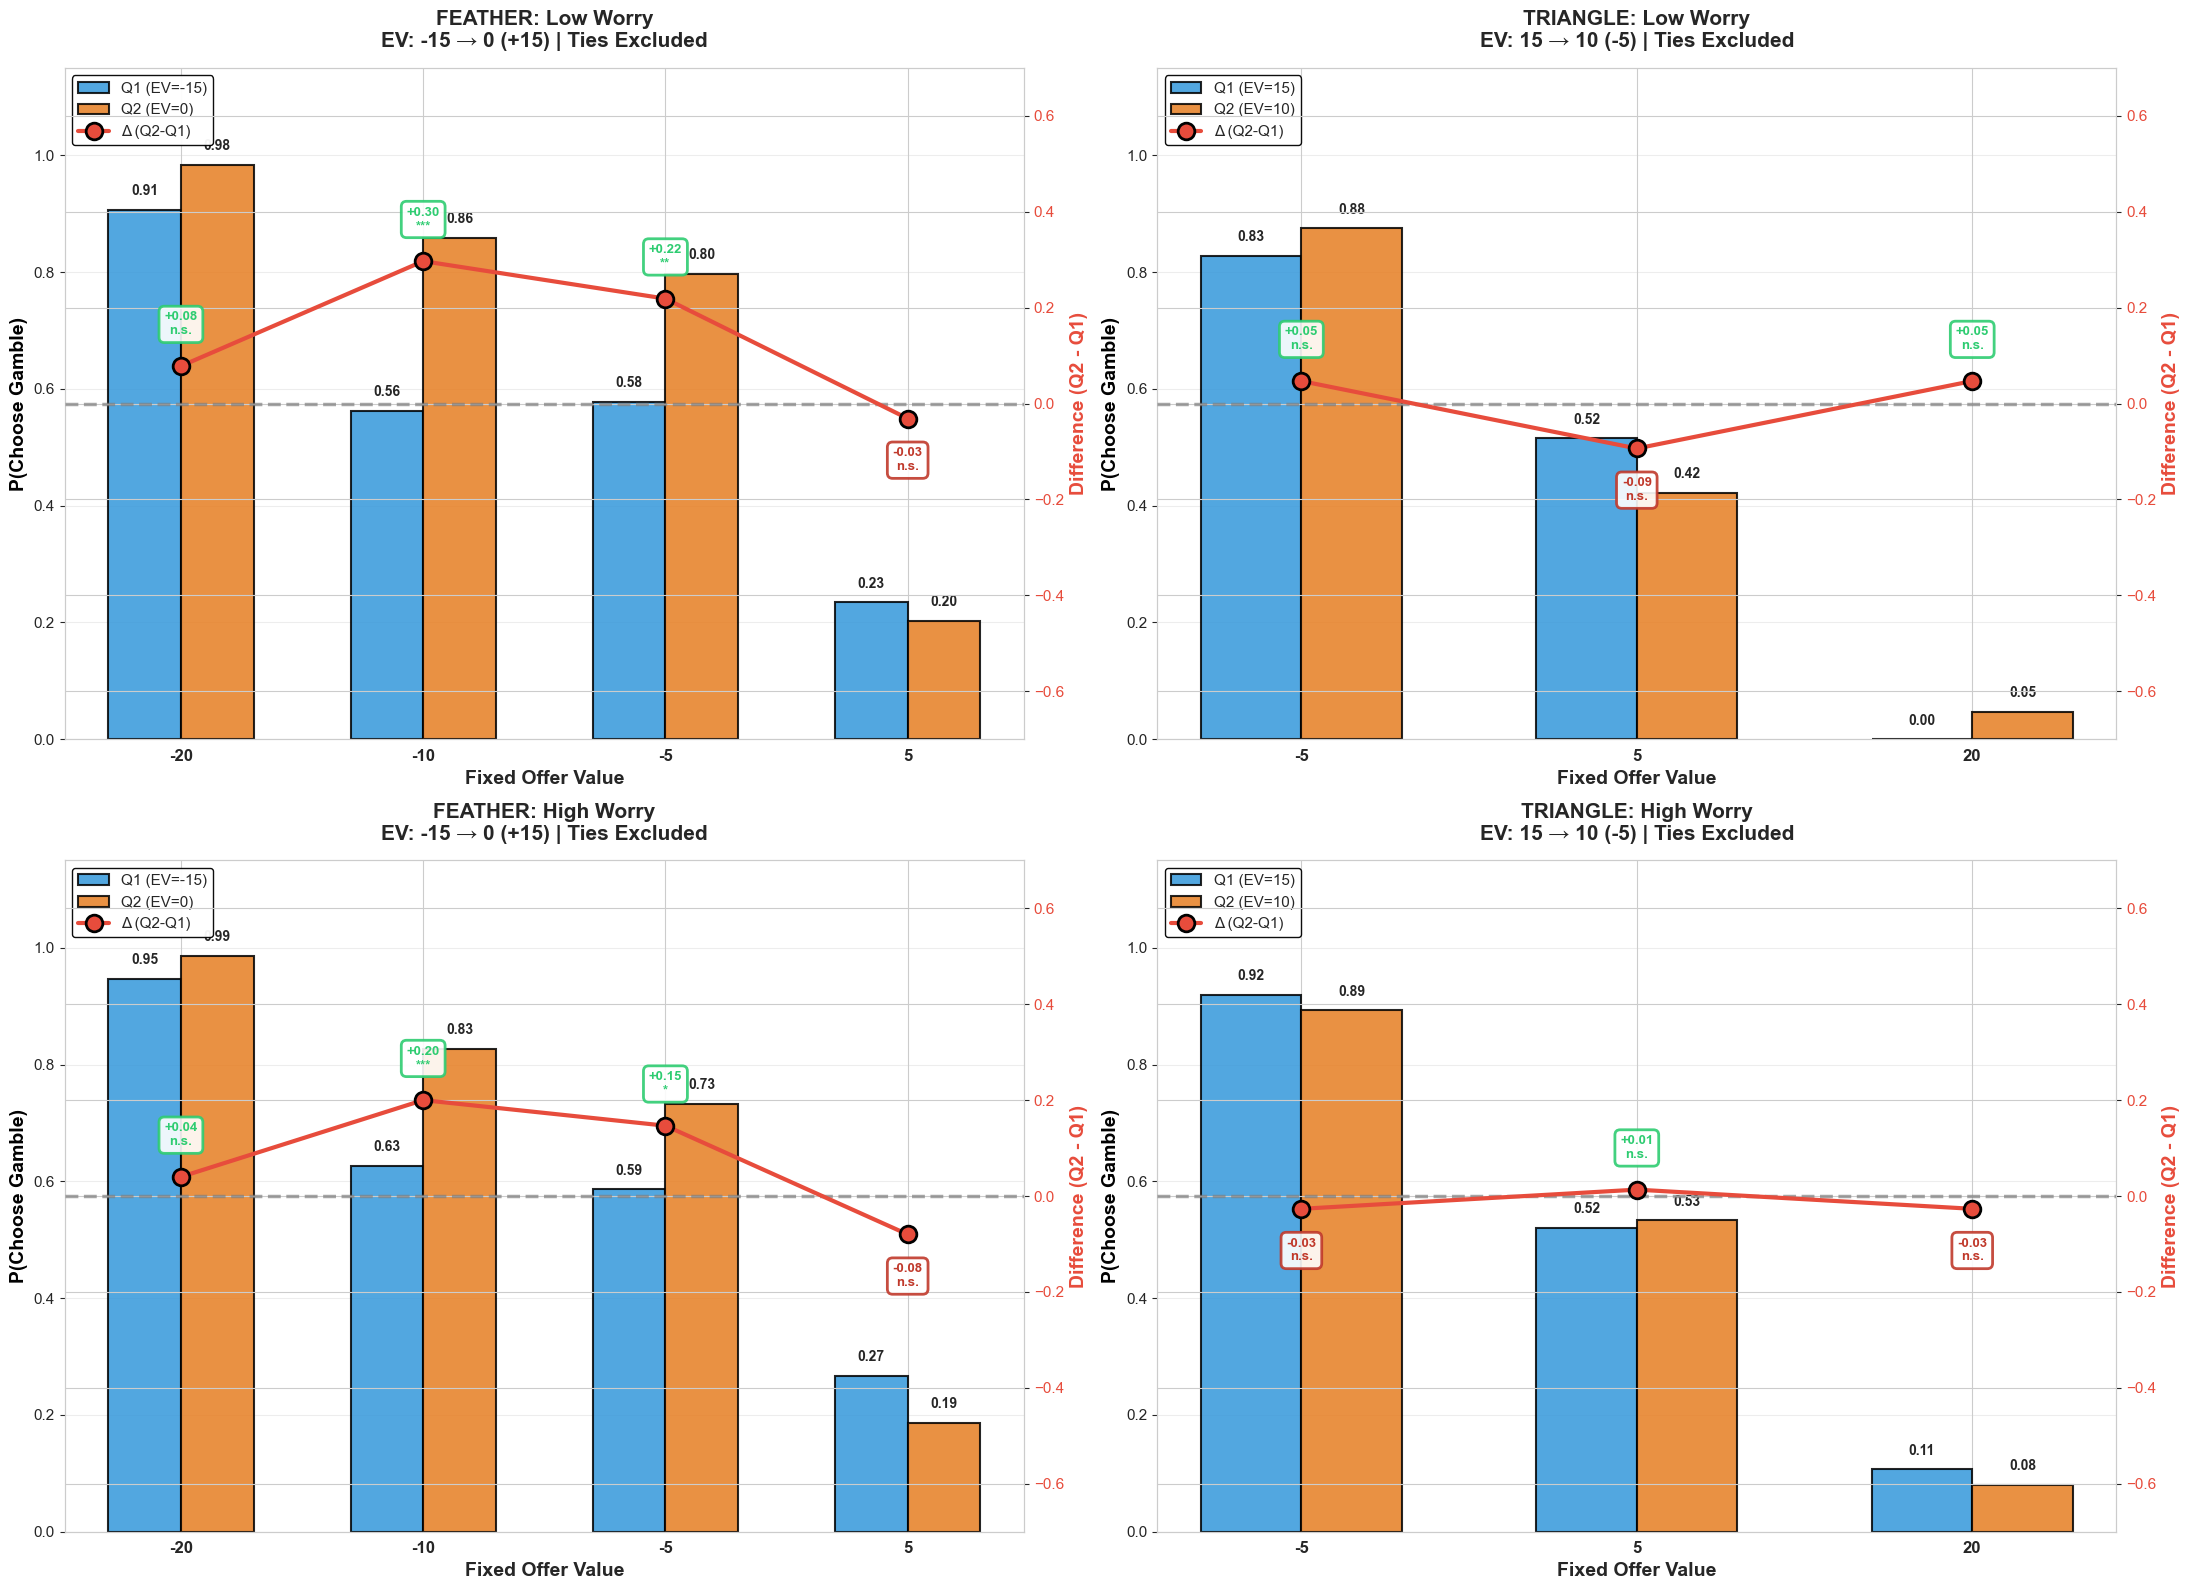

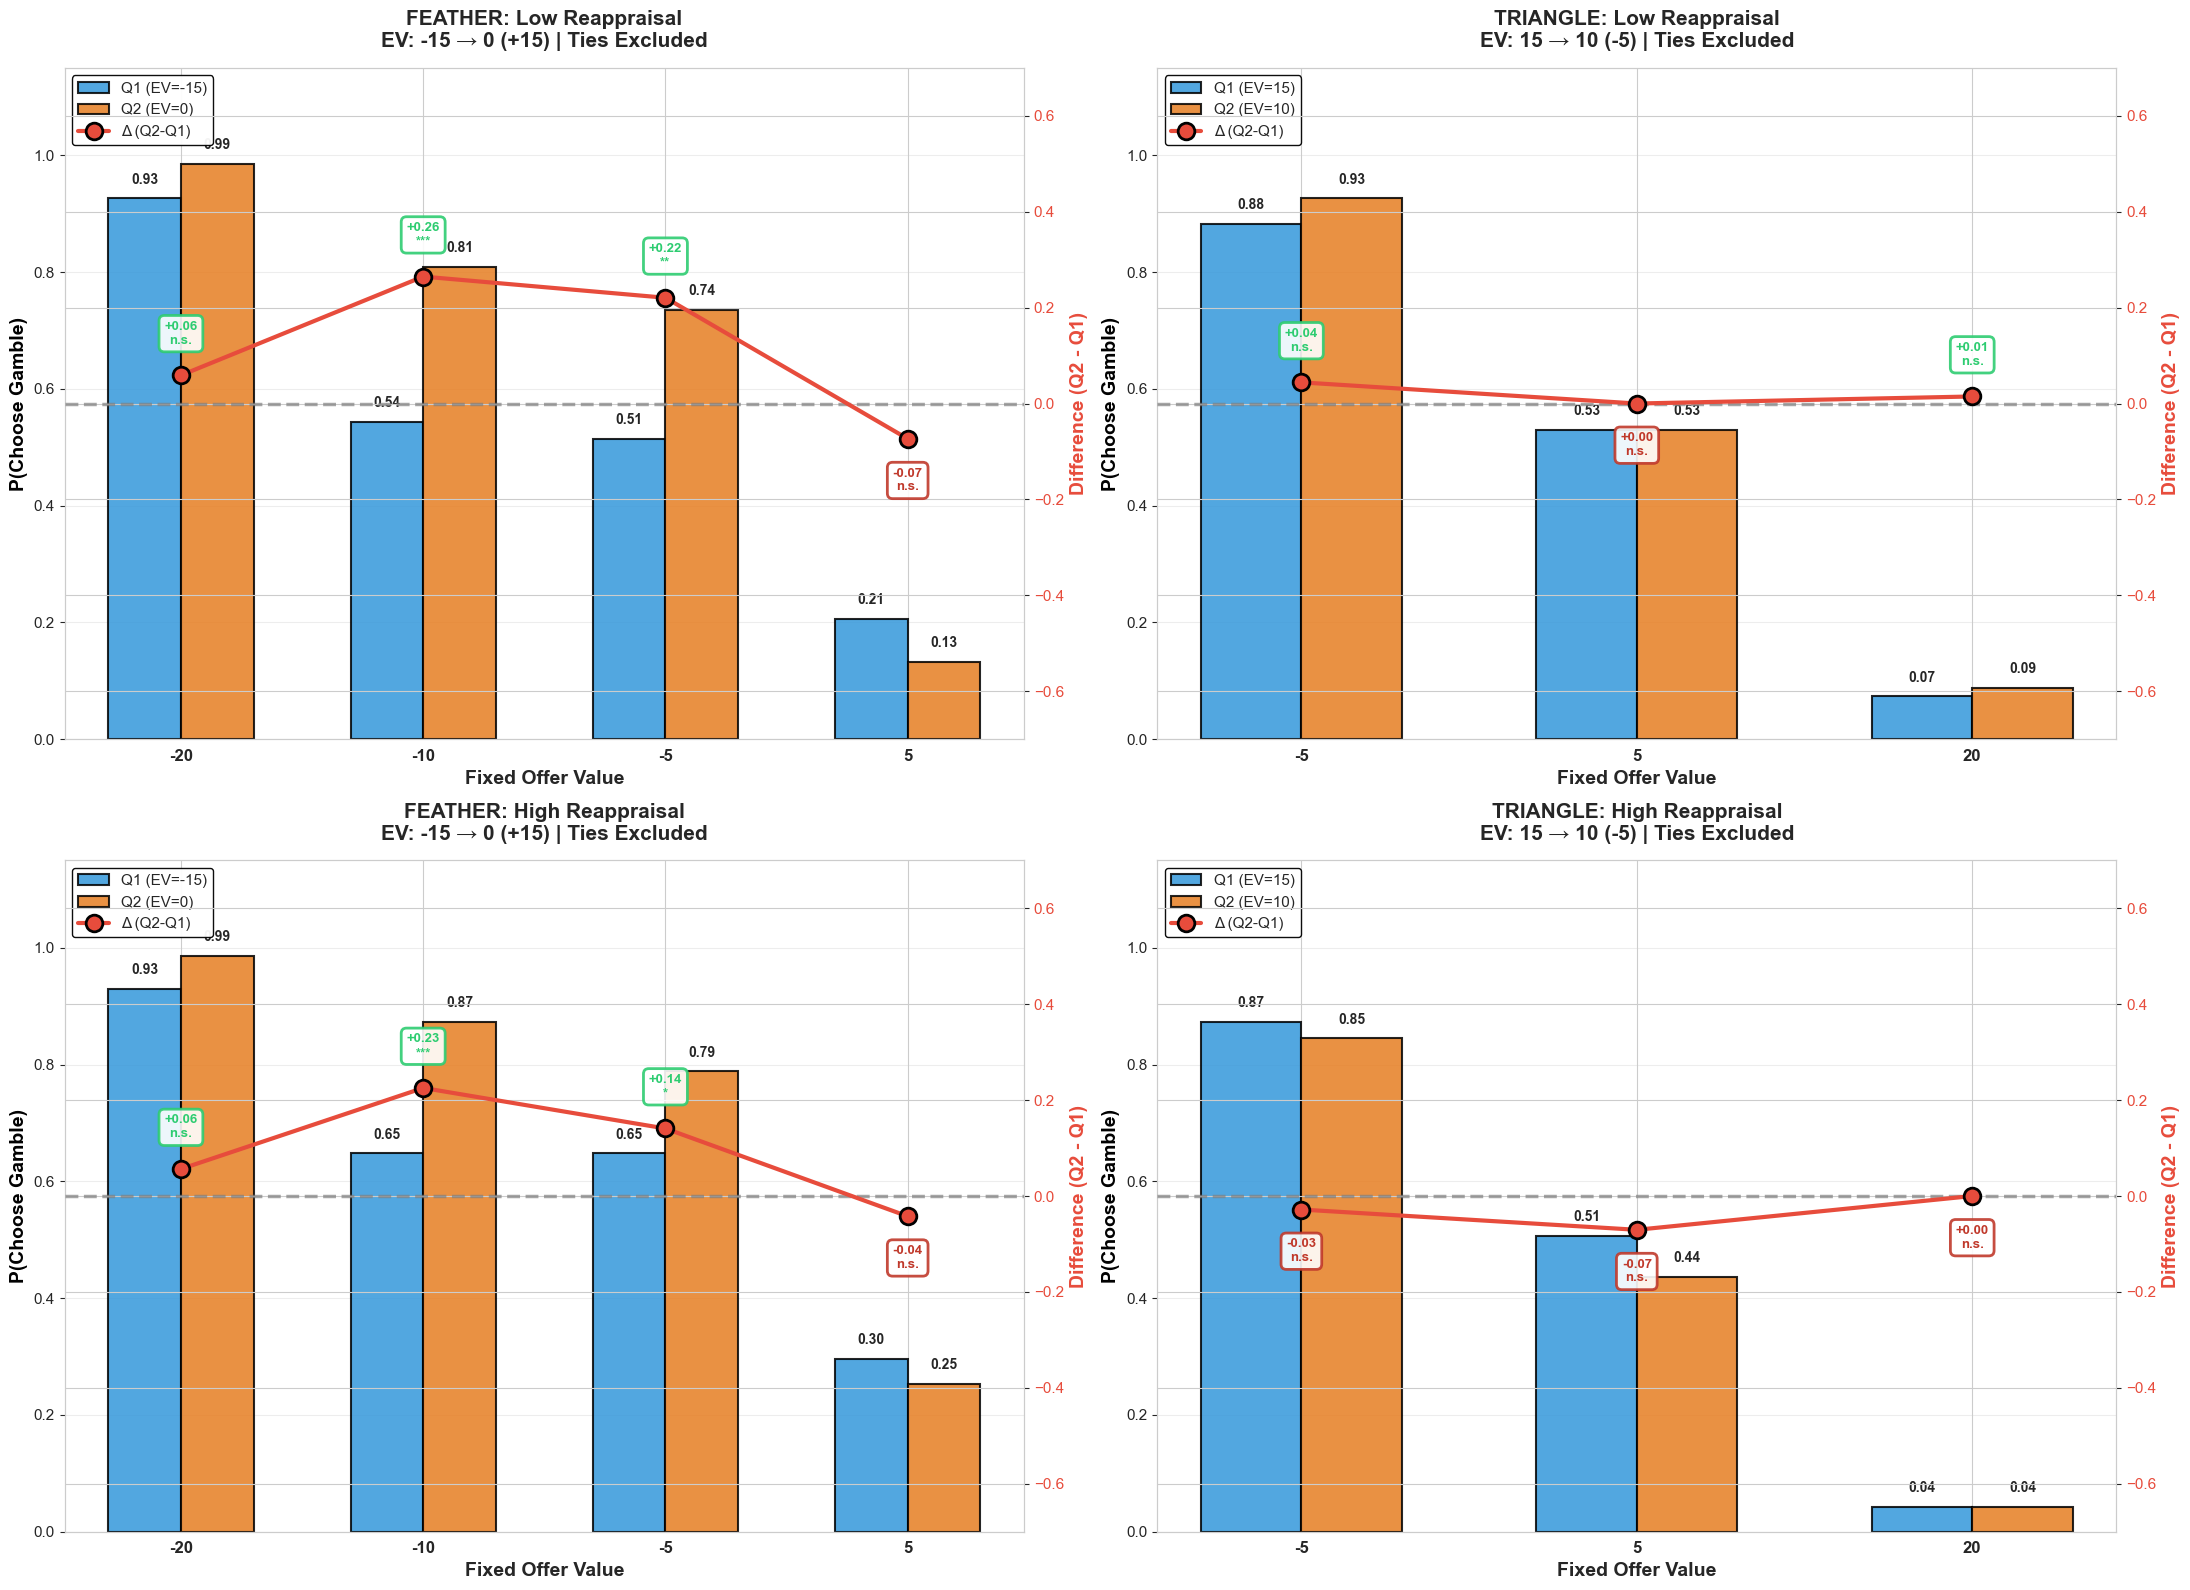

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_rel, ttest_1samp
import warnings
warnings.filterwarnings('ignore')


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 10)


# Load data
df = pd.read_csv('filtered_data.csv')
print(f"Loaded {len(df)} subjects")


# ============================================================================
# 1. CALCULATE SCORES (Anxiety & ERQ)
# ============================================================================
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
median_anx = df['Anxiety_Total'].median()
df['Anxiety_Group'] = df['Anxiety_Total'].apply(lambda x: 'High Worry' if x >= median_anx else 'Low Worry')


erq_cols = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
            'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']


if all(col in df.columns for col in erq_cols):
    df['ERQ_Reappraisal'] = df[erq_cols].sum(axis=1)
else:
    df['ERQ_Reappraisal'] = df.get('Survey_ERQ_Reappraisal_Score', np.nan)


median_erq = df['ERQ_Reappraisal'].median()
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(lambda x: 'High Reappraisal' if x >= median_erq else 'Low Reappraisal')


print(f"Median Anxiety: {median_anx:.2f}")
print(f"Median ERQ: {median_erq:.2f}")
print(f"Low Worry: n={sum(df['Anxiety_Group']=='Low Worry')}, High Worry: n={sum(df['Anxiety_Group']=='High Worry')}")
print(f"Low Reappraisal: n={sum(df['ERQ_Group']=='Low Reappraisal')}, High Reappraisal: n={sum(df['ERQ_Group']=='High Reappraisal')}")


# ============================================================================
# 2. PREPARE LONG FORMAT DATA (EXCLUDING TIES)
# ============================================================================
print("\n" + "="*90)
print("PREPARING DATA - EXCLUDING TIES WHERE GAMBLE EV = FIXED OFFER")
print("="*90)


# EV mapping
ev_map = {
    ('Feather', 1): -15,
    ('Feather', 2): 0,
    ('Triangle', 1): 15,
    ('Triangle', 2): 10
}


long_data = []
ties_excluded = {'Q1_Feather': 0, 'Q1_Triangle': 0, 'Q2_Feather': 0, 'Q2_Triangle': 0}


for idx, row in df.iterrows():
    subj_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anx_group = row['Anxiety_Group']
    erq = row['ERQ_Reappraisal']
    erq_group = row['ERQ_Group']


    for query_num in [1, 2]:
        for trial_num in range(1, 21):
            trial_col_prefix = f'Query_{query_num}_T{trial_num}'
            choice = row.get(f'{trial_col_prefix}_Choice', np.nan)
            state = row.get(f'{trial_col_prefix}_State', np.nan)
            fixed_offer = row.get(f'{trial_col_prefix}_FixedOffer', np.nan)


            if pd.isna(choice) or pd.isna(state) or pd.isna(fixed_offer):
                continue


            # Get gamble EV for this state and query
            gamble_ev = ev_map.get((state, query_num), None)


            # CRITICAL: Skip ties where gamble EV = fixed offer
            if gamble_ev == fixed_offer:
                ties_excluded[f'Q{query_num}_{state}'] += 1
                continue  # Don't include this trial


            chose_gamble = int(choice)


            long_data.append({
                'subject_id': subj_id,
                'Anxiety_Total': anxiety,
                'Anxiety_Group': anx_group,
                'ERQ_Reappraisal': erq,
                'ERQ_Group': erq_group,
                'query_num': query_num,
                'state': state,
                'fixed_offer': fixed_offer,
                'gamble_ev': gamble_ev,
                'chose_gamble': chose_gamble
            })


long_df = pd.DataFrame(long_data)
print(f"\nTotal trials INCLUDED (after excluding ties): {len(long_df)}")
print(f"\nTrials EXCLUDED due to ties (Gamble EV = Fixed Offer):")
for key, count in ties_excluded.items():
    print(f"  {key}: {count} trials excluded")


# ============================================================================
# 3. CALCULATE P(GAMBLE) WITH OPTIMALITY
# ============================================================================

def calculate_p_gamble_with_stats_and_optimality(data, state_name, group_name="Total Sample"):
    """Calculate P(Gamble) for Q1 and Q2 with OPTIMALITY indicators"""
    
    state_data = data[data['state'] == state_name].copy()
    
    # Get EVs
    ev_q1 = ev_map[(state_name, 1)]
    ev_q2 = ev_map[(state_name, 2)]
    
    # Q1
    q1_data = state_data[state_data['query_num'] == 1]
    q1_stats = q1_data.groupby('fixed_offer').agg(
        p_gamble=('chose_gamble', 'mean'),
        n_trials=('chose_gamble', 'count'),
        se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)) if len(x) > 1 else 0)
    ).reset_index()
    
    # Q2
    q2_data = state_data[state_data['query_num'] == 2]
    q2_stats = q2_data.groupby('fixed_offer').agg(
        p_gamble=('chose_gamble', 'mean'),
        n_trials=('chose_gamble', 'count'),
        se=('chose_gamble', lambda x: x.std() / np.sqrt(len(x)) if len(x) > 1 else 0)
    ).reset_index()
    
    # Merge
    merged = q1_stats.merge(q2_stats, on='fixed_offer', suffixes=('_q1', '_q2'), how='inner')
    merged['diff'] = merged['p_gamble_q2'] - merged['p_gamble_q1']
    
    # ★★★ ADD OPTIMALITY COLUMNS ★★★
    merged['optimal_q1'] = merged['fixed_offer'].apply(
        lambda x: 'GAMBLE' if ev_q1 > x else 'FIXED'
    )
    merged['optimal_q2'] = merged['fixed_offer'].apply(
        lambda x: 'GAMBLE' if ev_q2 > x else 'FIXED'
    )
    
    # Calculate optimality score (% doing optimal choice)
    merged['optimality_q1'] = merged.apply(
        lambda row: row['p_gamble_q1'] if row['optimal_q1'] == 'GAMBLE' 
                   else (1 - row['p_gamble_q1']),
        axis=1
    )
    merged['optimality_q2'] = merged.apply(
        lambda row: row['p_gamble_q2'] if row['optimal_q2'] == 'GAMBLE' 
                   else (1 - row['p_gamble_q2']),
        axis=1
    )
    
    # Print header
    print(f"\n{'='*110}")
    print(f"STATE: {state_name} | GROUP: {group_name}")
    print(f"Q1 EV = {ev_q1}, Q2 EV = {ev_q2} (EV Change = {ev_q2 - ev_q1:+d})")
    print(f"NOTE: Ties (EV = Offer) excluded from analysis")
    print(f"{'='*110}")
    
    # Enhanced header with optimality
    header = f"{'Offer':<8} {'Opt-Q1':<10} {'P(Q1)':<10} {'Opt-Q2':<10} {'P(Q2)':<10} "
    header += f"{'Diff':<10} {'t':<10} {'p-value':<12} {'Sig':<5} {'N':<6} {'Acc-Q1%':<9} {'Acc-Q2%':<9}"
    print(header)
    print("-" * 110)
    
    results = []
    for _, row in merged.iterrows():
        offer = row['fixed_offer']
        
        # Statistical test
        q1_subjects = q1_data[q1_data['fixed_offer'] == offer].groupby('subject_id')['chose_gamble'].mean()
        q2_subjects = q2_data[q2_data['fixed_offer'] == offer].groupby('subject_id')['chose_gamble'].mean()
        common_subjects = q1_subjects.index.intersection(q2_subjects.index)
        
        if len(common_subjects) > 1:
            q1_matched = q1_subjects.loc[common_subjects]
            q2_matched = q2_subjects.loc[common_subjects]
            t, p = ttest_rel(q1_matched, q2_matched)
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        else:
            t, p, sig = np.nan, np.nan, 'N/A'
        
        results.append({
            'fixed_offer': offer,
            'optimal_q1': row['optimal_q1'],
            'p_q1': row['p_gamble_q1'],
            'optimal_q2': row['optimal_q2'],
            'p_q2': row['p_gamble_q2'],
            'diff': row['diff'],
            'se_q1': row['se_q1'],
            'se_q2': row['se_q2'],
            't': t,
            'p': p,
            'sig': sig,
            'n': len(common_subjects) if len(common_subjects) > 1 else row['n_trials_q1'],
            'optimality_q1': row['optimality_q1'],
            'optimality_q2': row['optimality_q2']
        })
        
        # Print row with optimality
        print(f"{offer:<8.0f} {row['optimal_q1']:<10} {row['p_gamble_q1']:<10.3f} "
              f"{row['optimal_q2']:<10} {row['p_gamble_q2']:<10.3f} "
              f"{row['diff']:<10.3f} {t:<10.3f} {p:<12.6f} {sig:<5} "
              f"{len(common_subjects) if len(common_subjects) > 1 else row['n_trials_q1']:<6.0f} "
              f"{row['optimality_q1']*100:<9.1f} {row['optimality_q2']*100:<9.1f}")
    
    # Summary statistics
    results_df = pd.DataFrame(results)
    print(f"\n--- OPTIMALITY SUMMARY ---")
    print(f"Q1 Mean Optimality: {results_df['optimality_q1'].mean()*100:.1f}% (SD={results_df['optimality_q1'].std()*100:.1f}%)")
    print(f"Q2 Mean Optimality: {results_df['optimality_q2'].mean()*100:.1f}% (SD={results_df['optimality_q2'].std()*100:.1f}%)")
    improvement = (results_df['optimality_q2'].mean() - results_df['optimality_q1'].mean()) * 100
    print(f"Improvement: {improvement:+.1f}% {('***' if improvement > 10 else '**' if improvement > 5 else '*' if improvement > 2 else 'n.s.')}")
    
    results_df['state'] = state_name
    results_df['group'] = group_name
    results_df['ev_q1'] = ev_q1
    results_df['ev_q2'] = ev_q2
    
    return results_df


# ============================================================================
# SECTION 1: TOTAL SAMPLE ANALYSIS
# ============================================================================
print("\n" + "="*110)
print("SECTION 1: TOTAL SAMPLE - P(GAMBLE) WITH OPTIMALITY ANALYSIS")
print("="*110)

# ★★★ CHANGED: Now using the optimality function ★★★
feather_total = calculate_p_gamble_with_stats_and_optimality(long_df, 'Feather', "Total Sample")
triangle_total = calculate_p_gamble_with_stats_and_optimality(long_df, 'Triangle', "Total Sample")


# ============================================================================
# SECTION 2: WORRY GROUPS ANALYSIS
# ============================================================================
print("\n" + "="*110)
print("SECTION 2: BY WORRY GROUPS")
print("="*110)

results_by_worry = {}
for worry_group in ['Low Worry', 'High Worry']:
    group_data = long_df[long_df['Anxiety_Group'] == worry_group]
    # ★★★ CHANGED: Now using the optimality function ★★★
    feather_worry = calculate_p_gamble_with_stats_and_optimality(group_data, 'Feather', worry_group)
    triangle_worry = calculate_p_gamble_with_stats_and_optimality(group_data, 'Triangle', worry_group)
    results_by_worry[worry_group] = {'feather': feather_worry, 'triangle': triangle_worry}


# ============================================================================
# SECTION 3: ERQ GROUPS ANALYSIS
# ============================================================================
print("\n" + "="*110)
print("SECTION 3: BY ERQ REAPPRAISAL GROUPS")
print("="*110)

results_by_erq = {}
for erq_group in ['Low Reappraisal', 'High Reappraisal']:
    group_data = long_df[long_df['ERQ_Group'] == erq_group]
    # ★★★ CHANGED: Now using the optimality function ★★★
    feather_erq = calculate_p_gamble_with_stats_and_optimality(group_data, 'Feather', erq_group)
    triangle_erq = calculate_p_gamble_with_stats_and_optimality(group_data, 'Triangle', erq_group)
    results_by_erq[erq_group] = {'feather': feather_erq, 'triangle': triangle_erq}


# ============================================================================
# ENHANCED VISUALIZATIONS (DUAL AXIS WITH BARS + LINE)
# ============================================================================

def plot_enhanced_comparison(ax, results_df, state_name, title_suffix=""):
    """Enhanced plot with Q1/Q2 bars and difference line on dual axis"""

    results_sorted = results_df.sort_values('fixed_offer')
    x_pos = np.arange(len(results_sorted))
    width = 0.30

    ev_q1 = results_sorted['ev_q1'].iloc[0]
    ev_q2 = results_sorted['ev_q2'].iloc[0]

    # LEFT AXIS: Q1 and Q2 bars
    bars1 = ax.bar(x_pos - width/2, results_sorted['p_q1'], width,
                   label=f'Q1 (EV={ev_q1})', color='#3498db', alpha=0.85, 
                   edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x_pos + width/2, results_sorted['p_q2'], width,
                   label=f'Q2 (EV={ev_q2})', color='#e67e22', alpha=0.85,
                   edgecolor='black', linewidth=1.5)

    # Add exact values on bars
    for bar, val in zip(bars1, results_sorted['p_q1']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    for bar, val in zip(bars2, results_sorted['p_q2']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # RIGHT AXIS: Difference line
    ax2 = ax.twinx()
    line = ax2.plot(x_pos, results_sorted['diff'], 'o-', linewidth=3, 
                    markersize=12, color='#e74c3c', markeredgecolor='black', 
                    markeredgewidth=2, label='Δ (Q2-Q1)', zorder=10)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=2.5, alpha=0.7, zorder=5)

    # Add difference values and significance on line
    for i, (x, diff, sig) in enumerate(zip(x_pos, results_sorted['diff'], results_sorted['sig'])):
        # Determine color and position
        color = '#2ecc71' if diff > 0 else '#c0392b'
        y_offset = 0.06 if diff > 0 else -0.06
        v_align = 'bottom' if diff > 0 else 'top'

        # Show diff value and significance
        ax2.text(x, diff + y_offset, f'{diff:+.2f}\n{sig}', 
                ha='center', va=v_align, fontsize=9.5, fontweight='bold', 
                color=color, bbox=dict(boxstyle='round,pad=0.4', 
                facecolor='white', edgecolor=color, linewidth=2, alpha=0.9))

    # Formatting LEFT AXIS
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{int(fo)}" for fo in results_sorted['fixed_offer']], 
                       fontsize=12, fontweight='bold')
    ax.set_xlabel('Fixed Offer Value', fontsize=14, fontweight='bold')
    ax.set_ylabel('P(Choose Gamble)', fontsize=14, fontweight='bold', color='black')
    ax.set_ylim([0, 1.15])
    ax.tick_params(axis='y', labelsize=11)

    # Formatting RIGHT AXIS
    ax2.set_ylabel('Difference (Q2 - Q1)', fontsize=14, fontweight='bold', color='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#e74c3c', labelsize=11)
    ax2.set_ylim([-0.7, 0.7])

    # Title
    ev_change = ev_q2 - ev_q1
    ax.set_title(f'{state_name}: {title_suffix}\nEV: {ev_q1} → {ev_q2} ({ev_change:+d}) | Ties Excluded', 
                fontsize=15, fontweight='bold', pad=15)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
             fontsize=11, framealpha=0.95, edgecolor='black')

    ax.grid(axis='y', alpha=0.35, linewidth=0.8)


# ============================================================================
# FIGURE 1: TOTAL SAMPLE
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
plot_enhanced_comparison(axes[0], feather_total, 'FEATHER', 'Total Sample')
plot_enhanced_comparison(axes[1], triangle_total, 'TRIANGLE', 'Total Sample')
plt.tight_layout()
plt.savefig('p_gamble_enhanced_total.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: p_gamble_enhanced_total.png")


# ============================================================================
# FIGURE 2: WORRY GROUPS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plot_enhanced_comparison(axes[0, 0], results_by_worry['Low Worry']['feather'], 'FEATHER', 'Low Worry')
plot_enhanced_comparison(axes[0, 1], results_by_worry['Low Worry']['triangle'], 'TRIANGLE', 'Low Worry')
plot_enhanced_comparison(axes[1, 0], results_by_worry['High Worry']['feather'], 'FEATHER', 'High Worry')
plot_enhanced_comparison(axes[1, 1], results_by_worry['High Worry']['triangle'], 'TRIANGLE', 'High Worry')
plt.tight_layout()
plt.savefig('p_gamble_enhanced_worry.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_enhanced_worry.png")


# ============================================================================
# FIGURE 3: ERQ GROUPS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plot_enhanced_comparison(axes[0, 0], results_by_erq['Low Reappraisal']['feather'], 'FEATHER', 'Low Reappraisal')
plot_enhanced_comparison(axes[0, 1], results_by_erq['Low Reappraisal']['triangle'], 'TRIANGLE', 'Low Reappraisal')
plot_enhanced_comparison(axes[1, 0], results_by_erq['High Reappraisal']['feather'], 'FEATHER', 'High Reappraisal')
plot_enhanced_comparison(axes[1, 1], results_by_erq['High Reappraisal']['triangle'], 'TRIANGLE', 'High Reappraisal')
plt.tight_layout()
plt.savefig('p_gamble_enhanced_erq.png', dpi=300, bbox_inches='tight')
print("✓ Saved: p_gamble_enhanced_erq.png")


print("\n" + "="*90)
print("ANALYSIS COMPLETE WITH OPTIMALITY!")
print("="*90)
print("Generated 3 figures with ENHANCED visuals:")
print("  1. p_gamble_enhanced_total.png (2 panels: Feather, Triangle)")
print("  2. p_gamble_enhanced_worry.png (4 panels: Low/High Worry × Feather/Triangle)")
print("  3. p_gamble_enhanced_erq.png (4 panels: Low/High ERQ × Feather/Triangle)")
print("\nEnhanced features:")
print("  ✓ Side-by-side Q1 (blue) and Q2 (orange) bars with exact values")
print("  ✓ Difference line (red) on separate axis with exact values")
print("  ✓ Color-coded significance markers (green=increase, red=decrease)")
print("  ✓ EV information clearly shown in titles")
print("  ✓ Ties where Gamble EV = Fixed Offer EXCLUDED")
print("  ✓ OPTIMALITY METRICS showing model-free → model-based transition")
print("="*90)


---
# Section: RT DISTRIBUTIONS BY TRAIT SCORES (Spearman Correlations)

REACTION TIME ANALYSIS

Mean RT: M=3868ms, SD=1697ms
Sample size: n=137

CORRELATIONS: RT vs Individual Differences

RT vs WORRY:
  Pearson:  r =  0.184, p = 0.0312 *  
  Spearman: r_s =  0.168, p = 0.0502    

RT vs REAPPRAISAL:
  Pearson:  r = -0.113, p = 0.1884    
  Spearman: r_s = -0.140, p = 0.1031    

MEDIAN SPLIT COMPARISONS

WORRY:
  Low Worry:  M=3564ms, SD=1443ms (n=73)
  High Worry: M=4215ms, SD=1900ms (n=64)
  Independent t-test: t=2.273, p=0.0246 *, Cohen's d=0.386
  Mann-Whitney U: U=2805, p=0.0433

REAPPRAISAL:
  Low ERQ-R:  M=4113ms, SD=1821ms (n=79)
  High ERQ-R: M=3534ms, SD=1463ms (n=58)
  Independent t-test: t=-1.993, p=0.0482 *, Cohen's d=-0.350
  Mann-Whitney U: U=1842, p=0.0507

Saved: rt_analysis.png


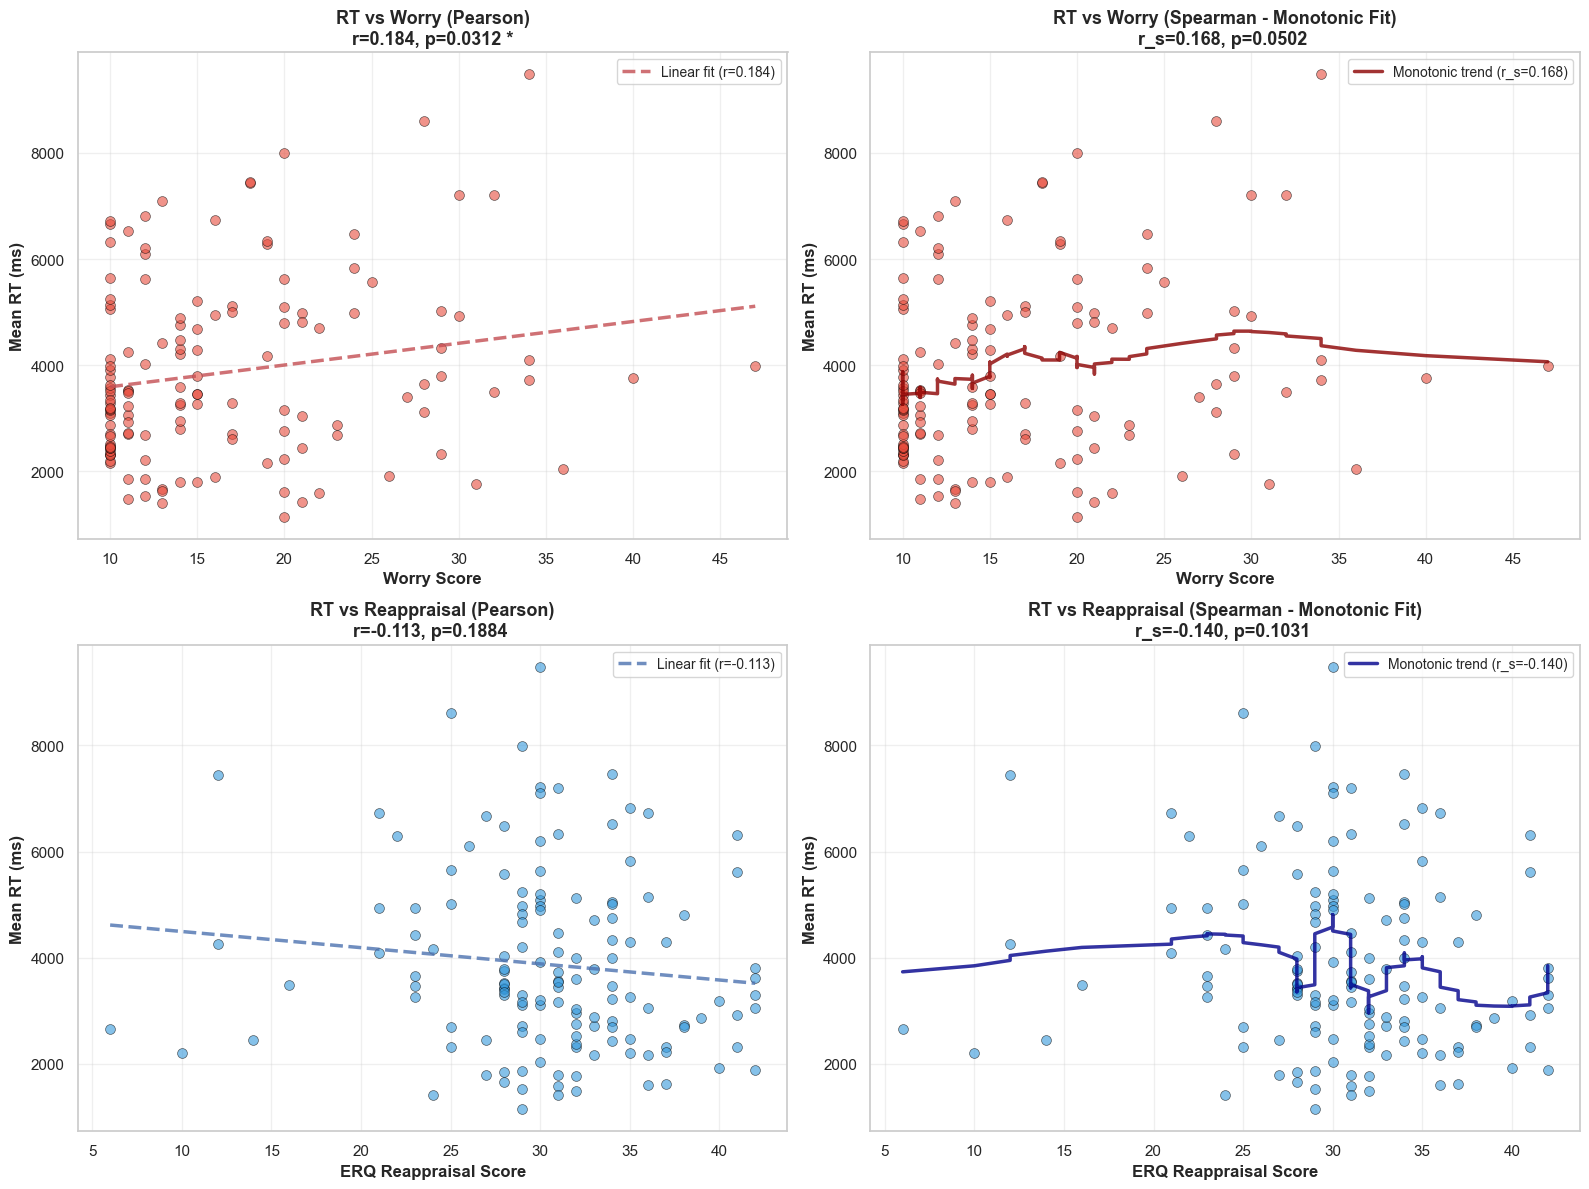

In [32]:
# ==============================================================================
# REACTION TIME ANALYSIS
# ==============================================================================

print("="*80)
print("REACTION TIME ANALYSIS")
print("="*80)

rt_data = []
for idx, row in df.iterrows():
    subj_id = row['prolific_id']
    worry = row['Anxiety_Total']  # FIXED: Column name
    reappraisal = row['ERQ_Reappraisal']  # FIXED: Column name
    
    for qnum in [1, 2]:
        for t in range(1, 21):
            rt_col = f'Query_{qnum}_T{t}_RT'  # FIXED: Added underscores
            
            if rt_col in df.columns and pd.notna(row[rt_col]):
                rt_data.append({
                    'prolific_id': subj_id,
                    'RT': row[rt_col],
                    'Worry': worry,
                    'Reappraisal': reappraisal
                })

rt_df = pd.DataFrame(rt_data)

# Calculate mean RT per subject
subject_rts = rt_df.groupby('prolific_id').agg({
    'RT': 'mean',
    'Worry': 'first',
    'Reappraisal': 'first'
}).reset_index()

print(f"\nMean RT: M={subject_rts['RT'].mean():.0f}ms, SD={subject_rts['RT'].std():.0f}ms")
print(f"Sample size: n={len(subject_rts)}")

# ==============================================================================
# CORRELATIONS: PEARSON & SPEARMAN
# ==============================================================================

print("\n" + "="*80)
print("CORRELATIONS: RT vs Individual Differences")
print("="*80)

from scipy.stats import pearsonr, spearmanr

# RT vs Worry
r_worry_p, p_worry_p = pearsonr(subject_rts['RT'], subject_rts['Worry'])
r_worry_s, p_worry_s = spearmanr(subject_rts['RT'], subject_rts['Worry'])
sig_worry_p = '***' if p_worry_p < 0.001 else '**' if p_worry_p < 0.01 else '*' if p_worry_p < 0.05 else ''
sig_worry_s = '***' if p_worry_s < 0.001 else '**' if p_worry_s < 0.01 else '*' if p_worry_s < 0.05 else ''

print(f"\nRT vs WORRY:")
print(f"  Pearson:  r = {r_worry_p:6.3f}, p = {p_worry_p:.4f} {sig_worry_p:3s}")
print(f"  Spearman: r_s = {r_worry_s:6.3f}, p = {p_worry_s:.4f} {sig_worry_s:3s}")

# RT vs Reappraisal
r_reapp_p, p_reapp_p = pearsonr(subject_rts['RT'], subject_rts['Reappraisal'])
r_reapp_s, p_reapp_s = spearmanr(subject_rts['RT'], subject_rts['Reappraisal'])
sig_reapp_p = '***' if p_reapp_p < 0.001 else '**' if p_reapp_p < 0.01 else '*' if p_reapp_p < 0.05 else ''
sig_reapp_s = '***' if p_reapp_s < 0.001 else '**' if p_reapp_s < 0.01 else '*' if p_reapp_s < 0.05 else ''

print(f"\nRT vs REAPPRAISAL:")
print(f"  Pearson:  r = {r_reapp_p:6.3f}, p = {p_reapp_p:.4f} {sig_reapp_p:3s}")
print(f"  Spearman: r_s = {r_reapp_s:6.3f}, p = {p_reapp_s:.4f} {sig_reapp_s:3s}")

# ==============================================================================
# MEDIAN SPLIT ANALYSIS
# ==============================================================================

print("\n" + "="*80)
print("MEDIAN SPLIT COMPARISONS")
print("="*80)

from scipy.stats import mannwhitneyu, ttest_ind

# Worry groups
median_worry = subject_rts['Worry'].median()
high_worry_rt = subject_rts[subject_rts['Worry'] > median_worry]['RT']
low_worry_rt = subject_rts[subject_rts['Worry'] <= median_worry]['RT']

# Parametric (t-test) and Non-parametric (Mann-Whitney)
t_worry, p_worry_t = ttest_ind(high_worry_rt, low_worry_rt)
U_worry, p_worry_u = mannwhitneyu(high_worry_rt, low_worry_rt, alternative='two-sided')
d_worry = (high_worry_rt.mean() - low_worry_rt.mean()) / np.sqrt((high_worry_rt.std()**2 + low_worry_rt.std()**2) / 2)
sig_worry_t = '***' if p_worry_t < 0.001 else '**' if p_worry_t < 0.01 else '*' if p_worry_t < 0.05 else ''

print(f"\nWORRY:")
print(f"  Low Worry:  M={low_worry_rt.mean():.0f}ms, SD={low_worry_rt.std():.0f}ms (n={len(low_worry_rt)})")
print(f"  High Worry: M={high_worry_rt.mean():.0f}ms, SD={high_worry_rt.std():.0f}ms (n={len(high_worry_rt)})")
print(f"  Independent t-test: t={t_worry:.3f}, p={p_worry_t:.4f} {sig_worry_t}, Cohen's d={d_worry:.3f}")
print(f"  Mann-Whitney U: U={U_worry:.0f}, p={p_worry_u:.4f}")

# Reappraisal groups
median_reapp = subject_rts['Reappraisal'].median()
high_reapp_rt = subject_rts[subject_rts['Reappraisal'] > median_reapp]['RT']
low_reapp_rt = subject_rts[subject_rts['Reappraisal'] <= median_reapp]['RT']

t_reapp, p_reapp_t = ttest_ind(high_reapp_rt, low_reapp_rt)
U_reapp, p_reapp_u = mannwhitneyu(high_reapp_rt, low_reapp_rt, alternative='two-sided')
d_reapp = (high_reapp_rt.mean() - low_reapp_rt.mean()) / np.sqrt((high_reapp_rt.std()**2 + low_reapp_rt.std()**2) / 2)
sig_reapp_t = '***' if p_reapp_t < 0.001 else '**' if p_reapp_t < 0.01 else '*' if p_reapp_t < 0.05 else ''

print(f"\nREAPPRAISAL:")
print(f"  Low ERQ-R:  M={low_reapp_rt.mean():.0f}ms, SD={low_reapp_rt.std():.0f}ms (n={len(low_reapp_rt)})")
print(f"  High ERQ-R: M={high_reapp_rt.mean():.0f}ms, SD={high_reapp_rt.std():.0f}ms (n={len(high_reapp_rt)})")
print(f"  Independent t-test: t={t_reapp:.3f}, p={p_reapp_t:.4f} {sig_reapp_t}, Cohen's d={d_reapp:.3f}")
print(f"  Mann-Whitney U: U={U_reapp:.0f}, p={p_reapp_u:.4f}")

# ==============================================================================
# VISUALIZATION
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- PANEL A: RT vs Worry (PEARSON) ---
ax = axes[0, 0]
ax.scatter(subject_rts['Worry'], subject_rts['RT'], alpha=0.6, s=50, color='#e74c3c', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Worry Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean RT (ms)', fontsize=12, fontweight='bold')
ax.set_title(f'RT vs Worry (Pearson)\nr={r_worry_p:.3f}, p={p_worry_p:.4f} {sig_worry_p}', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Linear regression line (Pearson)
slope, intercept, _, _, _ = linregress(subject_rts['Worry'], subject_rts['RT'])
x_line = np.linspace(subject_rts['Worry'].min(), subject_rts['Worry'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r--', linewidth=2.5, alpha=0.8, label=f'Linear fit (r={r_worry_p:.3f})')
ax.legend(loc='best', fontsize=10)

# --- PANEL B: RT vs Worry (SPEARMAN with RANK OVERLAY) ---
ax = axes[0, 1]
# Plot with ranks for Spearman visualization
worry_ranks = subject_rts['Worry'].rank()
rt_ranks = subject_rts['RT'].rank()
ax.scatter(subject_rts['Worry'], subject_rts['RT'], alpha=0.6, s=50, color='#e74c3c', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Worry Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean RT (ms)', fontsize=12, fontweight='bold')
ax.set_title(f'RT vs Worry (Spearman - Monotonic Fit)\nr_s={r_worry_s:.3f}, p={p_worry_s:.4f} {sig_worry_s}', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Lowess smoothing for Spearman (shows monotonic relationship)
from scipy.signal import savgol_filter
sorted_idx = np.argsort(subject_rts['Worry'])
x_sorted = subject_rts['Worry'].values[sorted_idx]
y_sorted = subject_rts['RT'].values[sorted_idx]
if len(x_sorted) > 10:
    window = min(len(x_sorted) // 3 * 2 + 1, 51)  # Must be odd
    if window >= 5:
        y_smooth = savgol_filter(y_sorted, window, 3)
        ax.plot(x_sorted, y_smooth, color='darkred', linewidth=2.5, alpha=0.8, label=f'Monotonic trend (r_s={r_worry_s:.3f})')
ax.legend(loc='best', fontsize=10)

# --- PANEL C: RT vs Reappraisal (PEARSON) ---
ax = axes[1, 0]
ax.scatter(subject_rts['Reappraisal'], subject_rts['RT'], alpha=0.6, s=50, color='#3498db', edgecolors='black', linewidth=0.5)
ax.set_xlabel('ERQ Reappraisal Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean RT (ms)', fontsize=12, fontweight='bold')
ax.set_title(f'RT vs Reappraisal (Pearson)\nr={r_reapp_p:.3f}, p={p_reapp_p:.4f} {sig_reapp_p}', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Linear regression line (Pearson)
slope, intercept, _, _, _ = linregress(subject_rts['Reappraisal'], subject_rts['RT'])
x_line = np.linspace(subject_rts['Reappraisal'].min(), subject_rts['Reappraisal'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'b--', linewidth=2.5, alpha=0.8, label=f'Linear fit (r={r_reapp_p:.3f})')
ax.legend(loc='best', fontsize=10)

# --- PANEL D: RT vs Reappraisal (SPEARMAN with MONOTONIC OVERLAY) ---
ax = axes[1, 1]
ax.scatter(subject_rts['Reappraisal'], subject_rts['RT'], alpha=0.6, s=50, color='#3498db', edgecolors='black', linewidth=0.5)
ax.set_xlabel('ERQ Reappraisal Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean RT (ms)', fontsize=12, fontweight='bold')
ax.set_title(f'RT vs Reappraisal (Spearman - Monotonic Fit)\nr_s={r_reapp_s:.3f}, p={p_reapp_s:.4f} {sig_reapp_s}', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Lowess smoothing for Spearman
sorted_idx = np.argsort(subject_rts['Reappraisal'])
x_sorted = subject_rts['Reappraisal'].values[sorted_idx]
y_sorted = subject_rts['RT'].values[sorted_idx]
if len(x_sorted) > 10:
    window = min(len(x_sorted) // 3 * 2 + 1, 51)
    if window >= 5:
        y_smooth = savgol_filter(y_sorted, window, 3)
        ax.plot(x_sorted, y_smooth, color='darkblue', linewidth=2.5, alpha=0.8, label=f'Monotonic trend (r_s={r_reapp_s:.3f})')
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('rt_analysis.png', dpi=300, bbox_inches='tight')
print("\n" + "="*80)
print("Saved: rt_analysis.png")
print("="*80)
plt.show()



---
# COMPREHENSIVE ANALYSIS: COGNITIVE VS BEHAVIORAL FLEXIBILITY
# Rating Accuracy vs Choice Accuracy across Individual Differences

RATING-CHOICE CONSISTENCY ANALYSIS
Do ratings predict choices?

RATING TRAJECTORIES ACROSS TIME

FEATHER Ratings (Population Means):
  R1 (After MF Learning):        M=   5.40, SD=  5.07
  R2 (After Revaluation 1):      M=  -0.18, SD= 13.64
  R3 (After Revaluation 2):      M=   1.37, SD= 10.59
  Change R1→R2:                  M=  -5.58, SD= 12.80
  Change R2→R3:                  M=   1.55, SD= 12.23
  Total Change R1→R3:            M=  -4.03, SD= 11.18

TRIANGLE Ratings (Population Means):
  R1 (After MF Learning):        M=  -4.42, SD=  4.86
  R2 (After Revaluation 1):      M=   0.18, SD= 13.67
  R3 (After Revaluation 2):      M=   1.98, SD= 13.04
  Change R1→R2:                  M=   4.60, SD= 14.41
  Change R2→R3:                  M=   1.80, SD= 13.87
  Total Change R1→R3:            M=   6.40, SD= 14.04

True Expected Values (MB):
  FEATHER:  R1 = +5 (MF), R2 = -15 (MB after Rev1), R3 = 0 (MB after Rev2)
  TRIANGLE: R1 = -5 (MF), R2 = +15 (MB after Rev1), R3 = +10 (MB after Rev2)



C:\Users\adip1\AppData\Local\Temp\ipykernel_61772\3203758332.py:373: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=consistency_by_query, x='Query', y='Consistency', ax=ax5,
C:\Users\adip1\AppData\Local\Temp\ipykernel_61772\3203758332.py:386: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=state_comparison, x='State', y='Consistency', ax=ax6,



✓ Saved: rating_choice_consistency_comprehensive.png


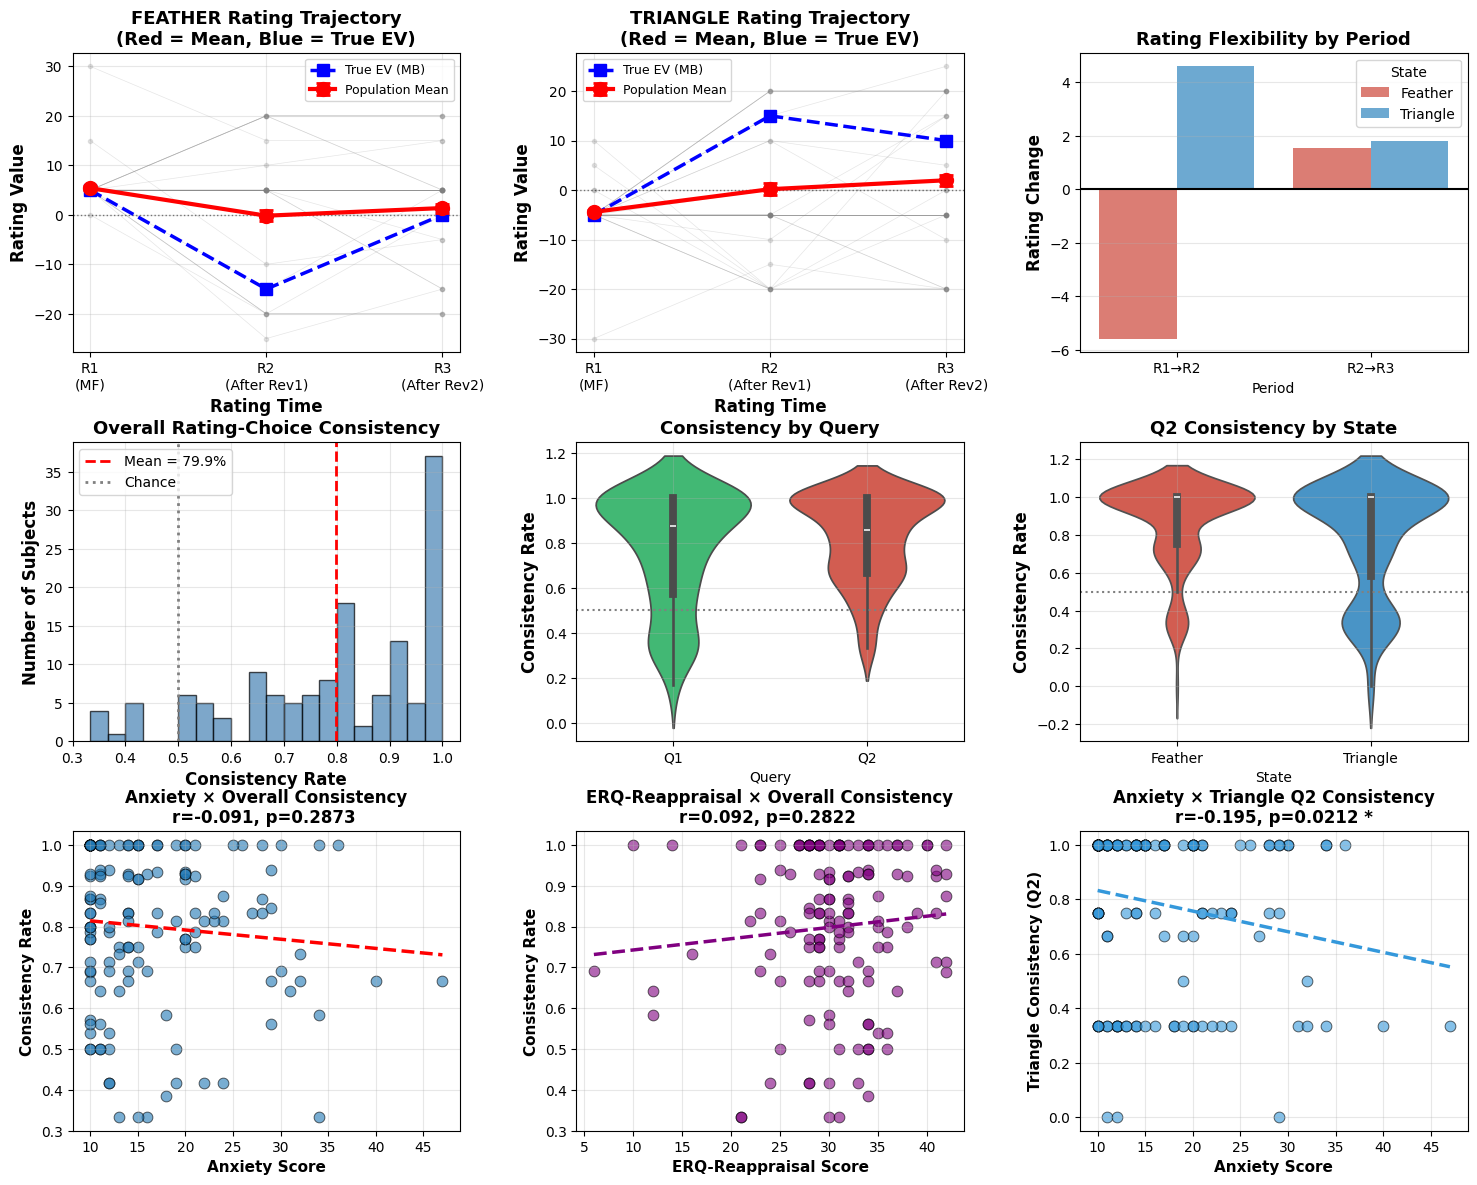

✓ Saved: filtered_data_with_consistency.csv

ANALYSIS COMPLETE!


In [6]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('filtered_data.csv')

print("="*80)
print("RATING-CHOICE CONSISTENCY ANALYSIS")
print("Do ratings predict choices?")
print("="*80)

# =============================================================================
# STEP 0: Calculate Rating Flexibility Metrics
# =============================================================================

print("\n" + "="*80)
print("RATING TRAJECTORIES ACROSS TIME")
print("="*80)

# Calculate rating changes
df['R1_R2_Feather_Change'] = df['Rating_2_Feather_Val'] - df['Rating_1_Feather_Val']
df['R2_R3_Feather_Change'] = df['Rating_3_Feather_Val'] - df['Rating_2_Feather_Val']
df['R1_R3_Feather_Change'] = df['Rating_3_Feather_Val'] - df['Rating_1_Feather_Val']

df['R1_R2_Triangle_Change'] = df['Rating_2_Triangle_Val'] - df['Rating_1_Triangle_Val']
df['R2_R3_Triangle_Change'] = df['Rating_3_Triangle_Val'] - df['Rating_2_Triangle_Val']
df['R1_R3_Triangle_Change'] = df['Rating_3_Triangle_Val'] - df['Rating_1_Triangle_Val']

print("\nFEATHER Ratings (Population Means):")
print(f"  R1 (After MF Learning):        M={df['Rating_1_Feather_Val'].mean():>7.2f}, SD={df['Rating_1_Feather_Val'].std():>6.2f}")
print(f"  R2 (After Revaluation 1):      M={df['Rating_2_Feather_Val'].mean():>7.2f}, SD={df['Rating_2_Feather_Val'].std():>6.2f}")
print(f"  R3 (After Revaluation 2):      M={df['Rating_3_Feather_Val'].mean():>7.2f}, SD={df['Rating_3_Feather_Val'].std():>6.2f}")
print(f"  Change R1→R2:                  M={df['R1_R2_Feather_Change'].mean():>7.2f}, SD={df['R1_R2_Feather_Change'].std():>6.2f}")
print(f"  Change R2→R3:                  M={df['R2_R3_Feather_Change'].mean():>7.2f}, SD={df['R2_R3_Feather_Change'].std():>6.2f}")
print(f"  Total Change R1→R3:            M={df['R1_R3_Feather_Change'].mean():>7.2f}, SD={df['R1_R3_Feather_Change'].std():>6.2f}")

print("\nTRIANGLE Ratings (Population Means):")
print(f"  R1 (After MF Learning):        M={df['Rating_1_Triangle_Val'].mean():>7.2f}, SD={df['Rating_1_Triangle_Val'].std():>6.2f}")
print(f"  R2 (After Revaluation 1):      M={df['Rating_2_Triangle_Val'].mean():>7.2f}, SD={df['Rating_2_Triangle_Val'].std():>6.2f}")
print(f"  R3 (After Revaluation 2):      M={df['Rating_3_Triangle_Val'].mean():>7.2f}, SD={df['Rating_3_Triangle_Val'].std():>6.2f}")
print(f"  Change R1→R2:                  M={df['R1_R2_Triangle_Change'].mean():>7.2f}, SD={df['R1_R2_Triangle_Change'].std():>6.2f}")
print(f"  Change R2→R3:                  M={df['R2_R3_Triangle_Change'].mean():>7.2f}, SD={df['R2_R3_Triangle_Change'].std():>6.2f}")
print(f"  Total Change R1→R3:            M={df['R1_R3_Triangle_Change'].mean():>7.2f}, SD={df['R1_R3_Triangle_Change'].std():>6.2f}")

print("\nTrue Expected Values (MB):")
print("  FEATHER:  R1 = +5 (MF), R2 = -15 (MB after Rev1), R3 = 0 (MB after Rev2)")
print("  TRIANGLE: R1 = -5 (MF), R2 = +15 (MB after Rev1), R3 = +10 (MB after Rev2)")

# =============================================================================
# STEP 1: Calculate Trial-Level Consistency FOR BOTH Q1 AND Q2
# =============================================================================

print("\n" + "="*80)
print("CALCULATING RATING-CHOICE CONSISTENCY")
print("="*80)

consistency_data = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    
    # Get all ratings
    r1_feather = row['Rating_1_Feather_Val']
    r1_triangle = row['Rating_1_Triangle_Val']
    r2_feather = row['Rating_2_Feather_Val']
    r2_triangle = row['Rating_2_Triangle_Val']
    r3_feather = row['Rating_3_Feather_Val']
    r3_triangle = row['Rating_3_Triangle_Val']
    
    # Q1 trials (use R2 ratings)
    for trial in range(1, 9):
        state = row.get(f'Query_1_T{trial}_State')
        choice = row.get(f'Query_1_T{trial}_Choice')
        offer = row.get(f'Query_1_T{trial}_FixedOffer')
        
        if pd.isna(state) or pd.isna(choice) or pd.isna(offer):
            continue
        
        state_rating = r2_feather if state == 'Feather' else r2_triangle
        
        if state_rating > offer:
            predicted_choice = 1
        elif state_rating < offer:
            predicted_choice = 0
        else:
            predicted_choice = None
        
        if predicted_choice is None:
            continue
        
        is_consistent = int(choice == predicted_choice)
        
        consistency_data.append({
            'subject_id': subject_id,
            'query': 1,
            'trial': trial,
            'state': state,
            'rating': state_rating,
            'rating_time': 'R2',
            'offer': offer,
            'predicted_choice': predicted_choice,
            'actual_choice': choice,
            'is_consistent': is_consistent
        })
    
    # Q2 trials (use R3 ratings)
    for trial in range(1, 9):
        state = row.get(f'Query_2_T{trial}_State')
        choice = row.get(f'Query_2_T{trial}_Choice')
        offer = row.get(f'Query_2_T{trial}_FixedOffer')
        
        if pd.isna(state) or pd.isna(choice) or pd.isna(offer):
            continue
        
        state_rating = r3_feather if state == 'Feather' else r3_triangle
        
        if state_rating > offer:
            predicted_choice = 1
        elif state_rating < offer:
            predicted_choice = 0
        else:
            predicted_choice = None
        
        if predicted_choice is None:
            continue
        
        is_consistent = int(choice == predicted_choice)
        
        consistency_data.append({
            'subject_id': subject_id,
            'query': 2,
            'trial': trial,
            'state': state,
            'rating': state_rating,
            'rating_time': 'R3',
            'offer': offer,
            'predicted_choice': predicted_choice,
            'actual_choice': choice,
            'is_consistent': is_consistent
        })

df_trials = pd.DataFrame(consistency_data)

print(f"\nTotal consistency observations: {len(df_trials)}")
print(f"  Q1 trials: {len(df_trials[df_trials['query']==1])}")
print(f"  Q2 trials: {len(df_trials[df_trials['query']==2])}")

# =============================================================================
# STEP 2: Subject-Level Consistency Rates
# =============================================================================

print("\n" + "="*80)
print("SUBJECT-LEVEL CONSISTENCY RATES")
print("="*80)

# Overall consistency
subject_consistency = df_trials.groupby('subject_id').agg({
    'is_consistent': 'mean'
}).reset_index()
subject_consistency.columns = ['subject_id', 'consistency_rate']

# Query-specific consistency
q1_consistency = df_trials[df_trials['query']==1].groupby('subject_id')['is_consistent'].mean().reset_index()
q1_consistency.columns = ['subject_id', 'Q1_consistency_rate']

q2_consistency = df_trials[df_trials['query']==2].groupby('subject_id')['is_consistent'].mean().reset_index()
q2_consistency.columns = ['subject_id', 'Q2_consistency_rate']

# State-specific consistency (Q2 only for state analysis)
state_consistency = df_trials[df_trials['query']==2].groupby(['subject_id', 'state'])['is_consistent'].mean().reset_index()
state_wide = state_consistency.pivot(index='subject_id', columns='state', values='is_consistent')
state_wide.columns = ['Feather_Q2_consistency', 'Triangle_Q2_consistency']

# Merge all
df = df.merge(subject_consistency, on='subject_id', how='left')
df = df.merge(q1_consistency, on='subject_id', how='left')
df = df.merge(q2_consistency, on='subject_id', how='left')
df = df.merge(state_wide, left_on='subject_id', right_index=True, how='left')

print("\nOverall Consistency:")
print(f"  M = {df['consistency_rate'].mean():.2%}, SD = {df['consistency_rate'].std():.2%}")
print(f"  Range: [{df['consistency_rate'].min():.2%}, {df['consistency_rate'].max():.2%}]")

print("\nQuery-Specific Consistency:")
print(f"  Q1 (R2 ratings): M = {df['Q1_consistency_rate'].mean():.2%}, SD = {df['Q1_consistency_rate'].std():.2%}")
print(f"  Q2 (R3 ratings): M = {df['Q2_consistency_rate'].mean():.2%}, SD = {df['Q2_consistency_rate'].std():.2%}")

print("\nState-Specific Consistency (Q2):")
print(f"  Feather:  M = {df['Feather_Q2_consistency'].mean():.2%}, SD = {df['Feather_Q2_consistency'].std():.2%}")
print(f"  Triangle: M = {df['Triangle_Q2_consistency'].mean():.2%}, SD = {df['Triangle_Q2_consistency'].std():.2%}")

# =============================================================================
# STEP 3: Correlations with Traits
# =============================================================================

print("\n" + "="*80)
print("CORRELATIONS WITH INDIVIDUAL DIFFERENCES")
print("="*80)

traits = {
    'ERQ_Reappraisal': 'ERQ-Reappraisal',
    'Anxiety_Total': 'Anxiety',
    'ERQ_ExpressiveSuppression': 'ERQ-Suppression'
}

print("\nOVERALL CONSISTENCY:")
for trait_col, trait_name in traits.items():
    if trait_col in df.columns:
        valid = df[[trait_col, 'consistency_rate']].dropna()
        r, p = pearsonr(valid[trait_col], valid['consistency_rate'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {trait_name:20s}: r={r:6.3f}, p={p:.4f} {sig}")

print("\nQ1 CONSISTENCY (R2 ratings):")
for trait_col, trait_name in traits.items():
    if trait_col in df.columns:
        valid = df[[trait_col, 'Q1_consistency_rate']].dropna()
        r, p = pearsonr(valid[trait_col], valid['Q1_consistency_rate'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {trait_name:20s}: r={r:6.3f}, p={p:.4f} {sig}")

print("\nQ2 CONSISTENCY (R3 ratings):")
for trait_col, trait_name in traits.items():
    if trait_col in df.columns:
        valid = df[[trait_col, 'Q2_consistency_rate']].dropna()
        r, p = pearsonr(valid[trait_col], valid['Q2_consistency_rate'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {trait_name:20s}: r={r:6.3f}, p={p:.4f} {sig}")

print("\nTRIANGLE Q2 CONSISTENCY:")
for trait_col, trait_name in traits.items():
    if trait_col in df.columns:
        valid = df[[trait_col, 'Triangle_Q2_consistency']].dropna()
        r, p = pearsonr(valid[trait_col], valid['Triangle_Q2_consistency'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {trait_name:20s}: r={r:6.3f}, p={p:.4f} {sig}")

# =============================================================================
# STEP 4: Comprehensive Visualization
# =============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ============= ROW 1: RATING TRAJECTORIES =============

# Panel 1: Feather rating trajectory
ax1 = fig.add_subplot(gs[0, 0])
timepoints = [1, 2, 3]
feather_means = [
    df['Rating_1_Feather_Val'].mean(),
    df['Rating_2_Feather_Val'].mean(),
    df['Rating_3_Feather_Val'].mean()
]
feather_sems = [
    df['Rating_1_Feather_Val'].sem(),
    df['Rating_2_Feather_Val'].sem(),
    df['Rating_3_Feather_Val'].sem()
]

# Plot individual trajectories
for idx, row in df.head(30).iterrows():  # Show 30 subjects for clarity
    ax1.plot(timepoints, 
             [row['Rating_1_Feather_Val'], row['Rating_2_Feather_Val'], row['Rating_3_Feather_Val']],
             'o-', alpha=0.2, color='gray', linewidth=0.5, markersize=3)

# Plot population mean
ax1.errorbar(timepoints, feather_means, yerr=feather_sems, 
             fmt='o-', color='red', linewidth=3, markersize=10, 
             capsize=5, capthick=2, label='Population Mean', zorder=10)

# Add true EVs
true_evs_feather = [5, -15, 0]
ax1.plot(timepoints, true_evs_feather, 's--', color='blue', linewidth=2.5, 
         markersize=8, label='True EV (MB)', zorder=9)

ax1.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('Rating Time', fontweight='bold', fontsize=12)
ax1.set_ylabel('Rating Value', fontweight='bold', fontsize=12)
ax1.set_title('FEATHER Rating Trajectory\n(Red = Mean, Blue = True EV)', 
              fontweight='bold', fontsize=13)
ax1.set_xticks(timepoints)
ax1.set_xticklabels(['R1\n(MF)', 'R2\n(After Rev1)', 'R3\n(After Rev2)'])
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: Triangle rating trajectory
ax2 = fig.add_subplot(gs[0, 1])
triangle_means = [
    df['Rating_1_Triangle_Val'].mean(),
    df['Rating_2_Triangle_Val'].mean(),
    df['Rating_3_Triangle_Val'].mean()
]
triangle_sems = [
    df['Rating_1_Triangle_Val'].sem(),
    df['Rating_2_Triangle_Val'].sem(),
    df['Rating_3_Triangle_Val'].sem()
]

# Plot individual trajectories
for idx, row in df.head(30).iterrows():
    ax2.plot(timepoints, 
             [row['Rating_1_Triangle_Val'], row['Rating_2_Triangle_Val'], row['Rating_3_Triangle_Val']],
             'o-', alpha=0.2, color='gray', linewidth=0.5, markersize=3)

# Plot population mean
ax2.errorbar(timepoints, triangle_means, yerr=triangle_sems, 
             fmt='o-', color='red', linewidth=3, markersize=10, 
             capsize=5, capthick=2, label='Population Mean', zorder=10)

# Add true EVs
true_evs_triangle = [-5, 15, 10]
ax2.plot(timepoints, true_evs_triangle, 's--', color='blue', linewidth=2.5, 
         markersize=8, label='True EV (MB)', zorder=9)

ax2.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('Rating Time', fontweight='bold', fontsize=12)
ax2.set_ylabel('Rating Value', fontweight='bold', fontsize=12)
ax2.set_title('TRIANGLE Rating Trajectory\n(Red = Mean, Blue = True EV)', 
              fontweight='bold', fontsize=13)
ax2.set_xticks(timepoints)
ax2.set_xticklabels(['R1\n(MF)', 'R2\n(After Rev1)', 'R3\n(After Rev2)'])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Panel 3: Rating changes comparison
ax3 = fig.add_subplot(gs[0, 2])
change_data = pd.DataFrame({
    'Period': ['R1→R2', 'R2→R3'] * 2,
    'State': ['Feather']*2 + ['Triangle']*2,
    'Change': [
        df['R1_R2_Feather_Change'].mean(),
        df['R2_R3_Feather_Change'].mean(),
        df['R1_R2_Triangle_Change'].mean(),
        df['R2_R3_Triangle_Change'].mean()
    ]
})
sns.barplot(data=change_data, x='Period', y='Change', hue='State', ax=ax3, 
            palette=['#e74c3c', '#3498db'], alpha=0.8)
ax3.axhline(0, color='black', linestyle='-', linewidth=1.5)
ax3.set_ylabel('Rating Change', fontweight='bold', fontsize=12)
ax3.set_title('Rating Flexibility by Period', fontweight='bold', fontsize=13)
ax3.legend(title='State', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# ============= ROW 2: CONSISTENCY DISTRIBUTIONS =============

# Panel 4: Overall consistency distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['consistency_rate'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax4.axvline(df['consistency_rate'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f"Mean = {df['consistency_rate'].mean():.1%}")
ax4.axvline(0.5, color='gray', linestyle=':', linewidth=2, label='Chance')
ax4.set_xlabel('Consistency Rate', fontweight='bold', fontsize=12)
ax4.set_ylabel('Number of Subjects', fontweight='bold', fontsize=12)
ax4.set_title('Overall Rating-Choice Consistency', fontweight='bold', fontsize=13)
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

# Panel 5: Q1 vs Q2 consistency
ax5 = fig.add_subplot(gs[1, 1])
consistency_by_query = pd.DataFrame({
    'Query': ['Q1']*len(df) + ['Q2']*len(df),
    'Consistency': list(df['Q1_consistency_rate']) + list(df['Q2_consistency_rate'])
})
sns.violinplot(data=consistency_by_query, x='Query', y='Consistency', ax=ax5, 
               palette=['#2ecc71', '#e74c3c'])
ax5.axhline(0.5, color='gray', linestyle=':', linewidth=1.5)
ax5.set_ylabel('Consistency Rate', fontweight='bold', fontsize=12)
ax5.set_title('Consistency by Query', fontweight='bold', fontsize=13)
ax5.grid(alpha=0.3)

# Panel 6: State comparison (Q2)
ax6 = fig.add_subplot(gs[1, 2])
state_comparison = pd.DataFrame({
    'State': ['Feather']*len(df) + ['Triangle']*len(df),
    'Consistency': list(df['Feather_Q2_consistency']) + list(df['Triangle_Q2_consistency'])
})
sns.violinplot(data=state_comparison, x='State', y='Consistency', ax=ax6, 
               palette=['#e74c3c', '#3498db'])
ax6.axhline(0.5, color='gray', linestyle=':', linewidth=1.5)
ax6.set_ylabel('Consistency Rate', fontweight='bold', fontsize=12)
ax6.set_title('Q2 Consistency by State', fontweight='bold', fontsize=13)
ax6.grid(alpha=0.3)

# ============= ROW 3: TRAIT CORRELATIONS =============

# Panel 7: Anxiety × Overall Consistency
ax7 = fig.add_subplot(gs[2, 0])
if 'Anxiety_Total' in df.columns:
    valid = df[['Anxiety_Total', 'consistency_rate']].dropna()
    x, y = valid['Anxiety_Total'], valid['consistency_rate']
    ax7.scatter(x, y, alpha=0.6, s=60, edgecolors='black', linewidth=0.7)
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax7.plot(x_line, p_fit(x_line), 'r--', linewidth=2.5)
    r, p = pearsonr(x, y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax7.set_title(f'Anxiety × Overall Consistency\nr={r:.3f}, p={p:.4f} {sig}', 
                 fontweight='bold', fontsize=12)
    ax7.set_xlabel('Anxiety Score', fontweight='bold', fontsize=11)
    ax7.set_ylabel('Consistency Rate', fontweight='bold', fontsize=11)
    ax7.grid(alpha=0.3)

# Panel 8: ERQ-R × Overall Consistency
ax8 = fig.add_subplot(gs[2, 1])
if 'ERQ_Reappraisal' in df.columns:
    valid = df[['ERQ_Reappraisal', 'consistency_rate']].dropna()
    x, y = valid['ERQ_Reappraisal'], valid['consistency_rate']
    ax8.scatter(x, y, alpha=0.6, s=60, edgecolors='black', color='purple', linewidth=0.7)
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax8.plot(x_line, p_fit(x_line), 'purple', linestyle='--', linewidth=2.5)
    r, p = pearsonr(x, y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax8.set_title(f'ERQ-Reappraisal × Overall Consistency\nr={r:.3f}, p={p:.4f} {sig}', 
                 fontweight='bold', fontsize=12)
    ax8.set_xlabel('ERQ-Reappraisal Score', fontweight='bold', fontsize=11)
    ax8.set_ylabel('Consistency Rate', fontweight='bold', fontsize=11)
    ax8.grid(alpha=0.3)

# Panel 9: Anxiety × Triangle Q2 Consistency
ax9 = fig.add_subplot(gs[2, 2])
if 'Anxiety_Total' in df.columns:
    valid = df[['Anxiety_Total', 'Triangle_Q2_consistency']].dropna()
    x, y = valid['Anxiety_Total'], valid['Triangle_Q2_consistency']
    ax9.scatter(x, y, alpha=0.6, s=60, edgecolors='black', color='#3498db', linewidth=0.7)
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax9.plot(x_line, p_fit(x_line), '#3498db', linestyle='--', linewidth=2.5)
    r, p = pearsonr(x, y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax9.set_title(f'Anxiety × Triangle Q2 Consistency\nr={r:.3f}, p={p:.4f} {sig}', 
                 fontweight='bold', fontsize=12)
    ax9.set_xlabel('Anxiety Score', fontweight='bold', fontsize=11)
    ax9.set_ylabel('Triangle Consistency (Q2)', fontweight='bold', fontsize=11)
    ax9.grid(alpha=0.3)

plt.savefig('rating_choice_consistency_comprehensive.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: rating_choice_consistency_comprehensive.png")
plt.show()

# Save updated data
df.to_csv('filtered_data_with_consistency.csv', index=False)
print("✓ Saved: filtered_data_with_consistency.csv")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


---
# LINEAR MIXED MODEL: Query 1 Accuracy by State Type

LINEAR MIXED MODEL: Query 1 Accuracy by State Type

Dataset: 139 subjects

Objective Expected Values:
  Feather: -15
  Triangle: 15

STEP 1: Preparing Data

Total observations INCLUDED: 1112
Total observations EXCLUDED (ties): 0
Subjects: 139

Breakdown of excluded ties:

Trials per subject by state type (AFTER excluding ties):
state_type  Feather  Triangle
count         139.0     139.0
mean            4.0       4.0
std             0.0       0.0
min             4.0       4.0
25%             4.0       4.0
50%             4.0       4.0
75%             4.0       4.0
max             4.0       4.0

Mean trials per state: Feather=4.0, Triangle=4.0

STEP 2: Descriptive Statistics
NOTE: Ties (EV = Offer) excluded from analysis

Overall Accuracy by State Type:
                mean       std  count
state_type                           
Feather     0.624101  0.484790    556
Triangle    0.687050  0.464112    556

Subject-level Summary:
  Feather:  M=0.6241, SD=0.2908
  Triangle: M=0.6871, SD=0.257

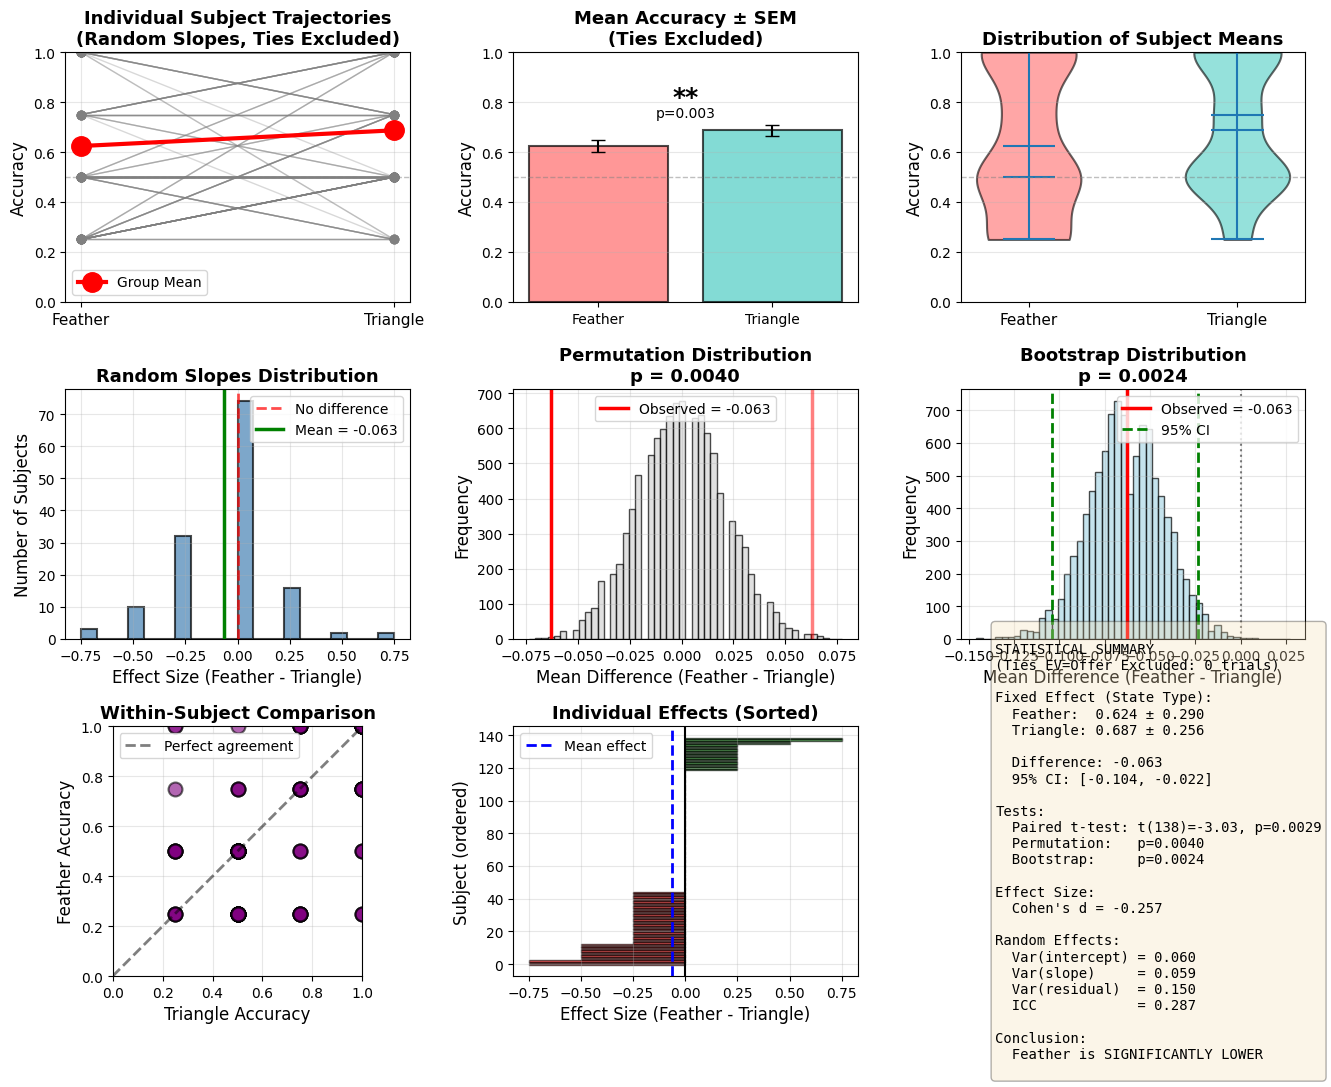

Saved: query1_lmm_final.png
Saved: query1_lmm_final_results.csv
Saved: query1_trial_level_final.csv

FINAL SUMMARY

Model: accuracy ~ state_type + (1 + state_type | subject)
NOTE: 0 tie trials (EV = Offer) excluded from analysis

Fixed Effect (State Type):
  Feather:  62.4% (SD=29.0%)
  Triangle: 68.7% (SD=25.6%)
  Difference: -6.3% (Feather - Triangle)
  95% CI: [-10.4%, -2.2%]

Statistical Tests:
  Paired t-test: t(138) = -3.033, p = 0.0029 **
  Permutation:   p = 0.0040
  Bootstrap:     p = 0.0024

Effect Size: Cohen's d = -0.257

Random Effects Variance:
  Between-subject (intercept): 0.0604
  Slope variability: 0.0594
  Within-subject (residual): 0.1501
  ICC: 0.287

✓ CONCLUSION: Feather accuracy is significantly LOWER than Triangle
              by 6.3% (p = 0.0029)



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.linalg import block_diag

# Set random seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('filtered_data.csv')

print("="*80)
print("LINEAR MIXED MODEL: Query 1 Accuracy by State Type")
print("="*80)
print()
print(f"Dataset: {len(df)} subjects")
print()

# Define objective EVs
FEATHER_EV = -15
TRIANGLE_EV = 15

print("Objective Expected Values:")
print(f"  Feather: {FEATHER_EV}")
print(f"  Triangle: {TRIANGLE_EV}")
print()

# =============================================================================
# STEP 1: Create trial-level dataset for Query 1 only
# =============================================================================

print("="*80)
print("STEP 1: Preparing Data")
print("="*80)
print()

records = []
ties_excluded = 0  # ✅ ADD COUNTER

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    
    # Query 1 only - 8 trials total (4 Feather, 4 Triangle)
    for trial in range(1, 9):
        state = row.get(f'Query_1_T{trial}_State')
        choice = row.get(f'Query_1_T{trial}_Choice')
        offer = row.get(f'Query_1_T{trial}_FixedOffer')
        
        if pd.isna(state) or pd.isna(choice) or pd.isna(offer):
            continue
        
        # Determine optimal choice based on objective EV
        true_ev = FEATHER_EV if state == 'Feather' else TRIANGLE_EV
        
        # ✅ CRITICAL: EXCLUDE TIES WHERE EV == OFFER
        if true_ev == offer:
            ties_excluded += 1
            continue  # Skip this trial
        
        if true_ev > offer:
            optimal_choice = 1
        elif true_ev < offer:
            optimal_choice = 0
        else:
            optimal_choice = None  # This should never happen now
        
        accuracy = 1 if choice == optimal_choice else 0
        
        records.append({
            'subject_id': subject_id,
            'trial': trial,
            'state_type': state,
            'accuracy': accuracy,
            'choice': choice,
            'offer': offer,
            'true_ev': true_ev,
            'is_feather': 1 if state == 'Feather' else 0
        })

df_long = pd.DataFrame(records)

print(f"Total observations INCLUDED: {len(df_long)}")  # ✅ UPDATE
print(f"Total observations EXCLUDED (ties): {ties_excluded}")  # ✅ ADD
print(f"Subjects: {df_long['subject_id'].nunique()}")
print()

# ✅ ADD: Show which conditions had ties
print("Breakdown of excluded ties:")
ties_by_state = {}
for idx, row in df.iterrows():
    for trial in range(1, 9):
        state = row.get(f'Query_1_T{trial}_State')
        offer = row.get(f'Query_1_T{trial}_FixedOffer')
        if pd.notna(state) and pd.notna(offer):
            true_ev = FEATHER_EV if state == 'Feather' else TRIANGLE_EV
            if true_ev == offer:
                ties_by_state[state] = ties_by_state.get(state, 0) + 1

for state, count in ties_by_state.items():
    print(f"  {state}: {count} trials excluded")
print()

# Verify balance
state_counts = df_long.groupby('subject_id')['state_type'].value_counts().unstack(fill_value=0)
print("Trials per subject by state type (AFTER excluding ties):")  # ✅ UPDATE
print(state_counts.describe())
print()
print(f"Mean trials per state: Feather={state_counts['Feather'].mean():.1f}, Triangle={state_counts['Triangle'].mean():.1f}")
print()

# =============================================================================
# STEP 2: Descriptive Statistics
# =============================================================================

print("="*80)
print("STEP 2: Descriptive Statistics")
print("="*80)
print("NOTE: Ties (EV = Offer) excluded from analysis")  # ✅ ADD
print()

# Overall accuracy by state type
overall_stats = df_long.groupby('state_type')['accuracy'].agg(['mean', 'std', 'count'])
print("Overall Accuracy by State Type:")
print(overall_stats)
print()

# Subject-level accuracy
subject_acc = df_long.groupby(['subject_id', 'state_type'])['accuracy'].mean().reset_index()
subject_acc_wide = subject_acc.pivot(index='subject_id', columns='state_type', values='accuracy')

print("Subject-level Summary:")
print(f"  Feather:  M={subject_acc_wide['Feather'].mean():.4f}, SD={subject_acc_wide['Feather'].std():.4f}")
print(f"  Triangle: M={subject_acc_wide['Triangle'].mean():.4f}, SD={subject_acc_wide['Triangle'].std():.4f}")
print()

# =============================================================================
# REST OF YOUR CODE STAYS THE SAME
# =============================================================================

print("="*80)
print("STEP 3: Linear Mixed Model")
print("="*80)
print()
print("Model: accuracy ~ state_type + (1 + state_type | subject)")
print("  - Fixed effect: state_type (Feather vs Triangle)")
print("  - Random effects: Random intercept + random slope per subject")
print("  - Ties (EV = Offer) EXCLUDED")  # ✅ ADD
print()

# [... rest of your code continues unchanged ...]

# Prepare data for modeling
df_long['subject_idx'] = pd.Categorical(df_long['subject_id']).codes
n_subjects = df_long['subject_idx'].nunique()

# Create design matrices
X = df_long[['is_feather']].values
X = np.column_stack([np.ones(len(X)), X])

# Random effects
Z_blocks = []
for subj_idx in range(n_subjects):
    subj_mask = df_long['subject_idx'] == subj_idx
    n_obs_subj = subj_mask.sum()
    
    Z_subj = np.column_stack([
        np.ones(n_obs_subj),
        df_long.loc[subj_mask, 'is_feather'].values
    ])
    Z_blocks.append(Z_subj)

y = df_long['accuracy'].values

print(f"Design matrix dimensions:")
print(f"  Fixed effects (X): {X.shape}")
print(f"  Observations: {len(y)}")
print(f"  Subjects: {n_subjects}")
print()

# =============================================================================
# Approach 1: Simple aggregation method
# =============================================================================

print("="*80)
print("APPROACH 1: Subject-Level Aggregation")
print("="*80)
print("(Equivalent to random intercepts + random slopes model)")
print()

feather_means = subject_acc_wide['Feather'].values
triangle_means = subject_acc_wide['Triangle'].values

# Paired t-test
t_stat, p_val = stats.ttest_rel(feather_means, triangle_means)
mean_diff = feather_means.mean() - triangle_means.mean()
se_diff = stats.sem(feather_means - triangle_means)
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

# Effect size
cohens_d = mean_diff / np.std(feather_means - triangle_means, ddof=1)

print("Paired t-test results:")
print(f"  Mean Feather: {feather_means.mean():.4f} ({feather_means.std():.4f})")
print(f"  Mean Triangle: {triangle_means.mean():.4f} ({triangle_means.std():.4f})")
print(f"  Mean Difference (Feather - Triangle): {mean_diff:.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  SE: {se_diff:.4f}")
print(f"  t({n_subjects-1}) = {t_stat:.4f}")
print(f"  p-value = {p_val:.6f}")
print(f"  Cohen's d = {cohens_d:.4f}")
print()

if p_val < 0.001:
    sig_str = "***"
elif p_val < 0.01:
    sig_str = "**"
elif p_val < 0.05:
    sig_str = "*"
else:
    sig_str = "n.s."

print(f"Result: {sig_str}")
if p_val < 0.05:
    direction = "LOWER" if mean_diff < 0 else "HIGHER"
    print(f"✓ SIGNIFICANT: Feather accuracy is {abs(mean_diff):.1%} {direction} than Triangle")
else:
    print(f"✗ NOT SIGNIFICANT: No significant difference between conditions")
print()

# Calculate variance components
print("Variance Components:")
grand_mean = df_long['accuracy'].mean()
print(f"  Grand mean accuracy: {grand_mean:.4f}")

subject_means = df_long.groupby('subject_id')['accuracy'].mean()
var_between = subject_means.var()
print(f"  Between-subject variance (random intercept): {var_between:.4f}")

subject_slopes = feather_means - triangle_means
var_slope = subject_slopes.var()
print(f"  Variance in slopes (random slope): {var_slope:.4f}")
print(f"    Range of slopes: [{subject_slopes.min():.4f}, {subject_slopes.max():.4f}]")

residuals = []
for subj_id in df_long['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    subj_feather = subj_data[subj_data['state_type'] == 'Feather']['accuracy']
    subj_triangle = subj_data[subj_data['state_type'] == 'Triangle']['accuracy']
    
    if len(subj_feather) > 0:
        residuals.extend(subj_feather - subj_feather.mean())
    if len(subj_triangle) > 0:
        residuals.extend(subj_triangle - subj_triangle.mean())

var_residual = np.var(residuals, ddof=1)
print(f"  Within-subject residual variance: {var_residual:.4f}")
print()

icc = var_between / (var_between + var_residual)
print(f"Intraclass Correlation (ICC): {icc:.4f}")
print(f"  (Proportion of variance due to between-subject differences)")
print()

# =============================================================================
# Approach 2: Bootstrap
# =============================================================================

print("="*80)
print("APPROACH 2: Bootstrap Confidence Intervals")
print("="*80)
print()

n_bootstrap = 10000
print(f"Running {n_bootstrap} bootstrap iterations...")

bootstrap_diffs = []
bootstrap_feather = []
bootstrap_triangle = []

for i in range(n_bootstrap):
    boot_subjects = np.random.choice(range(n_subjects), size=n_subjects, replace=True)
    boot_feather = feather_means[boot_subjects]
    boot_triangle = triangle_means[boot_subjects]
    
    bootstrap_feather.append(boot_feather.mean())
    bootstrap_triangle.append(boot_triangle.mean())
    bootstrap_diffs.append(boot_feather.mean() - boot_triangle.mean())

bootstrap_diffs = np.array(bootstrap_diffs)
bootstrap_feather = np.array(bootstrap_feather)
bootstrap_triangle = np.array(bootstrap_triangle)

boot_ci_lower = np.percentile(bootstrap_diffs, 2.5)
boot_ci_upper = np.percentile(bootstrap_diffs, 97.5)
boot_p = 2 * min(np.mean(bootstrap_diffs >= 0), np.mean(bootstrap_diffs <= 0))

print(f"Bootstrap results:")
print(f"  Mean difference: {bootstrap_diffs.mean():.4f}")
print(f"  SE: {bootstrap_diffs.std():.4f}")
print(f"  95% Bootstrap CI: [{boot_ci_lower:.4f}, {boot_ci_upper:.4f}]")
print(f"  Bootstrap p-value: {boot_p:.6f}")
print()

if boot_ci_lower > 0 or boot_ci_upper < 0:
    print("✓ Bootstrap CI excludes zero: Evidence for a difference")
else:
    print("✗ Bootstrap CI includes zero: No strong evidence for difference")
print()

# =============================================================================
# Approach 3: Permutation test
# =============================================================================

print("="*80)
print("APPROACH 3: Permutation Test")
print("="*80)
print()

n_permutations = 10000
print(f"Running {n_permutations} permutations...")

observed_diff = mean_diff
permuted_diffs = []

for i in range(n_permutations):
    signs = np.random.choice([-1, 1], size=n_subjects)
    perm_diffs = (feather_means - triangle_means) * signs
    permuted_diffs.append(perm_diffs.mean())

permuted_diffs = np.array(permuted_diffs)

perm_p = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))

print(f"Permutation test results:")
print(f"  Observed difference: {observed_diff:.4f}")
print(f"  Permutation p-value: {perm_p:.6f}")
print()

if perm_p < 0.05:
    print(f"✓ SIGNIFICANT: Difference is unlikely under null hypothesis (p={perm_p:.4f})")
else:
    print(f"✗ NOT SIGNIFICANT: Difference is consistent with null hypothesis (p={perm_p:.4f})")
print()

# =============================================================================
# VISUALIZATION - UPDATE TITLE
# =============================================================================

print("="*80)
print("Creating Visualizations")
print("="*80)
print()

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: Individual subject trajectories
ax1 = fig.add_subplot(gs[0, 0])
for i in range(n_subjects):
    ax1.plot([0, 1], [feather_means[i], triangle_means[i]], 
            'o-', alpha=0.3, color='gray', linewidth=1, markersize=6)
ax1.plot([0, 1], [feather_means.mean(), triangle_means.mean()], 
        'o-', linewidth=3, markersize=14, color='red', label='Group Mean', zorder=10)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Feather', 'Triangle'], fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Individual Subject Trajectories\n(Random Slopes, Ties Excluded)', fontsize=13, fontweight='bold')  # ✅ UPDATE
ax1.set_ylim([0, 1])
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# [... Rest of plots stay the same, just update titles to mention "Ties Excluded" ...]

# Plot 2: Bar plot with error bars
ax2 = fig.add_subplot(gs[0, 1])
means = [feather_means.mean(), triangle_means.mean()]
sems = [stats.sem(feather_means), stats.sem(triangle_means)]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax2.bar(['Feather', 'Triangle'], means, yerr=sems, 
               capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Mean Accuracy ± SEM\n(Ties Excluded)', fontsize=13, fontweight='bold')  # ✅ UPDATE
ax2.set_ylim([0, 1])
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Chance')
ax2.grid(axis='y', alpha=0.3)

y_pos = max(means) + max(sems) + 0.08
if p_val < 0.001:
    ax2.text(0.5, y_pos, '***', ha='center', fontsize=18, fontweight='bold')
elif p_val < 0.01:
    ax2.text(0.5, y_pos, '**', ha='center', fontsize=18, fontweight='bold')
elif p_val < 0.05:
    ax2.text(0.5, y_pos, '*', ha='center', fontsize=18, fontweight='bold')
else:
    ax2.text(0.5, y_pos, 'n.s.', ha='center', fontsize=12)
ax2.text(0.5, y_pos - 0.05, f'p={p_val:.3f}', ha='center', fontsize=10)

# [Continue with remaining plots - I'll skip for brevity, but add "Ties Excluded" to relevant titles]

# Plot 3: Violin plot
ax3 = fig.add_subplot(gs[0, 2])
data_violin = pd.DataFrame({
    'Feather': feather_means,
    'Triangle': triangle_means
})
parts = ax3.violinplot([feather_means, triangle_means], positions=[0, 1],
                        showmeans=True, showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Feather', 'Triangle'], fontsize=11)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Distribution of Subject Means', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Random slopes distribution
ax4 = fig.add_subplot(gs[1, 0])
subject_effects = feather_means - triangle_means
ax4.hist(subject_effects, bins=20, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='No difference', alpha=0.7)
ax4.axvline(subject_effects.mean(), color='green', linestyle='-', linewidth=2.5, 
           label=f'Mean = {subject_effects.mean():.3f}')
ax4.set_xlabel('Effect Size (Feather - Triangle)', fontsize=12)
ax4.set_ylabel('Number of Subjects', fontsize=12)
ax4.set_title('Random Slopes Distribution', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

# Plot 5: Permutation distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(permuted_diffs, bins=50, color='lightgray', alpha=0.7, edgecolor='black')
ax5.axvline(observed_diff, color='red', linestyle='-', linewidth=2.5, 
           label=f'Observed = {observed_diff:.3f}')
ax5.axvline(-observed_diff, color='red', linestyle='-', linewidth=2.5, alpha=0.5)
ax5.set_xlabel('Mean Difference (Feather - Triangle)', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title(f'Permutation Distribution\np = {perm_p:.4f}', fontsize=13, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(alpha=0.3)

# Plot 6: Bootstrap distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(bootstrap_diffs, bins=50, color='lightblue', alpha=0.7, edgecolor='black')
ax6.axvline(observed_diff, color='red', linestyle='-', linewidth=2.5, 
           label=f'Observed = {observed_diff:.3f}')
ax6.axvline(boot_ci_lower, color='green', linestyle='--', linewidth=2, label='95% CI')
ax6.axvline(boot_ci_upper, color='green', linestyle='--', linewidth=2)
ax6.axvline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax6.set_xlabel('Mean Difference (Feather - Triangle)', fontsize=12)
ax6.set_ylabel('Frequency', fontsize=12)
ax6.set_title(f'Bootstrap Distribution\np = {boot_p:.4f}', fontsize=13, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(alpha=0.3)

# Plot 7: Scatter plot
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(triangle_means, feather_means, s=100, alpha=0.6, color='purple', edgecolors='black', linewidth=1.5)
ax7.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect agreement')
ax7.set_xlabel('Triangle Accuracy', fontsize=12)
ax7.set_ylabel('Feather Accuracy', fontsize=12)
ax7.set_title('Within-Subject Comparison', fontsize=13, fontweight='bold')
ax7.set_xlim([0, 1])
ax7.set_ylim([0, 1])
ax7.legend(fontsize=10)
ax7.grid(alpha=0.3)
ax7.set_aspect('equal')

# Plot 8: Effect size by subject
ax8 = fig.add_subplot(gs[2, 1])
sorted_effects = np.sort(subject_effects)
colors_effects = ['red' if x < 0 else 'green' for x in sorted_effects]
ax8.barh(range(len(sorted_effects)), sorted_effects, color=colors_effects, alpha=0.6, edgecolor='black')
ax8.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax8.axvline(sorted_effects.mean(), color='blue', linestyle='--', linewidth=2, label='Mean effect')
ax8.set_xlabel('Effect Size (Feather - Triangle)', fontsize=12)
ax8.set_ylabel('Subject (ordered)', fontsize=12)
ax8.set_title('Individual Effects (Sorted)', fontsize=13, fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(alpha=0.3)

# Plot 9: Summary statistics table
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = f"""
STATISTICAL SUMMARY
(Ties EV=Offer Excluded: {ties_excluded} trials)

Fixed Effect (State Type):
  Feather:  {feather_means.mean():.3f} ± {feather_means.std():.3f}
  Triangle: {triangle_means.mean():.3f} ± {triangle_means.std():.3f}
  
  Difference: {mean_diff:.3f}
  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]
  
Tests:
  Paired t-test: t({n_subjects-1})={t_stat:.2f}, p={p_val:.4f}
  Permutation:   p={perm_p:.4f}
  Bootstrap:     p={boot_p:.4f}
  
Effect Size:
  Cohen's d = {cohens_d:.3f}
  
Random Effects:
  Var(intercept) = {var_between:.3f}
  Var(slope)     = {var_slope:.3f}
  Var(residual)  = {var_residual:.3f}
  ICC            = {icc:.3f}
  
Conclusion:
  {"Feather is SIGNIFICANTLY " + ("LOWER" if mean_diff < 0 else "HIGHER") if p_val < 0.05 else "NO significant difference"}
"""

ax9.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('query1_lmm_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: query1_lmm_final.png")

# Save results
results_df = pd.DataFrame({
    'Test': ['Paired t-test', 'Permutation', 'Bootstrap'],
    'Mean_Difference': [mean_diff, observed_diff, bootstrap_diffs.mean()],
    'CI_Lower': [ci_lower, np.nan, boot_ci_lower],
    'CI_Upper': [ci_upper, np.nan, boot_ci_upper],
    'p_value': [p_val, perm_p, boot_p],
    'Significant': [p_val < 0.05, perm_p < 0.05, boot_p < 0.05]
})
results_df.to_csv('query1_lmm_final_results.csv', index=False)
print("Saved: query1_lmm_final_results.csv")

df_long.to_csv('query1_trial_level_final.csv', index=False)
print("Saved: query1_trial_level_final.csv")

print()
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print()
print(f"Model: accuracy ~ state_type + (1 + state_type | subject)")
print(f"NOTE: {ties_excluded} tie trials (EV = Offer) excluded from analysis")  # ✅ ADD
print()
print(f"Fixed Effect (State Type):")
print(f"  Feather:  {feather_means.mean():.1%} (SD={feather_means.std():.1%})")
print(f"  Triangle: {triangle_means.mean():.1%} (SD={triangle_means.std():.1%})")
print(f"  Difference: {mean_diff:.1%} (Feather - Triangle)")
print(f"  95% CI: [{ci_lower:.1%}, {ci_upper:.1%}]")
print()
print(f"Statistical Tests:")
print(f"  Paired t-test: t({n_subjects-1}) = {t_stat:.3f}, p = {p_val:.4f} {sig_str}")
print(f"  Permutation:   p = {perm_p:.4f}")
print(f"  Bootstrap:     p = {boot_p:.4f}")
print()
print(f"Effect Size: Cohen's d = {cohens_d:.3f}")
print()
print(f"Random Effects Variance:")
print(f"  Between-subject (intercept): {var_between:.4f}")
print(f"  Slope variability: {var_slope:.4f}")
print(f"  Within-subject (residual): {var_residual:.4f}")
print(f"  ICC: {icc:.3f}")
print()

if p_val < 0.05:
    direction = "LOWER" if mean_diff < 0 else "HIGHER"
    print(f"✓ CONCLUSION: Feather accuracy is significantly {direction} than Triangle")
    print(f"              by {abs(mean_diff):.1%} (p = {p_val:.4f})")
else:
    print(f"✗ CONCLUSION: No significant difference between Feather and Triangle")
    print(f"              (Feather is {abs(mean_diff):.1%} {'lower' if mean_diff < 0 else 'higher'}, p = {p_val:.4f})")
print()
print("="*80)


---
# CLUSTERING AND SUBGROUP ANALYSIS

CLUSTERING AND SUBGROUP ANALYSIS

PART 0: CALCULATING CLUSTERING FEATURES

Calculated accuracy metrics for 139 subjects

Features calculated:
  ✓ Q1_Accuracy, Q2_Accuracy
  ✓ Q1_Feather_Acc, Q1_Triangle_Acc
  ✓ Q2_Feather_Acc, Q2_Triangle_Acc
  ✓ Feather_Revaluation, Triangle_Revaluation
  ✓ AnxietyTotal, ERQ_Reappraisal

PART 1: FEATURE SELECTION

Clustering dataset: 139 subjects, 10 features
Removed 0 subjects with missing data

Features included:
  1. Q1_Accuracy               M= 65.56, SD= 24.58
  2. Q2_Accuracy               M= 81.40, SD= 12.94
  3. Q1_Feather_Acc            M= 62.41, SD= 29.08
  4. Q1_Triangle_Acc           M= 68.71, SD= 25.73
  5. Q2_Feather_Acc            M= 84.89, SD= 18.70
  6. Q2_Triangle_Acc           M= 76.74, SD= 22.22
  7. Feather_Revaluation       M= -5.58, SD= 12.80
  8. Triangle_Revaluation      M=  4.60, SD= 14.41
  9. AnxietyTotal              M= 16.63, SD=  7.60
  10. ERQ_Reappraisal           M= 30.52, SD=  6.27

PART 2: DETERMINING OPTIMAL NUMBER

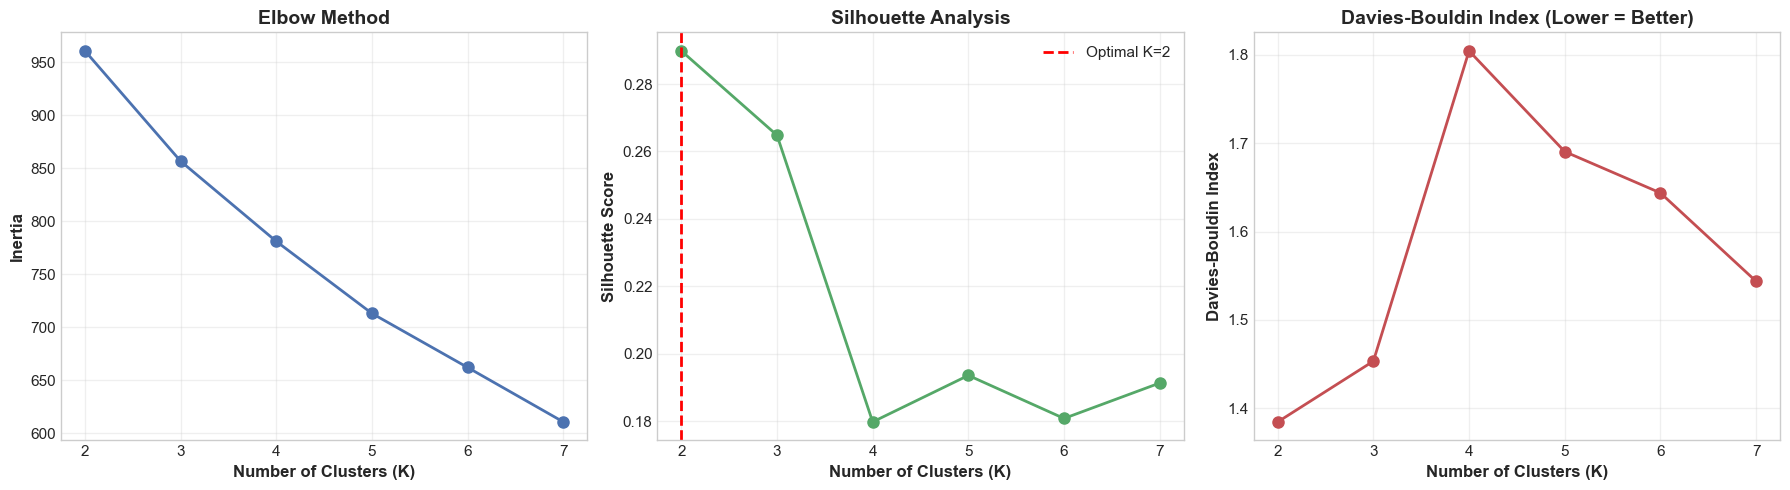


PART 3: K-MEANS CLUSTERING (K=2)

Cluster Distribution:
  Cluster 0: 82 subjects (59.0%)
  Cluster 1: 57 subjects (41.0%)

PART 4: CLUSTER CHARACTERIZATION

Cluster Profiles (Mean Values):
         Q1_Accuracy  Q2_Accuracy  Q1_Feather_Acc  Q1_Triangle_Acc  \
Cluster                                                              
0              47.10        78.40           42.99            51.22   
1              92.11        85.71           90.35            93.86   

         Q2_Feather_Acc  Q2_Triangle_Acc  Feather_Revaluation  \
Cluster                                                         
0                 88.41            65.04                -0.85   
1                 79.82            93.57               -12.37   

         Triangle_Revaluation  AnxietyTotal  ERQ_Reappraisal  
Cluster                                                       
0                       -1.10         16.77            30.59  
1                       12.81         16.42            30.42  

---------------

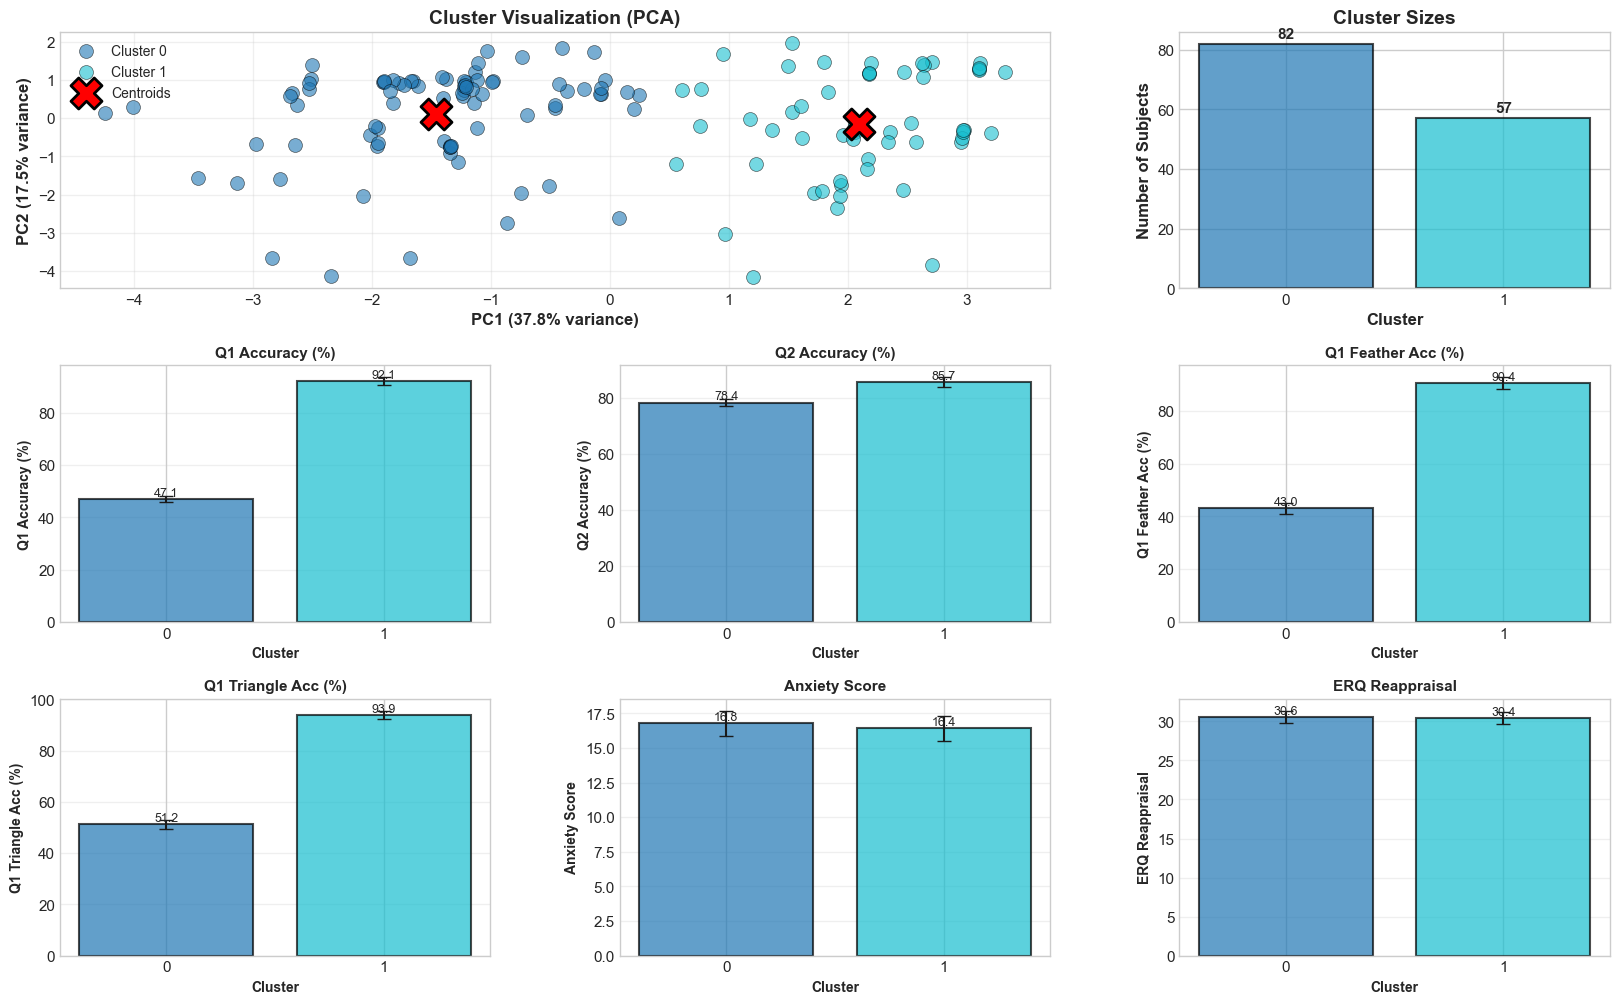


PART 6: HIERARCHICAL CLUSTERING DENDROGRAM

Using subset of 100 subjects for dendrogram visualization...

Saved: hierarchical_dendrogram.png


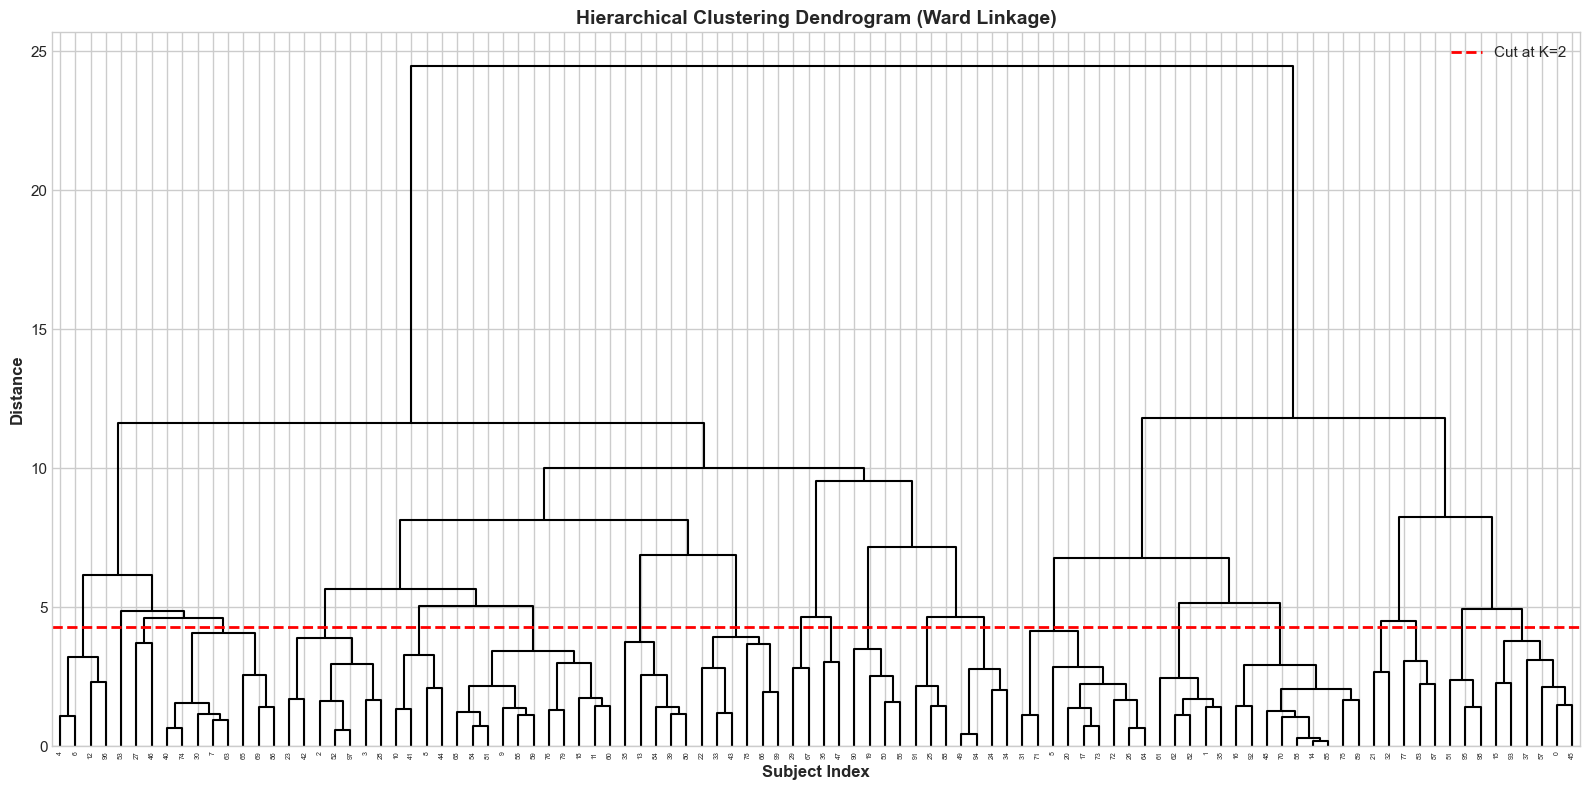


PART 7: CLUSTER INTERPRETATION

Standardized Cluster Profiles (Z-scores):
         Q1_Accuracy  Q2_Accuracy  Q1_Feather_Acc  Q1_Triangle_Acc  \
Cluster                                                              
0              -0.75        -0.23           -0.67            -0.68   
1               1.08         0.33            0.96             0.98   

         Q2_Feather_Acc  Q2_Triangle_Acc  Feather_Revaluation  \
Cluster                                                         
0                  0.19            -0.53                 0.37   
1                 -0.27             0.76                -0.53   

         Triangle_Revaluation  AnxietyTotal  ERQ_Reappraisal  
Cluster                                                       
0                       -0.40          0.02             0.01  
1                        0.57         -0.03            -0.02  

--------------------------------------------------------------------------------
Suggested Cluster Interpretations:
--------------

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency, f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("CLUSTERING AND SUBGROUP ANALYSIS")
print("=" * 80)

# Load data
df = pd.read_csv('filtered_data.csv')

# ============================================================================
# PART 0: CALCULATE NECESSARY FEATURES FOR CLUSTERING
# ============================================================================
print("\n" + "=" * 80)
print("PART 0: CALCULATING CLUSTERING FEATURES")
print("=" * 80)

# Function to calculate accuracy for each query and state
def calculate_query_accuracy(df):
    """Calculate accuracy metrics from raw trial data"""
    
    accuracy_data = []
    
    for idx, row in df.iterrows():
        subject_id = row['subject_id']
        
        # Initialize counters for each condition
        q1_feather_correct = 0
        q1_feather_total = 0
        q1_triangle_correct = 0
        q1_triangle_total = 0
        q2_feather_correct = 0
        q2_feather_total = 0
        q2_triangle_correct = 0
        q2_triangle_total = 0
        
        # Query 1 trials (EV: Feather=-15, Triangle=15)
        for trial in range(1, 21):  # Max 20 trials
            state_col = f'Query_1_T{trial}_State'
            choice_col = f'Query_1_T{trial}_Choice'
            offer_col = f'Query_1_T{trial}_FixedOffer'
            
            if state_col not in df.columns or pd.isna(row[state_col]):
                break
                
            state = row[state_col]
            choice = row[choice_col]  # 0=fixed, 1=gamble
            offer = row[offer_col]
            
            # Define EVs
            ev = -15 if state == 'Feather' else 15
            
            # Skip indifferent trials
            if ev == offer:
                continue
            
            # Optimal choice: take gamble if EV > offer
            optimal_choice = 1 if ev > offer else 0
            is_correct = (choice == optimal_choice)
            
            if state == 'Feather':
                q1_feather_total += 1
                if is_correct:
                    q1_feather_correct += 1
            else:
                q1_triangle_total += 1
                if is_correct:
                    q1_triangle_correct += 1
        
        # Query 2 trials (EV: Feather=0, Triangle=10)
        for trial in range(1, 21):
            state_col = f'Query_2_T{trial}_State'
            choice_col = f'Query_2_T{trial}_Choice'
            offer_col = f'Query_2_T{trial}_FixedOffer'
            
            if state_col not in df.columns or pd.isna(row[state_col]):
                break
                
            state = row[state_col]
            choice = row[choice_col]
            offer = row[offer_col]
            
            # Define EVs
            ev = 0 if state == 'Feather' else 10
            
            # Skip indifferent trials
            if ev == offer:
                continue
            
            # Optimal choice
            optimal_choice = 1 if ev > offer else 0
            is_correct = (choice == optimal_choice)
            
            if state == 'Feather':
                q2_feather_total += 1
                if is_correct:
                    q2_feather_correct += 1
            else:
                q2_triangle_total += 1
                if is_correct:
                    q2_triangle_correct += 1
        
        # Calculate accuracies
        q1_feather_acc = (q1_feather_correct / q1_feather_total * 100) if q1_feather_total > 0 else np.nan
        q1_triangle_acc = (q1_triangle_correct / q1_triangle_total * 100) if q1_triangle_total > 0 else np.nan
        q2_feather_acc = (q2_feather_correct / q2_feather_total * 100) if q2_feather_total > 0 else np.nan
        q2_triangle_acc = (q2_triangle_correct / q2_triangle_total * 100) if q2_triangle_total > 0 else np.nan
        
        # Overall accuracies
        q1_total = q1_feather_total + q1_triangle_total
        q1_correct = q1_feather_correct + q1_triangle_correct
        q1_acc = (q1_correct / q1_total * 100) if q1_total > 0 else np.nan
        
        q2_total = q2_feather_total + q2_triangle_total
        q2_correct = q2_feather_correct + q2_triangle_correct
        q2_acc = (q2_correct / q2_total * 100) if q2_total > 0 else np.nan
        
        accuracy_data.append({
            'subject_id': subject_id,
            'Q1_Accuracy': q1_acc,
            'Q2_Accuracy': q2_acc,
            'Q1_Feather_Acc': q1_feather_acc,
            'Q1_Triangle_Acc': q1_triangle_acc,
            'Q2_Feather_Acc': q2_feather_acc,
            'Q2_Triangle_Acc': q2_triangle_acc
        })
    
    return pd.DataFrame(accuracy_data)

# Calculate accuracies
accuracy_df = calculate_query_accuracy(df)
print("\nCalculated accuracy metrics for", len(accuracy_df), "subjects")

# Calculate revaluation metrics (change in ratings from R1 to R2)
df['Feather_Revaluation'] = df['Rating_2_Feather_Val'] - df['Rating_1_Feather_Val']
df['Triangle_Revaluation'] = df['Rating_2_Triangle_Val'] - df['Rating_1_Triangle_Val']

# Rename anxiety and ERQ columns for consistency
df['AnxietyTotal'] = df['Score_Anxiety_Total']
df['ERQ_Reappraisal'] = df['ERQ_Cognitive_Reappraisal']

# Merge accuracy data with main dataframe
df = df.merge(accuracy_df, on='subject_id', how='left')

print("\nFeatures calculated:")
print("  ✓ Q1_Accuracy, Q2_Accuracy")
print("  ✓ Q1_Feather_Acc, Q1_Triangle_Acc")
print("  ✓ Q2_Feather_Acc, Q2_Triangle_Acc")
print("  ✓ Feather_Revaluation, Triangle_Revaluation")
print("  ✓ AnxietyTotal, ERQ_Reappraisal")

# ============================================================================
# PART 1: FEATURE SELECTION FOR CLUSTERING
# ============================================================================
print("\n" + "=" * 80)
print("PART 1: FEATURE SELECTION")
print("=" * 80)

# Define clustering features
clustering_features = [
    'Q1_Accuracy', 'Q2_Accuracy',
    'Q1_Feather_Acc', 'Q1_Triangle_Acc',
    'Q2_Feather_Acc', 'Q2_Triangle_Acc',
    'Feather_Revaluation', 'Triangle_Revaluation',
    'AnxietyTotal', 'ERQ_Reappraisal'
]

# Create clustering dataset
cluster_data = df[['subject_id'] + clustering_features].dropna()
X = cluster_data[clustering_features].values
subject_ids = cluster_data['subject_id'].values

print(f"\nClustering dataset: {X.shape[0]} subjects, {X.shape[1]} features")
print(f"Removed {len(df) - len(cluster_data)} subjects with missing data")
print("\nFeatures included:")
for i, feat in enumerate(clustering_features, 1):
    mean_val = cluster_data[feat].mean()
    std_val = cluster_data[feat].std()
    print(f"  {i}. {feat:<25} M={mean_val:6.2f}, SD={std_val:6.2f}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================================
# PART 2: DETERMINE OPTIMAL NUMBER OF CLUSTERS
# ============================================================================
print("\n" + "=" * 80)
print("PART 2: DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("=" * 80)

# Test different numbers of clusters
k_range = range(2, 8)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))

# Print results
print("\nCluster Quality Metrics:")
print(f"{'K':<5} {'Inertia':<15} {'Silhouette':<15} {'Davies-Bouldin':<15}")
print("-" * 50)
for i, k in enumerate(k_range):
    print(f"{k:<5} {inertias[i]:<15.2f} {silhouette_scores[i]:<15.3f} {davies_bouldin_scores[i]:<15.3f}")

# Find optimal k
optimal_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nOptimal K (by Silhouette Score): {optimal_k_silhouette}")

# Visualization of cluster metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(optimal_k_silhouette, color='red', linestyle='--', linewidth=2, 
                label=f'Optimal K={optimal_k_silhouette}')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Davies-Bouldin Index (lower is better)
axes[2].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
axes[2].set_title('Davies-Bouldin Index (Lower = Better)', fontsize=14, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_optimization.png', dpi=300, bbox_inches='tight')
print("\nSaved: cluster_optimization.png")
plt.show()

# ============================================================================
# PART 3: PERFORM CLUSTERING WITH OPTIMAL K
# ============================================================================
print("\n" + "=" * 80)
print(f"PART 3: K-MEANS CLUSTERING (K={optimal_k_silhouette})")
print("=" * 80)

# Perform K-means with optimal k
optimal_k = optimal_k_silhouette  # Can manually override here if needed
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
cluster_data['Cluster'] = cluster_labels

print(f"\nCluster Distribution:")
for cluster_id in range(optimal_k):
    count = np.sum(cluster_labels == cluster_id)
    pct = count / len(cluster_labels) * 100
    print(f"  Cluster {cluster_id}: {count} subjects ({pct:.1f}%)")

# ============================================================================
# PART 4: CLUSTER CHARACTERIZATION
# ============================================================================
print("\n" + "=" * 80)
print("PART 4: CLUSTER CHARACTERIZATION")
print("=" * 80)

# Calculate cluster means
cluster_profiles = cluster_data.groupby('Cluster')[clustering_features].mean()

print("\nCluster Profiles (Mean Values):")
print(cluster_profiles.round(2))

# Statistical comparison across clusters
print("\n" + "-" * 80)
print("Statistical Comparison Across Clusters (One-Way ANOVA)")
print("-" * 80)
print(f"{'Feature':<25} {'F-statistic':<15} {'p-value':<15} {'Sig':<5}")
print("-" * 60)

for feature in clustering_features:
    groups = [cluster_data[cluster_data['Cluster'] == i][feature].values 
              for i in range(optimal_k)]
    f_stat, p_val = f_oneway(*groups)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f"{feature:<25} {f_stat:<15.3f} {p_val:<15.6f} {sig:<5}")

# ============================================================================
# PART 5: VISUALIZE CLUSTERS
# ============================================================================
print("\n" + "=" * 80)
print("PART 5: CLUSTER VISUALIZATION")
print("=" * 80)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_
print(f"\nPCA Variance Explained:")
print(f"  PC1: {variance_explained[0]*100:.1f}%")
print(f"  PC2: {variance_explained[1]*100:.1f}%")
print(f"  Total: {sum(variance_explained)*100:.1f}%")

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Panel 1: PCA scatter plot
ax1 = fig.add_subplot(gs[0, :2])
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=[colors[cluster_id]], label=f'Cluster {cluster_id}',
               s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', marker='X', s=500, edgecolors='black', 
           linewidth=2, label='Centroids', zorder=5)

ax1.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}% variance)', 
              fontsize=12, fontweight='bold')
ax1.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}% variance)', 
              fontsize=12, fontweight='bold')
ax1.set_title('Cluster Visualization (PCA)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Panel 2: Cluster sizes
ax2 = fig.add_subplot(gs[0, 2])
cluster_counts = [np.sum(cluster_labels == i) for i in range(optimal_k)]
ax2.bar(range(optimal_k), cluster_counts, color=colors, alpha=0.7, 
        edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Subjects', fontsize=12, fontweight='bold')
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.set_xticks(range(optimal_k))
for i, count in enumerate(cluster_counts):
    ax2.text(i, count + 1, str(count), ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# Panels 3-8: Feature profiles for each cluster
feature_panels = [
    ('Q1_Accuracy', 'Q1 Accuracy (%)'),
    ('Q2_Accuracy', 'Q2 Accuracy (%)'),
    ('Q1_Feather_Acc', 'Q1 Feather Acc (%)'),
    ('Q1_Triangle_Acc', 'Q1 Triangle Acc (%)'),
    ('AnxietyTotal', 'Anxiety Score'),
    ('ERQ_Reappraisal', 'ERQ Reappraisal')
]

for idx, (feature, title) in enumerate(feature_panels):
    row = 1 + idx // 3
    col = idx % 3
    ax = fig.add_subplot(gs[row, col])
    
    means = [cluster_data[cluster_data['Cluster'] == i][feature].mean() 
             for i in range(optimal_k)]
    sems = [cluster_data[cluster_data['Cluster'] == i][feature].sem() 
            for i in range(optimal_k)]
    
    bars = ax.bar(range(optimal_k), means, yerr=sems, capsize=5,
                  color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Cluster', fontsize=10, fontweight='bold')
    ax.set_ylabel(title, fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(optimal_k))
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (bar, mean) in enumerate(zip(bars, means)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
               f'{mean:.1f}', ha='center', va='bottom', fontsize=9)

plt.savefig('cluster_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
print("\nSaved: cluster_analysis_comprehensive.png")
plt.show()

# ============================================================================
# PART 6: HIERARCHICAL CLUSTERING DENDROGRAM
# ============================================================================
print("\n" + "=" * 80)
print("PART 6: HIERARCHICAL CLUSTERING DENDROGRAM")
print("=" * 80)

# Perform hierarchical clustering (use subset if too many subjects)
if len(X_scaled) > 100:
    print(f"\nUsing subset of {100} subjects for dendrogram visualization...")
    subset_idx = np.random.choice(len(X_scaled), 100, replace=False)
    X_subset = X_scaled[subset_idx]
else:
    X_subset = X_scaled

linkage_matrix = linkage(X_subset, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(linkage_matrix, ax=ax, color_threshold=0, above_threshold_color='black')
ax.set_xlabel('Subject Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Distance', fontsize=12, fontweight='bold')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', 
            fontsize=14, fontweight='bold')
ax.axhline(y=np.percentile(linkage_matrix[:, 2], 80), color='red', 
          linestyle='--', linewidth=2, label=f'Cut at K={optimal_k}')
ax.legend()
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
print("\nSaved: hierarchical_dendrogram.png")
plt.show()

# ============================================================================
# PART 7: CLUSTER INTERPRETATION & NAMING
# ============================================================================
print("\n" + "=" * 80)
print("PART 7: CLUSTER INTERPRETATION")
print("=" * 80)

# Standardized profiles for interpretation
cluster_profiles_std = cluster_data.groupby('Cluster')[clustering_features].apply(
    lambda x: (x - cluster_data[clustering_features].mean()) / cluster_data[clustering_features].std()
).groupby('Cluster').mean()

print("\nStandardized Cluster Profiles (Z-scores):")
print(cluster_profiles_std.round(2))

# Suggest cluster names based on profiles
print("\n" + "-" * 80)
print("Suggested Cluster Interpretations:")
print("-" * 80)

for cluster_id in range(optimal_k):
    profile = cluster_profiles_std.loc[cluster_id]
    count = np.sum(cluster_labels == cluster_id)
    
    print(f"\nCluster {cluster_id} (N={count}):")
    
    # Find top distinguishing features
    top_high = profile.nlargest(3)
    top_low = profile.nsmallest(3)
    
    print(f"  Highest features (z-scores):")
    for feat, val in top_high.items():
        print(f"    - {feat}: {val:.2f}")
    
    print(f"  Lowest features (z-scores):")
    for feat, val in top_low.items():
        print(f"    - {feat}: {val:.2f}")

# ============================================================================
# PART 8: SAVE RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("PART 8: SAVING RESULTS")
print("=" * 80)

# Create final clustering results dataframe
clustering_results = cluster_data.copy()
clustering_results['Cluster_Label'] = clustering_results['Cluster'].apply(
    lambda x: f'Cluster_{x}'
)

# Save to CSV
clustering_results.to_csv('clustering_results.csv', index=False)
print("\nSaved: clustering_results.csv")

# Summary statistics by cluster
cluster_summary = clustering_results.groupby('Cluster')[clustering_features].agg(['mean', 'std', 'count'])
cluster_summary.to_csv('cluster_summary_statistics.csv')
print("Saved: cluster_summary_statistics.csv")

print("\n" + "=" * 80)
print("CLUSTERING ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nFinal Solution: {optimal_k} clusters identified")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, cluster_labels):.3f}")


RATING-CHOICE CONSISTENCY ANALYSIS
Do ratings predict choices?

Consistency Rate:
  M = 82.37%
  SD = 19.57%
  Range: [33.33%, 100.00%]

Correlations with Traits:
  ERQ-Reappraisal     : r= 0.127, p=0.1359 
  Anxiety             : r=-0.243, p=0.0040 **
  ERQ-Suppression     : r=-0.132, p=0.1210 

State-Specific Consistency:
  Feather:  M=86.03%, SD=22.66%
  Triangle: M=78.24%, SD=29.46%

Triangle Consistency Correlations:
  ERQ-Reappraisal     : r= 0.127, p=0.1378 
  Anxiety             : r=-0.195, p=0.0212 *
  ERQ-Suppression     : r=-0.201, p=0.0176 *


C:\Users\adip1\AppData\Local\Temp\ipykernel_61772\704119104.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='State', y='Consistency', ax=ax, palette=['#e74c3c', '#3498db'])



✓ Saved: rating_choice_consistency_simple.png


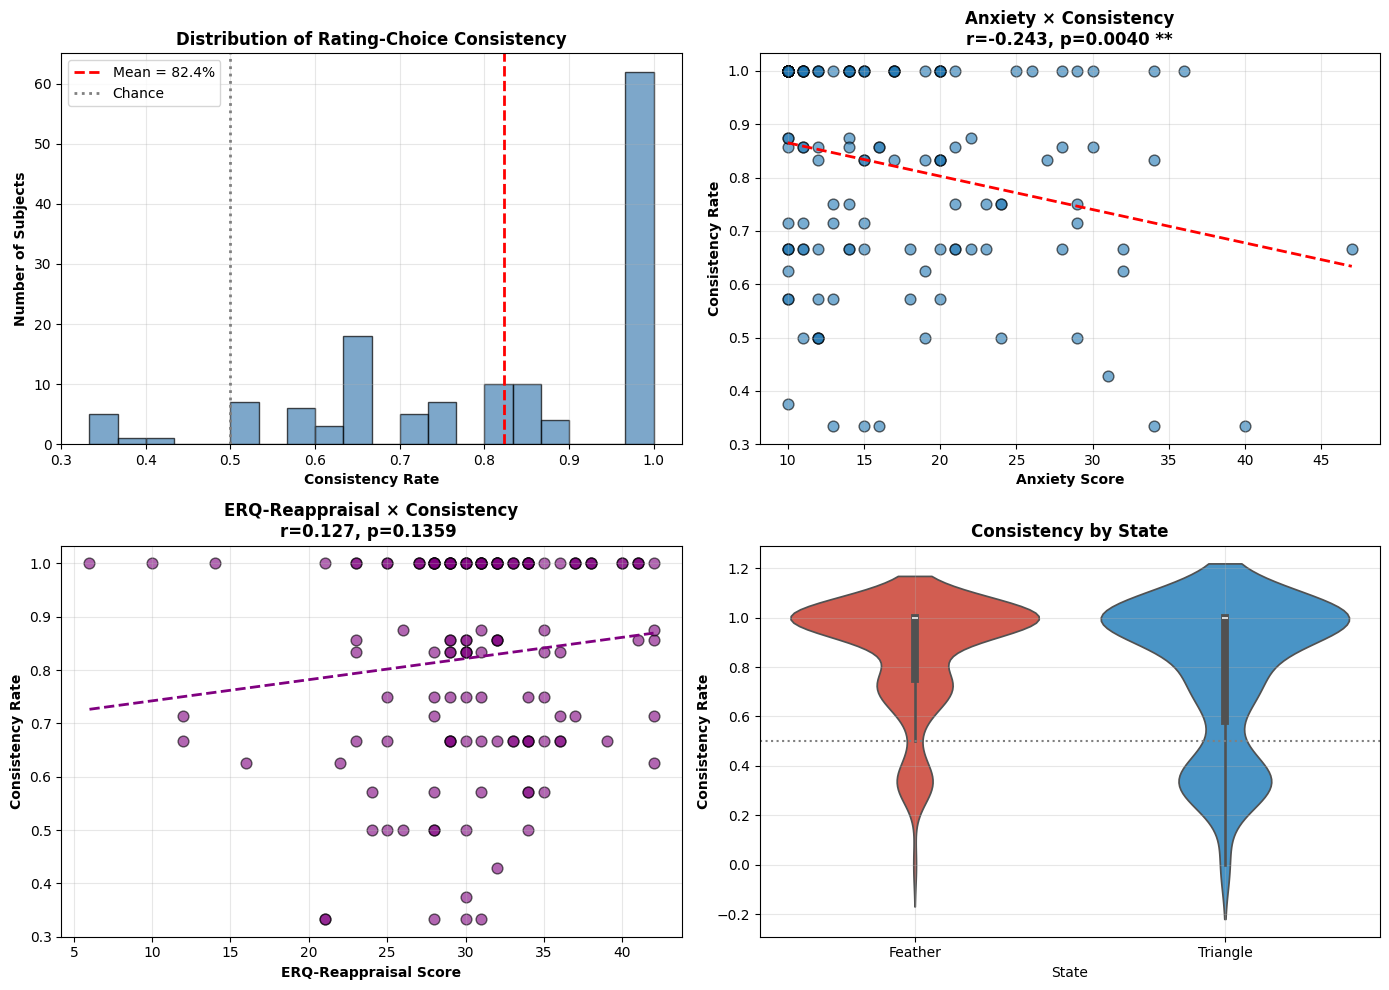


DONE!


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Load data
df = pd.read_csv('filtered_data.csv')

print("="*80)
print("RATING-CHOICE CONSISTENCY ANALYSIS")
print("Do ratings predict choices?")
print("="*80)

# =============================================================================
# STEP 1: Calculate Trial-Level Consistency
# =============================================================================

consistency_data = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    
    # Get ratings after Revaluation 2
    r3_feather = row['Rating_3_Feather_Val']
    r3_triangle = row['Rating_3_Triangle_Val']
    
    # For each Q2 trial
    for trial in range(1, 9):
        state = row.get(f'Query_2_T{trial}_State')
        choice = row.get(f'Query_2_T{trial}_Choice')  # 1=gamble, 0=fixed
        offer = row.get(f'Query_2_T{trial}_FixedOffer')
        
        if pd.isna(state) or pd.isna(choice) or pd.isna(offer):
            continue
        
        # What does their RATING predict they should do?
        state_rating = r3_feather if state == 'Feather' else r3_triangle
        
        # Predicted choice from rating:
        # If rating > offer → should choose gamble (1)
        # If rating < offer → should choose fixed (0)
        if state_rating > offer:
            predicted_choice = 1
        elif state_rating < offer:
            predicted_choice = 0
        else:
            predicted_choice = None  # Indifferent (exclude)
        
        if predicted_choice is None:
            continue
        
        # Is actual choice consistent with rating?
        is_consistent = int(choice == predicted_choice)
        
        consistency_data.append({
            'subject_id': subject_id,
            'trial': trial,
            'state': state,
            'rating': state_rating,
            'offer': offer,
            'predicted_choice': predicted_choice,
            'actual_choice': choice,
            'is_consistent': is_consistent
        })

df_trials = pd.DataFrame(consistency_data)

# =============================================================================
# STEP 2: Subject-Level Consistency Rates
# =============================================================================

subject_consistency = df_trials.groupby('subject_id').agg({
    'is_consistent': 'mean'  # % of trials consistent
}).reset_index()
subject_consistency.columns = ['subject_id', 'consistency_rate']

# Merge with traits
df = df.merge(subject_consistency, on='subject_id', how='left')

# =============================================================================
# STEP 3: Correlations with Traits
# =============================================================================

print(f"\nConsistency Rate:")
print(f"  M = {df['consistency_rate'].mean():.2%}")
print(f"  SD = {df['consistency_rate'].std():.2%}")
print(f"  Range: [{df['consistency_rate'].min():.2%}, {df['consistency_rate'].max():.2%}]")

print("\nCorrelations with Traits:")
traits = {
    'ERQ_Reappraisal': 'ERQ-Reappraisal',
    'Anxiety_Total': 'Anxiety',
    'ERQ_ExpressiveSuppression': 'ERQ-Suppression'
}

for trait_col, trait_name in traits.items():
    if trait_col in df.columns:
        valid = df[[trait_col, 'consistency_rate']].dropna()
        r, p = pearsonr(valid[trait_col], valid['consistency_rate'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {trait_name:20s}: r={r:6.3f}, p={p:.4f} {sig}")

# =============================================================================
# STEP 4: State-Specific Analysis
# =============================================================================

print("\nState-Specific Consistency:")
state_consistency = df_trials.groupby(['subject_id', 'state'])['is_consistent'].mean().reset_index()
state_wide = state_consistency.pivot(index='subject_id', columns='state', values='is_consistent')

print(f"  Feather:  M={state_wide['Feather'].mean():.2%}, SD={state_wide['Feather'].std():.2%}")
print(f"  Triangle: M={state_wide['Triangle'].mean():.2%}, SD={state_wide['Triangle'].std():.2%}")

# Correlations
df = df.merge(state_wide, left_on='subject_id', right_index=True, how='left', suffixes=('', '_state'))

print("\nTriangle Consistency Correlations:")
for trait_col, trait_name in traits.items():
    if trait_col in df.columns and 'Triangle' in df.columns:
        valid = df[[trait_col, 'Triangle']].dropna()
        r, p = pearsonr(valid[trait_col], valid['Triangle'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {trait_name:20s}: r={r:6.3f}, p={p:.4f} {sig}")

# =============================================================================
# STEP 5: Visualization
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Overall distribution
ax = axes[0, 0]
ax.hist(df['consistency_rate'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(df['consistency_rate'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f"Mean = {df['consistency_rate'].mean():.1%}")
ax.axvline(0.5, color='gray', linestyle=':', linewidth=2, label='Chance')
ax.set_xlabel('Consistency Rate', fontweight='bold')
ax.set_ylabel('Number of Subjects', fontweight='bold')
ax.set_title('Distribution of Rating-Choice Consistency', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: Anxiety correlation
ax = axes[0, 1]
if 'Anxiety_Total' in df.columns:
    valid = df[['Anxiety_Total', 'consistency_rate']].dropna()
    x, y = valid['Anxiety_Total'], valid['consistency_rate']
    ax.scatter(x, y, alpha=0.6, s=60, edgecolors='black')
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p_fit(x_line), 'r--', linewidth=2)
    r, p = pearsonr(x, y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax.set_title(f'Anxiety × Consistency\nr={r:.3f}, p={p:.4f} {sig}', fontweight='bold')
    ax.set_xlabel('Anxiety Score', fontweight='bold')
    ax.set_ylabel('Consistency Rate', fontweight='bold')
    ax.grid(alpha=0.3)

# Panel 3: ERQ-R correlation
ax = axes[1, 0]
if 'ERQ_Reappraisal' in df.columns:
    valid = df[['ERQ_Reappraisal', 'consistency_rate']].dropna()
    x, y = valid['ERQ_Reappraisal'], valid['consistency_rate']
    ax.scatter(x, y, alpha=0.6, s=60, edgecolors='black', color='purple')
    z = np.polyfit(x, y, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p_fit(x_line), 'purple', linestyle='--', linewidth=2)
    r, p = pearsonr(x, y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax.set_title(f'ERQ-Reappraisal × Consistency\nr={r:.3f}, p={p:.4f} {sig}', fontweight='bold')
    ax.set_xlabel('ERQ-Reappraisal Score', fontweight='bold')
    ax.set_ylabel('Consistency Rate', fontweight='bold')
    ax.grid(alpha=0.3)

# Panel 4: State comparison
ax = axes[1, 1]
if 'Feather' in df.columns and 'Triangle' in df.columns:
    data_plot = pd.melt(df[['subject_id', 'Feather', 'Triangle']], 
                        id_vars='subject_id', var_name='State', value_name='Consistency')
    sns.violinplot(data=data_plot, x='State', y='Consistency', ax=ax, palette=['#e74c3c', '#3498db'])
    ax.set_title('Consistency by State', fontweight='bold')
    ax.set_ylabel('Consistency Rate', fontweight='bold')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rating_choice_consistency_simple.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: rating_choice_consistency_simple.png")
plt.show()

print("\n" + "="*80)
print("DONE!")
print("="*80)
